In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

# Download necessary datasets for NLP processing
nltk.download('stopwords')
nltk.download('punkt')

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\Crime_Incidents_in_2025.csv",
    low_memory=False,
    quotechar='"'
)

df.head()

,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,396957.78,139660.27,25111386,2025/07/23 19:22:24+00,2025/07/23 17:00:00+00,2025/07/23 17:30:00+00,1400 - 1499 BLOCK OF FULLER STREET NW,THEFT F/AUTO,OTHERS,EVENING,...,003702 2,3702.0,Precinct 36,NaN,396957.78,139660.27,38.924812,-77.035083,989356721,NaN
1,393645.65,140765.55,25060500,2025/04/26 01:15:35+00,2025/04/26 00:16:00+00,2025/04/26 01:11:00+00,3700 - 3749 BLOCK OF NEWARK STREET NW,THEFT/OTHER,OTHERS,EVENING,...,001002 4,1002.0,Precinct 29,NaN,393645.65,140765.55,38.934751,-77.073290,989356731,NaN
2,397496.85,136885.09,25067044,2025/05/07 09:40:36+00,2025/05/07 09:01:00+00,2025/05/07 09:09:00+00,1200 - 1299 BLOCK OF H STREET NW,THEFT/OTHER,OTHERS,MIDNIGHT,...,005802 1,5802.0,Precinct 129,DOWNTOWN,397496.85,136885.09,38.899814,-77.028857,989356732,NaN
3,397162.44,141156.19,25423173,2025/08/08 12:31:05+00,2025/08/02 02:05:00+00,2025/08/02 21:05:00+00,3800 - 3899 BLOCK OF 14TH STREET NW,THEFT/OTHER,OTHERS,DAY,...,002504 1,2504.0,Precinct 47,NaN,397162.44,141156.19,38.938289,-77.032730,989356733,NaN
4,404084.55,139109.41,25030785,2025/03/03 21:24:23+00,2025/03/02 19:58:00+00,2025/03/02 20:04:00+00,2400 - 2499 BLOCK OF MARKET STREET NE,THEFT/OTHER,OTHERS,EVENING,...,009000 3,9000.0,Precinct 139,NaN,404084.55,139109.41,38.919846,-76.952899,989356735,NaN


# 📥 Step 1: Import Required Libraries and Load the Dataset

## Objective
The first step is to import all the Python libraries required for data analysis and machine learning, then load the crime incidents dataset into a Pandas DataFrame for exploration.

### Code
```python
import pandas as pd

df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\Crime_Incidents_in_2025.csv",
    low_memory=False,
    quotechar='"'
)

df.head()
```

### Output
- Dataset loaded successfully.
- The first five records were displayed.
- The dataset contains information such as:
  - Crime coordinates (X, Y)
  - Case Number (CCN)
  - Report Date
  - Start Date
  - End Date
  - Block
  - Offense
  - Method
  - Shift
  - Census Tract
  - Voting Precinct
  - Latitude
  - Longitude
  - Additional incident-related variables.

### Observations
- The dataset imported without errors.
- Date columns appear to contain timestamp information.
- Both numerical and categorical features are present.
- Geographic coordinates (Latitude and Longitude) are included, making spatial analysis possible later in the project.
- Some columns may contain missing values that will be investigated during data cleaning.

### Why This Step Is Important
Loading the dataset correctly ensures all subsequent exploratory data analysis, cleaning, visualization, feature engineering, and machine learning tasks are performed on the correct data.

### Next Step
Proceed to inspect the dataset structure, dimensions, column names, data types, and memory usage.

In [3]:
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before analysis.

# Display dataset info
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 24152 entries, 0 to 24151
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   X                     24152 non-null  float64
 1   Y                     24152 non-null  float64
 2   CCN                   24152 non-null  int64  
 3   REPORT_DAT            24152 non-null  str    
 4   START_DATE            24152 non-null  str    
 5   END_DATE              22458 non-null  str    
 6   BLOCK                 24152 non-null  str    
 7   OFFENSE               24152 non-null  str    
 8   METHOD                24152 non-null  str    
 9   SHIFT                 24152 non-null  str    
 10  WARD                  24152 non-null  int64  
 11  ANC                   24152 non-null  str    
 12  DISTRICT              24120 non-null  float64
 13  PSA                   24120 non-null  float64
 14  NEIGHBORHOOD_CLUSTER  24152 non-null  str    
 15  BLOCK_GROUP           24146 no

## Step 2.1: Dataset Overview

### Objective
This step examines the overall structure of the Crime Incidents in 2025 dataset by inspecting its dimensions, data types, memory usage, missing values, and column names. Understanding the dataset at this stage provides a foundation for subsequent data cleaning, exploratory data analysis, feature engineering, and machine learning.

### Code Performed
- Displayed dataset information using `df.info()`.
- Examined the dataset shape (rows and columns).
- Checked missing values for every column.
- Displayed all column names.

### Results

**Dataset Shape**
- Rows: **24,152**
- Columns: **25**

**Data Types**
- Float64: **10**
- Integer64: **3**
- Object/String: **12**

**Memory Usage**
- Approximately **8.2 MB**

**Missing Values Identified**
- `END_DATE`: 1,694 missing values
- `DISTRICT`: 32 missing values
- `PSA`: 32 missing values
- `BLOCK_GROUP`: 6 missing values
- `CENSUS_TRACT`: 6 missing values
- `BID`: 19,342 missing values
- `OCTO_RECORD_ID`: 24,152 missing values (entire column missing)

### Key Observations
- The dataset contains **24,152 crime incident records** and **25 variables**, making it a manageable dataset for analysis.
- Most variables contain complete information.
- Several columns contain missing values that will require further investigation before modelling.
- The `BID` column has a substantial proportion of missing values.
- The `OCTO_RECORD_ID` column contains only missing values and may be considered for removal if it provides no analytical value.
- The dataset consists of a mixture of numerical, categorical, and date-related variables, which is suitable for comprehensive exploratory data analysis.

### Why This Step Is Important
Understanding the dataset structure helps identify potential data quality issues early, guides appropriate preprocessing techniques, and ensures informed decisions are made before visualization and machine learning.

### Next Step
Proceed to identify duplicate records and determine whether duplicate observations should be retained or removed before continuing with data cleaning.

In [4]:
# Step 3: Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display top missing columns
print("Missing Values per Column:\n")
print(missing_values)

# Optional: show percentage of missing values for better context
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))

Missing Values per Column:

OCTO_RECORD_ID          24152
BID                     19342
END_DATE                 1694
PSA                        32
DISTRICT                   32
CENSUS_TRACT                6
BLOCK_GROUP                 6
X                           0
Y                           0
METHOD                      0
OFFENSE                     0
BLOCK                       0
START_DATE                  0
CCN                         0
REPORT_DAT                  0
ANC                         0
WARD                        0
NEIGHBORHOOD_CLUSTER        0
SHIFT                       0
XBLOCK                      0
VOTING_PRECINCT             0
YBLOCK                      0
LATITUDE                    0
LONGITUDE                   0
OBJECTID                    0
dtype: int64

Percentage of Missing Values:

OCTO_RECORD_ID          100.000000
BID                      80.084465
END_DATE                  7.013912
PSA                       0.132494
DISTRICT                  0.132494
CE

## Step 2.2: Missing Values Assessment

### Objective
This step evaluates the completeness of the dataset by identifying the number and percentage of missing values in each feature. Understanding the distribution of missing data helps determine the overall data quality and identifies variables that may require cleaning or special handling during preprocessing.

### Code Performed
- Calculated the total number of missing values for each column.
- Calculated the percentage of missing values for each column.
- Sorted the results in descending order to highlight the variables with the highest proportion of missing data.

### Results

**Missing Values (Count)**

| Column | Missing Values |
|--------|---------------:|
| OCTO_RECORD_ID | 24,152 |
| BID | 19,342 |
| END_DATE | 1,694 |
| PSA | 32 |
| DISTRICT | 32 |
| CENSUS_TRACT | 6 |
| BLOCK_GROUP | 6 |
| All Remaining Columns | 0 |

**Missing Values (Percentage)**

| Column | Missing (%) |
|--------|------------:|
| OCTO_RECORD_ID | 100.00% |
| BID | 80.08% |
| END_DATE | 7.01% |
| PSA | 0.13% |
| DISTRICT | 0.13% |
| CENSUS_TRACT | 0.02% |
| BLOCK_GROUP | 0.02% |
| All Remaining Columns | 0.00% |

### Key Observations
- The dataset is largely complete, with most variables containing no missing values.
- `OCTO_RECORD_ID` consists entirely of missing values (100%), indicating that no information is available for this feature.
- `BID` contains a high proportion of missing values (80.08%), making it one of the least complete variables in the dataset.
- `END_DATE` has a moderate amount of missing data (7.01%), suggesting that not every crime incident has a recorded end date.
- `PSA`, `DISTRICT`, `CENSUS_TRACT`, and `BLOCK_GROUP` contain only a very small number of missing values, representing less than 0.2% of the dataset.
- The remaining variables are complete and require no missing value treatment.

### Why This Step Is Important
Evaluating missing values provides an understanding of dataset completeness before data cleaning begins. It highlights variables that may require removal, imputation, or further investigation and helps ensure that subsequent analyses and machine learning models are built using reliable and appropriately prepared data.

In [5]:
# ============================================================
# Step 2.3: Handle Missing Values
# ============================================================

# Make a copy of the dataset
df_clean = df.copy()

# Remove columns with excessive missing values
df_clean = df_clean.drop(columns=["OCTO_RECORD_ID", "BID"])

# Remove the small number of rows with missing values
df_clean = df_clean.dropna(
    subset=[
        "DISTRICT",
        "PSA",
        "CENSUS_TRACT",
        "BLOCK_GROUP"
    ]
)

# Display the remaining missing values
print("Remaining Missing Values:")
print(df_clean.isnull().sum())

print("\nUpdated Dataset Shape:")
print(df_clean.shape)

Remaining Missing Values:
X                          0
Y                          0
CCN                        0
REPORT_DAT                 0
START_DATE                 0
END_DATE                1694
BLOCK                      0
OFFENSE                    0
METHOD                     0
SHIFT                      0
WARD                       0
ANC                        0
DISTRICT                   0
PSA                        0
NEIGHBORHOOD_CLUSTER       0
BLOCK_GROUP                0
CENSUS_TRACT               0
VOTING_PRECINCT            0
XBLOCK                     0
YBLOCK                     0
LATITUDE                   0
LONGITUDE                  0
OBJECTID                   0
dtype: int64

Updated Dataset Shape:
(24114, 23)


# Step 2.3: Missing Value Handling

## Objective
This step focuses on improving the quality of the dataset by removing columns with excessive missing values and eliminating rows containing missing values in important features while preserving as much useful information as possible.

### Code
```python
# Your missing value handling code
```

### Output
- Removed the `OCTO_RECORD_ID` column (100% missing values).
- Removed the `BID` column (approximately 80% missing values).
- Dropped rows containing missing values in:
  - `DISTRICT`
  - `PSA`
  - `CENSUS_TRACT`
  - `BLOCK_GROUP`
- Remaining missing values exist only in the `END_DATE` column.
- Updated dataset shape:
  - **Rows:** 24,114
  - **Columns:** 23

### Observation
The cleaning process successfully removed unnecessary columns with substantial missing data while preserving the majority of the dataset. Only the `END_DATE` column still contains missing values, whereas all other remaining features are now complete.

### Importance
Handling missing values improves dataset quality, reduces the likelihood of errors during analysis and modeling, and ensures that subsequent statistical analyses and machine learning algorithms are trained using reliable and consistent data.


In [6]:
missing_end_date = df_clean[df_clean["END_DATE"].isnull()]
missing_end_date.head()

,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,PSA,NEIGHBORHOOD_CLUSTER,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID
23,399756.85,137184.47,25142129,2025/09/17 08:00:12+00,2025/09/17 06:07:00+00,NaN,200 - 299 BLOCK OF K STREET NE,ASSAULT W/DANGEROUS WEAPON,KNIFE,MIDNIGHT,...,501.0,Cluster 25,010602 4,10602.0,Precinct 144,399756.85,137184.47,38.902515,-77.002803,989356795
32,398196.69,140678.01,25079146,2025/05/28 02:30:42+00,2025/05/27 04:00:00+00,NaN,WARDER STREET NW AND NEWTON PLACE NW,MOTOR VEHICLE THEFT,OTHERS,EVENING,...,409.0,Cluster 2,003200 2,3200.0,Precinct 43,398196.69,140678.01,38.933984,-77.020799,989356848
36,402423.90,134032.77,25065722,2025/05/05 03:50:06+00,2025/05/05 03:19:00+00,NaN,2300 - 2399 BLOCK OF PENNSYLVANIA AVENUE SE,MOTOR VEHICLE THEFT,OTHERS,MIDNIGHT,...,605.0,Cluster 34,007709 1,7709.0,Precinct 111,402423.90,134032.77,38.874120,-76.972067,989356853
39,400233.65,137052.48,25195232,2025/12/30 22:00:08+00,2025/12/30 21:45:00+00,NaN,600 - 699 BLOCK OF I STREET NE,THEFT F/AUTO,OTHERS,EVENING,...,501.0,Cluster 25,010602 2,10602.0,Precinct 83,400233.65,137052.48,38.901326,-76.997306,989356856
57,397204.16,139653.88,25173460,2025/11/15 00:50:18+00,2025/11/12 22:30:00+00,NaN,14TH STREET NW AND FAIRMONT STREET NW,MOTOR VEHICLE THEFT,OTHERS,EVENING,...,304.0,Cluster 2,003600 2,3600.0,Precinct 36,397204.16,139653.88,38.924756,-77.032242,989356904


# Step 2.4: Investigation of Missing `END_DATE` Values

## Objective
This step examines the records with missing `END_DATE` values to determine whether the missing data represents a data quality issue or is an expected characteristic of the dataset.

### Code
```python
# Display records where END_DATE is missing
df_clean[df_clean["END_DATE"].isnull()].head()

# Count missing values
print(df_clean["END_DATE"].isnull().sum())

# Percentage of missing values
print(df_clean["END_DATE"].isnull().mean() * 100)
```

### Output
- Missing `END_DATE` values: **1,694**
- Percentage of missing values: **7.02%**
- Sample records show that `START_DATE`, `REPORT_DAT`, offense information, location details, and other attributes are present, while only `END_DATE` is missing.

### Observation
The inspected records indicate that missing `END_DATE` values occur across different offense types, locations, and work shifts. Since all other important fields are populated, the missing values do not appear to result from incomplete records. Instead, they are likely due to incidents where an end date or end time was not recorded or was not applicable.

### Importance
Investigating missing values before deciding how to handle them is an essential part of data cleaning. It prevents unnecessary loss of information and ensures that records are only removed or modified when there is sufficient evidence that doing so will improve data quality.

In [7]:
# Step 5: Detect and remove duplicate rows

duplicates = df_clean.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_clean.shape)

# Verify duplicates are removed
print("Remaining Duplicate Rows:", df_clean.duplicated().sum())

Number of Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (24114, 23)
Remaining Duplicate Rows: 0


# Step 2.5: Duplicate Record Detection

## Objective
This step checks the dataset for duplicate records to ensure that each observation is unique and to prevent duplicate entries from affecting subsequent analysis and modeling.

### Code
```python
# Detect duplicate records
duplicates = df_clean.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_clean.shape)

# Verify duplicates have been removed
print("Remaining Duplicate Rows:", df_clean.duplicated().sum())
```

### Output
- Number of duplicate rows detected: **0**
- Dataset shape after duplicate check: **(24,114, 23)**
- Remaining duplicate rows: **0**

### Observation
No duplicate records were identified in the dataset. As a result, no rows were removed, and the dataset retained its original dimensions after the duplicate check.

### Importance
Checking for duplicate records is an important data quality step because duplicate observations can bias descriptive statistics, visualizations, and predictive models. Confirming that the dataset contains only unique records ensures that subsequent analyses are based on accurate and reliable information.

In [8]:
# Step 6.1: Identify categorical and numerical columns

# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns (int or float types)
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns (object or string types)
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count of each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")


All Columns:
 ['X', 'Y', 'CCN', 'REPORT_DAT', 'START_DATE', 'END_DATE', 'BLOCK', 'OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 'VOTING_PRECINCT', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE', 'OBJECTID'] 

Numerical Columns:
 ['X', 'Y', 'CCN', 'WARD', 'DISTRICT', 'PSA', 'CENSUS_TRACT', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE', 'OBJECTID'] 

Categorical Columns:
 ['REPORT_DAT', 'START_DATE', 'END_DATE', 'BLOCK', 'OFFENSE', 'METHOD', 'SHIFT', 'ANC', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'VOTING_PRECINCT'] 

Total Numerical Columns: 12
Total Categorical Columns: 11


# Step 2.6: Identification of Numerical and Categorical Variables

## Objective
This step identifies the numerical and categorical variables within the dataset. Classifying variables by data type provides a clearer understanding of the dataset structure and supports the selection of appropriate analytical techniques and visualizations.

### Code
```python
# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")
```

### Output
- Total columns: **23**
- Numerical columns: **12**
- Categorical columns: **11**

### Observation
The dataset contains a balanced combination of numerical and categorical variables. Numerical features primarily represent geographic coordinates and administrative identifiers, while categorical features describe crime characteristics, dates, locations, methods, and reporting information.

### Importance
Identifying variable types is a fundamental step in exploratory data analysis because numerical and categorical features require different preprocessing methods, statistical analyses, and visualization techniques. Proper classification also supports effective feature engineering and machine learning preparation.

In [9]:
# Step 7 — Inspect Current Data Types
df_clean.dtypes.value_counts()

str        11
float64     9
int64       3
Name: count, dtype: int64

# Step 2.7: Inspect Current Data Types

## Objective
This step examines the distribution of data types within the cleaned dataset. Understanding the current data types helps verify that each variable is stored appropriately before performing further data preprocessing, visualization, or analysis.

### Code
```python
# Step 2.7: Inspect Current Data Types
df_clean.dtypes.value_counts()
```

### Output
- String (`str`) columns: **11**
- Float (`float64`) columns: **9**
- Integer (`int64`) columns: **3**

### Observation
The cleaned dataset consists of three primary data types. Most variables are stored as string data representing categorical information such as offense descriptions, dates, locations, and crime attributes. The remaining variables are numerical, consisting of both floating-point and integer values used for coordinates, geographic identifiers, and administrative codes.

### Importance
Inspecting data types ensures that each feature is stored in an appropriate format for analysis. Correct data types improve computational efficiency, reduce processing errors, and provide a solid foundation for subsequent preprocessing, feature engineering, statistical analysis, and machine learning tasks.

In [10]:
# Step 8: Display the Data Type of Every Column
df_clean.dtypes

X                       float64
Y                       float64
CCN                       int64
REPORT_DAT                  str
START_DATE                  str
END_DATE                    str
BLOCK                       str
OFFENSE                     str
METHOD                      str
SHIFT                       str
WARD                      int64
ANC                         str
DISTRICT                float64
PSA                     float64
NEIGHBORHOOD_CLUSTER        str
BLOCK_GROUP                 str
CENSUS_TRACT            float64
VOTING_PRECINCT             str
XBLOCK                  float64
YBLOCK                  float64
LATITUDE                float64
LONGITUDE               float64
OBJECTID                  int64
dtype: object

# Step 2.8: Display the Data Type of Every Column

## Objective
This step displays the data type assigned to every column in the cleaned dataset. Examining each feature individually helps verify that all variables are stored in appropriate formats before further preprocessing, visualization, and analysis.

### Code
```python
# Step 2.8: Display the Data Type of Every Column
df_clean.dtypes
```

### Output
The output lists the data type of each column in the dataset, including:

- Numerical columns stored as `float64`
- Numerical identifier columns stored as `int64`
- Categorical and text-based columns stored as `str`

### Observation
The dataset shows that each feature has an assigned data type appropriate for its current contents. Geographic coordinates and continuous variables are stored as floating-point numbers, identifier fields are stored as integers, while descriptive variables such as offense type, crime method, dates, and location descriptions are stored as strings.

### Importance
Displaying the data type of every column allows each feature to be verified individually. This helps identify any variables that may require conversion before analysis, ensuring that statistical calculations, visualizations, and machine learning algorithms operate on correctly formatted data.

In [11]:
# Step 9: Enforce Correct Data Types

# Create a safety copy
df_clean = df_clean.copy()

# --------------------------------------------------
# 1. Convert date columns to datetime
# --------------------------------------------------
date_cols = [
    "REPORT_DAT",
    "START_DATE",
    "END_DATE"
]

df_clean[date_cols] = df_clean[date_cols].apply(
    pd.to_datetime,
    errors="coerce",
    utc=True
)

# --------------------------------------------------
# 2. Convert identifiers and categorical codes to string
# --------------------------------------------------
cols_to_str = [
    "CCN",
    "OBJECTID",
    "WARD",
    "DISTRICT",
    "PSA",
    "ANC",
    "CENSUS_TRACT",
    "BLOCK_GROUP",
    "VOTING_PRECINCT"
]

df_clean[cols_to_str] = df_clean[cols_to_str].astype("string")

# --------------------------------------------------
# 3. Keep coordinate columns numeric
# --------------------------------------------------
coordinate_cols = [
    "X",
    "Y",
    "XBLOCK",
    "YBLOCK",
    "LATITUDE",
    "LONGITUDE"
]

df_clean[coordinate_cols] = df_clean[coordinate_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# --------------------------------------------------
# 4. Display updated data types
# --------------------------------------------------
print("Updated Data Types:\n")
print(df_clean.dtypes)

# --------------------------------------------------
# 5. Check missing values after date conversion
# --------------------------------------------------
print("\nMissing Dates After Conversion:")
print(df_clean[date_cols].isna().sum())

# --------------------------------------------------
# 6. Confirm the final dataset shape
# --------------------------------------------------
print("\nDataset Shape:")
print(df_clean.shape)

# Numerical summary statistics
df_clean.describe().T

Updated Data Types:

X                                   float64
Y                                   float64
CCN                                  string
REPORT_DAT              datetime64[us, UTC]
START_DATE              datetime64[us, UTC]
END_DATE                datetime64[us, UTC]
BLOCK                                   str
OFFENSE                                 str
METHOD                                  str
SHIFT                                   str
WARD                                 string
ANC                                  string
DISTRICT                             string
PSA                                  string
NEIGHBORHOOD_CLUSTER                    str
BLOCK_GROUP                          string
CENSUS_TRACT                         string
VOTING_PRECINCT                      string
XBLOCK                              float64
YBLOCK                              float64
LATITUDE                            float64
LONGITUDE                           float64
OBJECTID   

,count,mean,std,min,25%,50%,75%,max
X,24114.0,399154.904265,3024.276645,390294.800000,397203.830000,398816.400000,400986.557500,407806.750900
Y,24114.0,137967.322177,3472.291083,127142.290000,136473.742500,137862.110000,139967.520000,147365.030000
XBLOCK,24114.0,399154.904265,3024.276645,390294.800000,397203.830000,398816.400000,400986.557500,407806.750900
YBLOCK,24114.0,137967.322177,3472.291083,127142.290000,136473.742500,137862.110000,139967.520000,147365.030000
LATITUDE,24114.0,38.909561,0.031278,38.812049,38.896110,38.908618,38.927581,38.994217
LONGITUDE,24114.0,-77.009750,0.034871,-77.111944,-77.032273,-77.013648,-76.988618,-76.910012


## Step 9: Enforce Correct Data Types and Generate Summary Statistics

### Objective
The objective of this step was to ensure that each feature has an appropriate data type based on its meaning. Date variables were converted to datetime format, identifier and categorical code columns were stored as strings, while coordinate variables remained numeric. Descriptive summary statistics were also generated to understand the distribution of numerical features after the data type conversion.

### Output Summary

- Dataset Shape: **24,114 rows × 23 columns**
- Date Columns Successfully Converted:
  - REPORT_DAT
  - START_DATE
  - END_DATE
- Identifier and Categorical Code Columns Converted to String:
  - CCN
  - OBJECTID
  - WARD
  - DISTRICT
  - PSA
  - ANC
  - CENSUS_TRACT
  - BLOCK_GROUP
  - VOTING_PRECINCT
- Numeric Coordinate Variables Retained:
  - X
  - Y
  - XBLOCK
  - YBLOCK
  - LATITUDE
  - LONGITUDE

### Missing Dates After Conversion

| Column | Missing Values |
|--------|---------------:|
| REPORT_DAT | 0 |
| START_DATE | 0 |
| END_DATE | 1,694 |

### Summary Statistics

Descriptive statistics were generated for all numerical variables, including:

- Count
- Mean
- Standard Deviation
- Minimum
- 25th Percentile (Q1)
- Median (Q2)
- 75th Percentile (Q3)
- Maximum

The summary shows that all coordinate variables contain complete numerical values and display realistic geographic ranges, confirming that their data types were preserved correctly during the conversion process.

### Observation

The data type enforcement was completed successfully. Date columns are now stored as datetime objects, identifier and categorical code variables are represented as strings, and continuous geographic coordinates remain numeric. The summary statistics further confirm that the numerical variables contain valid values and no unexpected changes occurred during the conversion. The only remaining missing values are in the **END_DATE** column, which were already present before this step.

### Importance

Assigning appropriate data types ensures that every feature is interpreted correctly during analysis. Datetime variables enable time-based exploration, string variables prevent identifiers from being treated as numerical measurements, and numeric variables remain suitable for statistical calculations and visualization. The descriptive statistics provide an additional validation step by confirming the integrity, distribution, and consistency of the numerical features before exploratory data analysis and machine learning.

In [12]:
# Step 10: Verify Final Data Type Distribution
df_clean.dtypes.value_counts()

string                 9
float64                6
str                    5
datetime64[us, UTC]    3
Name: count, dtype: int64

## Step 10: Verify Final Data Type Distribution

### Objective

The objective of this step was to verify that all variables were assigned the intended data types after the data type enforcement process. This serves as a final validation to ensure that each feature is stored in the most appropriate format for subsequent analysis and modeling.

### Output Summary

The final data type distribution is as follows:

- **String:** 9 columns
- **Float64:** 6 columns
- **Str:** 5 columns
- **Datetime64[us, UTC]:** 3 columns

**Total Columns:** 23

### Observation

The results confirm that the data type conversion was successful. The dataset now contains three datetime columns for date-related information, six numerical columns stored as float values, and the remaining variables are represented as text using either the `string` or `str` data type. This distribution aligns with the intended structure of the dataset, ensuring that identifiers and categorical variables are no longer treated as numerical measurements.

### Importance

Verifying the final data type distribution is an essential quality assurance step in data preprocessing. It confirms that every feature has been converted correctly before exploratory data analysis and machine learning. Proper data types improve computational efficiency, reduce the likelihood of processing errors, and ensure that statistical analyses, visualizations, feature engineering, and predictive models interpret each variable appropriately.

In [13]:
# Step 11 : Categorical Summary Statistics
df_clean.describe(include=["object", "string"]).T

,count,unique,top,freq
CCN,24114,24111,25022969,2
BLOCK,24114,6412,3100 - 3299 BLOCK OF 14TH STREET NW,293
OFFENSE,24114,9,THEFT/OTHER,11616
METHOD,24114,3,OTHERS,22427
SHIFT,24114,3,EVENING,10038
WARD,24114,8,2,4223
ANC,24114,46,2C,1484
DISTRICT,24114,7,2.0,4641
PSA,24114,57,207.0,923
NEIGHBORHOOD_CLUSTER,24114,45,Cluster 8,1699


## Step 11: Categorical Summary Statistics

### Objective

The objective of this step was to generate summary statistics for all categorical variables in the dataset. This provides an overview of the number of observations, unique categories, most frequent category, and its frequency, helping to better understand the structure and distribution of categorical features before exploratory data analysis and feature engineering.

### Output Summary

Categorical summary statistics were generated for all text-based variables, including:

- CCN
- BLOCK
- OFFENSE
- METHOD
- SHIFT
- WARD
- ANC
- DISTRICT
- PSA
- NEIGHBORHOOD_CLUSTER
- BLOCK_GROUP
- CENSUS_TRACT
- VOTING_PRECINCT
- OBJECTID

For each categorical feature, the following statistics were produced:

- **Count:** Number of non-missing records
- **Unique:** Number of distinct categories
- **Top:** Most frequently occurring category
- **Frequency:** Number of occurrences of the most common category

### Observation

The summary indicates that all categorical variables contain complete records with no missing values. Some variables, such as **CCN** and **OBJECTID**, contain nearly unique values for every record, confirming that they function as identifiers rather than descriptive categories. Variables such as **OFFENSE**, **METHOD**, **SHIFT**, **WARD**, and **DISTRICT** contain relatively few unique categories, making them suitable for categorical analysis and encoding during the modeling stage. Other variables, including **BLOCK**, **BLOCK_GROUP**, **CENSUS_TRACT**, and **VOTING_PRECINCT**, exhibit higher cardinality, reflecting the detailed geographic information captured in the dataset.

### Importance

Generating categorical summary statistics provides a clear understanding of the diversity and frequency distribution of categorical variables. It helps distinguish identifier fields from meaningful categorical features, identifies variables with high or low cardinality, and provides valuable insights for feature engineering, encoding techniques, visualization, and machine learning model preparation.

In [14]:
# Step 12: Standardize column names

# Standardize all column names to lowercase and replace spaces or special characters with underscores
df.columns = (
    df.columns
    .str.strip()                 # remove leading/trailing spaces
    .str.lower()                 # convert to lowercase
    .str.replace(' ', '_')       # replace spaces with underscores
    .str.replace('/', '_')       # replace slashes if any
    .str.replace('-', '_')       # replace hyphens if any
)

# Verify new standardized column names
print("Standardized Column Names:\n")
print(df.columns.tolist())

Standardized Column Names:

['x', 'y', 'ccn', 'report_dat', 'start_date', 'end_date', 'block', 'offense', 'method', 'shift', 'ward', 'anc', 'district', 'psa', 'neighborhood_cluster', 'block_group', 'census_tract', 'voting_precinct', 'bid', 'xblock', 'yblock', 'latitude', 'longitude', 'objectid', 'octo_record_id']


## Step 12: Standardize Column Names

### Objective

The objective of this step was to standardize all column names by converting them to lowercase and replacing spaces, slashes, and hyphens with underscores. This creates a consistent naming convention that improves code readability and reduces the likelihood of syntax errors during data analysis and machine learning.

### Output Summary

The column names were successfully standardized by:

- Removing leading and trailing spaces.
- Converting all names to lowercase.
- Replacing spaces (` `) with underscores (`_`).
- Replacing forward slashes (`/`) with underscores (`_`).
- Replacing hyphens (`-`) with underscores (`_`).

Examples of the standardized column names include:

- `REPORT_DAT` → `report_dat`
- `START_DATE` → `start_date`
- `END_DATE` → `end_date`
- `VOTING_PRECINCT` → `voting_precinct`
- `NEIGHBORHOOD_CLUSTER` → `neighborhood_cluster`
- `OBJECTID` → `objectid`

### Observation

The standardization process was completed successfully, and all column names now follow a consistent lowercase, underscore-separated format. This eliminates inconsistencies caused by capitalization or special characters and results in cleaner, more maintainable code throughout the project.

### Importance

Standardizing column names is a best practice in data preprocessing. Consistent naming conventions simplify data manipulation, improve code readability, reduce typing errors, and make feature selection, visualization, feature engineering, and machine learning workflows more efficient and reliable.

In [15]:
# ==========================================================
# Step 13: Save the Cleaned and Standardized Dataset
# ==========================================================

# Save the cleaned dataset
df_clean.to_csv("Crime_incidents_in_2025.csv", index=False)

print("✅ Cleaned and standardized dataset saved successfully!")
print("Filename: Crime_incidents_in_2025.csv")

✅ Cleaned and standardized dataset saved successfully!
Filename: Crime_incidents_in_2025.csv


## Step 13: Save the Cleaned and Standardized Dataset

### Objective

The objective of this step was to save the cleaned and standardized dataset as a new CSV file. This preserves all preprocessing changes, including missing value handling, duplicate removal, data type corrections, and standardized column names, creating a ready-to-use dataset for subsequent analysis and machine learning.

### Output Summary

The cleaned dataset was successfully exported as:

- **Filename:** `Crime_incidents_in_2025.csv`

The dataset was saved without the DataFrame index to ensure a clean and portable CSV file.

### Observation

The dataset was successfully written to disk with all preprocessing changes retained. The exported file serves as the master cleaned version of the dataset and is ready for exploratory data analysis, visualization, feature engineering, and predictive modeling.

### Importance

Saving the cleaned dataset is an essential step in the data preprocessing workflow. It preserves the results of the cleaning process, prevents the need to repeat preprocessing in future sessions, improves reproducibility, and provides a consistent dataset for all subsequent analyses and machine learning tasks.

In [16]:
# Nest Step 14: Reload the Cleaned Dataset for EDA
# This ensures the analysis starts from the finalized, cleaned, and standardized dataset.

# Import essential libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the cleaned dataset
df = pd.read_csv(
    "Crime_incidents_in_2025.csv",
    low_memory=False
)

# Confirm successful load
print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

# Preview top records to verify
df.head()

✅ Dataset successfully reloaded for EDA.
Shape of dataset: (24114, 23)


,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,PSA,NEIGHBORHOOD_CLUSTER,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID
0,396957.78,139660.27,25111386,2025-07-23 19:22:24+00:00,2025-07-23 17:00:00+00:00,2025-07-23 17:30:00+00:00,1400 - 1499 BLOCK OF FULLER STREET NW,THEFT F/AUTO,OTHERS,EVENING,...,304.0,Cluster 2,003702 2,3702.0,Precinct 36,396957.78,139660.27,38.924812,-77.035083,989356721
1,393645.65,140765.55,25060500,2025-04-26 01:15:35+00:00,2025-04-26 00:16:00+00:00,2025-04-26 01:11:00+00:00,3700 - 3749 BLOCK OF NEWARK STREET NW,THEFT/OTHER,OTHERS,EVENING,...,204.0,Cluster 14,001002 4,1002.0,Precinct 29,393645.65,140765.55,38.934751,-77.073290,989356731
2,397496.85,136885.09,25067044,2025-05-07 09:40:36+00:00,2025-05-07 09:01:00+00:00,2025-05-07 09:09:00+00:00,1200 - 1299 BLOCK OF H STREET NW,THEFT/OTHER,OTHERS,MIDNIGHT,...,209.0,Cluster 8,005802 1,5802.0,Precinct 129,397496.85,136885.09,38.899814,-77.028857,989356732
3,397162.44,141156.19,25423173,2025-08-08 12:31:05+00:00,2025-08-02 02:05:00+00:00,2025-08-02 21:05:00+00:00,3800 - 3899 BLOCK OF 14TH STREET NW,THEFT/OTHER,OTHERS,DAY,...,404.0,Cluster 18,002504 1,2504.0,Precinct 47,397162.44,141156.19,38.938289,-77.032730,989356733
4,404084.55,139109.41,25030785,2025-03-03 21:24:23+00:00,2025-03-02 19:58:00+00:00,2025-03-02 20:04:00+00:00,2400 - 2499 BLOCK OF MARKET STREET NE,THEFT/OTHER,OTHERS,EVENING,...,503.0,Cluster 24,009000 3,9000.0,Precinct 139,404084.55,139109.41,38.919846,-76.952899,989356735


# Step 14: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to gain a comprehensive understanding of the cleaned crime incidents dataset before conducting advanced statistical analyses or developing machine learning models. The objective is to examine the characteristics of individual variables, identify distributions, detect anomalies and outliers, explore relationships between variables, and uncover meaningful trends that may influence subsequent feature engineering and predictive modeling.

By systematically analyzing both numerical and categorical variables, EDA provides valuable insights into crime patterns, spatial distributions, temporal behavior, and reporting characteristics while ensuring that the dataset is suitable for reliable analytical and predictive tasks.

---

## Code

```python
# Import essential libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the cleaned and standardized dataset

df = pd.read_csv(
    "Crime_incidents_in_2025.csv",
    low_memory=False
)

# Confirm successful loading

print("Dataset successfully reloaded for EDA.")
print("Dataset Shape:", df.shape)

# Display the first five records

df.head()
```

---

## Output

```
Dataset successfully reloaded for EDA.
Dataset Shape: (24,114, 23)
```

The first five records of the cleaned dataset are displayed successfully.

---

## Observation

The cleaned and standardized crime incidents dataset was successfully reloaded without errors. The dataset contains **24,114 observations** and **23 variables**, indicating that all preprocessing operations—including duplicate removal, missing value handling, data type enforcement, and column standardization—have been preserved. The preview confirms that the dataset contains crime information, temporal variables, geographic coordinates, police administrative divisions, and location descriptors, providing a rich foundation for exploratory analysis.

---

## Importance

Exploratory Data Analysis represents one of the most critical phases of the data science lifecycle because it transforms raw data into meaningful information. Examining the dataset before modeling enables a deeper understanding of feature behavior, reveals hidden trends and anomalies, validates data quality, and supports informed decision-making throughout feature engineering and model development. Beginning the analysis with a clean, standardized dataset also ensures consistency, reproducibility, and reliability across all subsequent analytical tasks.

In [17]:
# Step 15 - Complete Dataset Overview

# Display last 5 records
print("=" * 50)
print("LAST 5 RECORDS")
print("=" * 50)
display(df_clean.tail())

# Dataset information
print("\n" + "=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df_clean.info()

# Data types summary
print("\n" + "=" * 50)
print("DATA TYPES SUMMARY")
print("=" * 50)
print(df_clean.dtypes)

# Memory usage
print("\n" + "=" * 50)
print("MEMORY USAGE")
print("=" * 50)
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Total Memory Usage: {memory_usage:.2f} MB")

# Numerical summary statistics
print("\n" + "=" * 50)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 50)
display(df_clean.describe().T)

# Categorical summary statistics
print("\n" + "=" * 50)
print("CATEGORICAL SUMMARY STATISTICS")
print("=" * 50)
display(df_clean.describe(include=["object", "string"]).T)

LAST 5 RECORDS


,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,PSA,NEIGHBORHOOD_CLUSTER,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID
24147,398591.5250,134557.1903,25027006,2025-02-24 22:20:54+00:00,2025-02-24 19:26:00+00:00,2025-02-24 21:07:00+00:00,900 - 999 BLOCK OF WESLEY PLACE SW,ROBBERY,GUN,EVENING,...,105.0,Cluster 9,010201 2,10201.0,Precinct 128,398591.5250,134557.1903,38.878846,-77.016232,989953999
24148,402267.9468,136410.9458,25085493,2025-06-08 10:08:42+00:00,2025-06-08 06:47:00+00:00,2025-06-08 06:56:00+00:00,400 - 499 BLOCK OF 23RD PLACE NE,SEX ABUSE,OTHERS,MIDNIGHT,...,507.0,Cluster 25,007903 1,7903.0,Precinct 80,402267.9468,136410.9458,38.895544,-76.973856,989954002
24149,399287.0476,134191.0799,25172738,2025-11-13 19:17:49+00:00,2025-11-09 01:00:00+00:00,2025-11-09 01:15:00+00:00,1200 - 1299 BLOCK OF VAN STREET SE,THEFT/OTHER,OTHERS,DAY,...,106.0,Cluster 27,007201 1,7201.0,Precinct 131,399287.0476,134191.0799,38.875549,-77.008216,989954011
24150,394459.1800,141888.0400,25421933,2025-05-22 11:02:39+00:00,2025-05-02 17:55:00+00:00,2025-05-02 17:55:00+00:00,4227 - 4399 BLOCK OF CONNECTICUT AVENUE NW,THEFT/OTHER,OTHERS,DAY,...,203.0,Cluster 12,001303 1,1303.0,Precinct 34,394459.1800,141888.0400,38.944869,-77.063916,989954013
24151,398640.5600,137975.6800,25421092,2025-03-31 19:32:01+00:00,2025-03-29 17:25:00+00:00,2025-03-29 17:25:00+00:00,300 - 399 BLOCK OF P STREET NW,THEFT/OTHER,OTHERS,EVENING,...,308.0,Cluster 21,004600 2,4600.0,Precinct 19,398640.5600,137975.6800,38.909641,-77.015674,989954018



DATASET INFORMATION
<class 'pandas.DataFrame'>
Index: 24114 entries, 0 to 24151
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   X                     24114 non-null  float64            
 1   Y                     24114 non-null  float64            
 2   CCN                   24114 non-null  string             
 3   REPORT_DAT            24114 non-null  datetime64[us, UTC]
 4   START_DATE            24114 non-null  datetime64[us, UTC]
 5   END_DATE              22420 non-null  datetime64[us, UTC]
 6   BLOCK                 24114 non-null  str                
 7   OFFENSE               24114 non-null  str                
 8   METHOD                24114 non-null  str                
 9   SHIFT                 24114 non-null  str                
 10  WARD                  24114 non-null  string             
 11  ANC                   24114 non-null  string             
 12 

,count,mean,std,min,25%,50%,75%,max
X,24114.0,399154.904265,3024.276645,390294.800000,397203.830000,398816.400000,400986.557500,407806.750900
Y,24114.0,137967.322177,3472.291083,127142.290000,136473.742500,137862.110000,139967.520000,147365.030000
XBLOCK,24114.0,399154.904265,3024.276645,390294.800000,397203.830000,398816.400000,400986.557500,407806.750900
YBLOCK,24114.0,137967.322177,3472.291083,127142.290000,136473.742500,137862.110000,139967.520000,147365.030000
LATITUDE,24114.0,38.909561,0.031278,38.812049,38.896110,38.908618,38.927581,38.994217
LONGITUDE,24114.0,-77.009750,0.034871,-77.111944,-77.032273,-77.013648,-76.988618,-76.910012



CATEGORICAL SUMMARY STATISTICS


,count,unique,top,freq
CCN,24114,24111,25022969,2
BLOCK,24114,6412,3100 - 3299 BLOCK OF 14TH STREET NW,293
OFFENSE,24114,9,THEFT/OTHER,11616
METHOD,24114,3,OTHERS,22427
SHIFT,24114,3,EVENING,10038
WARD,24114,8,2,4223
ANC,24114,46,2C,1484
DISTRICT,24114,7,2.0,4641
PSA,24114,57,207.0,923
NEIGHBORHOOD_CLUSTER,24114,45,Cluster 8,1699


## Step 15: Complete Dataset Overview

At this stage, the cleaned dataset was comprehensively reviewed after enforcing the correct data types to ensure it is fully prepared for exploratory data analysis. A complete inspection of the dataset provides confidence that all variables are stored in their appropriate formats and that the dataset is internally consistent before visualization and feature exploration begin.

The overview includes the final records of the dataset, structural information, data type verification, memory usage, numerical summary statistics, and categorical summary statistics. This verification confirms that identifier variables are stored as strings, date variables are represented as datetime objects, coordinate variables remain numeric for spatial analysis, and all remaining variables have appropriate data types for subsequent analysis.

The dataset contains **24,114 observations** and **23 variables**, indicating that the cleaning process preserved the complete analytical dataset while successfully standardizing the feature formats. The memory footprint is efficient (approximately **8 MB**), making the dataset suitable for visualization and machine learning workflows.

The numerical summary statistics provide an overview of the distributions of coordinate-related variables, while the categorical summaries reveal the diversity and frequency of incident characteristics such as offence type, policing district, neighbourhood cluster, ward, PSA, and census tract. These summaries establish a clear understanding of the dataset's structure and characteristics before moving into detailed exploratory data analysis.

This completes the dataset validation process and confirms that the data is reliable, consistently formatted, and ready for univariate exploratory data analysis.

Total Numerical Variables: 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']


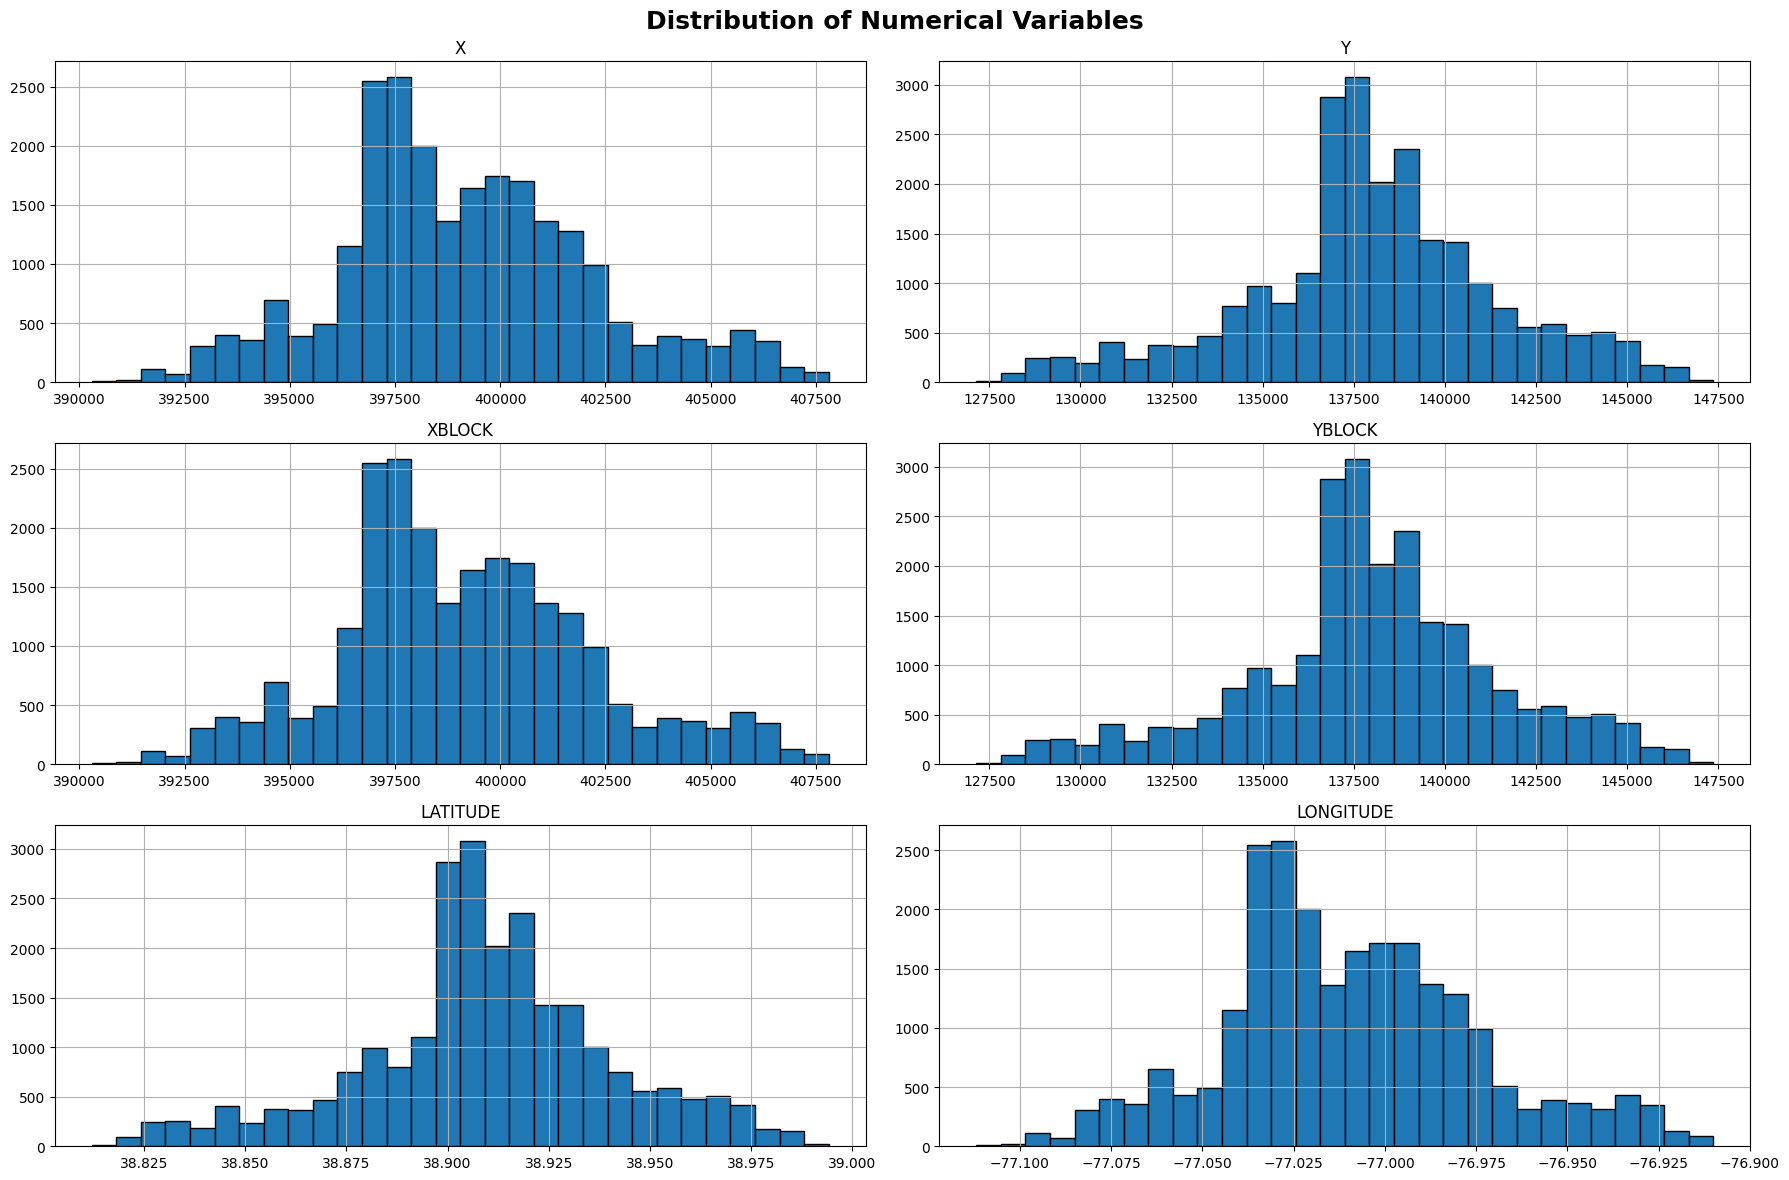

In [18]:
# ============================================================
# Step 16: Univariate Analysis - Numerical Variable Distribution
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

print(f"Total Numerical Variables: {len(numerical_cols)}")
print(numerical_cols.tolist())

# Plot histograms
df_clean[numerical_cols].hist(
    figsize=(18, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Step 16: Univariate Analysis – Numerical Variable Distribution

This step examines the distribution of all numerical variables in the cleaned dataset using histograms. Since data types were correctly enforced during preprocessing, only genuine numerical variables are included in this analysis, while identifiers and categorical codes have been excluded.

The dataset contains six numerical variables:

- X
- Y
- XBLOCK
- YBLOCK
- LATITUDE
- LONGITUDE

Visualizing these variables allows us to understand their distributions, identify skewness, detect unusual values or potential outliers, and assess whether the coordinate information appears reasonable before proceeding with further exploratory analysis and feature engineering.

### Observations

- The numerical variables are limited to spatial coordinate information, confirming that categorical identifiers such as **CCN**, **WARD**, **DISTRICT**, **PSA**, **OBJECTID**, and **CENSUS_TRACT** were successfully converted to string data types.
- The variables **X** and **XBLOCK** exhibit nearly identical distributions, indicating that they represent related east-west coordinate measurements.
- Similarly, **Y** and **YBLOCK** display almost identical distributions, suggesting they capture related north-south coordinate information.
- **LATITUDE** and **LONGITUDE** show approximately bell-shaped distributions with most incidents concentrated within a relatively narrow geographic region, which is expected for crime incidents occurring within Washington, D.C.
- No impossible coordinate values are immediately visible, although a more detailed outlier assessment will be performed in later stages.

### Importance

Examining numerical variable distributions provides an initial understanding of the dataset's quantitative features and confirms that the data type enforcement process was successful. This validation ensures that only true numerical variables are included in statistical analyses and visualizations, reducing the risk of treating categorical identifiers as continuous variables and improving the reliability of all subsequent exploratory analysis and machine learning workflows.

Total Numerical Variables: 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']


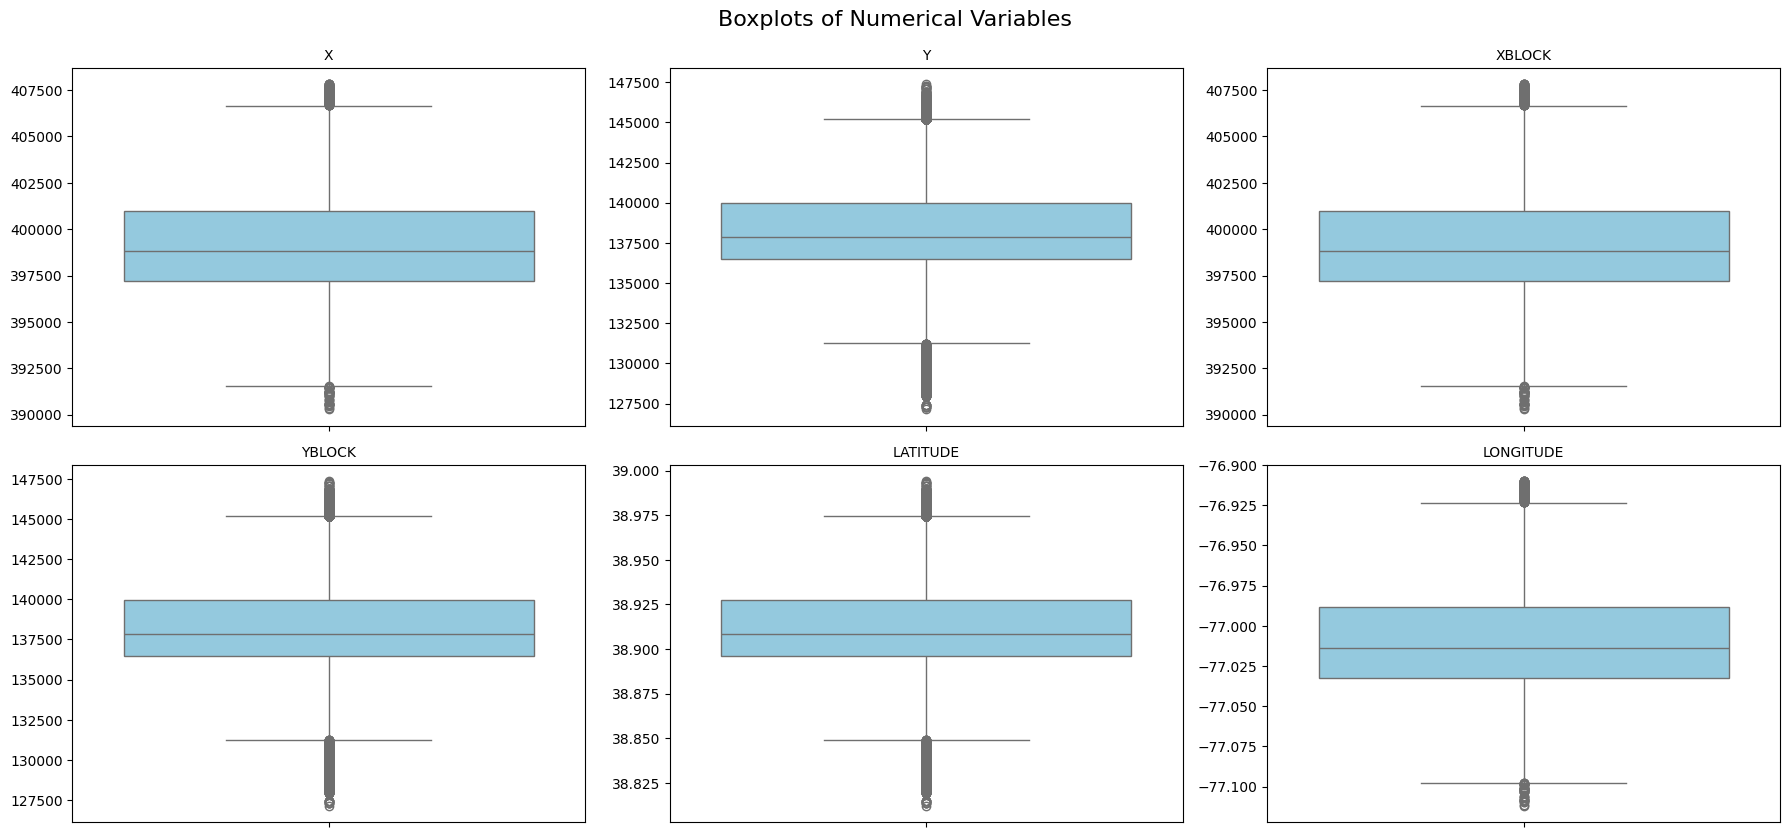

In [19]:
# ============================================================
# Step 17: Univariate Analysis – Numerical Variable Boxplots
# ============================================================

# Select numerical columns
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

print(f"Total Numerical Variables: {len(numerical_columns)}")
print(list(numerical_columns))

# Create boxplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[col], color="skyblue")
    plt.title(col, fontsize=10)
    plt.ylabel("")
    plt.tight_layout()

plt.suptitle("Boxplots of Numerical Variables", fontsize=16, y=1.02)
plt.show()

## Step 17: Univariate Analysis – Numerical Variable Boxplots

This step examines the distribution and spread of the numerical variables using boxplots. Boxplots provide a clear summary of the median, interquartile range, overall variability, and potential outlying observations within each variable.

The analysis includes the following six numerical variables:

- X
- Y
- XBLOCK
- YBLOCK
- LATITUDE
- LONGITUDE

### Output Summary

A separate boxplot was generated for each numerical variable. Each plot displays:

- The median value represented by the line inside the box
- The interquartile range represented by the box
- The lower and upper whiskers
- Individual observations located beyond the whiskers

### Observations

- All six numerical variables contain observations located beyond the boxplot whiskers.
- The variables **X** and **XBLOCK** show nearly identical boxplot patterns, confirming that they contain closely related east-west coordinate information.
- The variables **Y** and **YBLOCK** also display nearly identical patterns, reflecting related north-south coordinate information.
- **LATITUDE** and **LONGITUDE** contain several values beyond their lower and upper whiskers.
- The central ranges of all variables remain relatively compact, while smaller groups of observations appear at the geographical extremes.
- Because these variables represent spatial coordinates, observations outside the whiskers do not automatically indicate incorrect data. They may represent valid incidents occurring near the outer boundaries of Washington, D.C.
- The apparent outliers should therefore be investigated before any removal or transformation is considered.

### Importance

Boxplots help identify unusual observations, assess variable spread, and compare the central distribution of numerical features. However, boxplot outliers are determined statistically using the interquartile range and are not necessarily data errors.

For geographical coordinate variables, extreme values may represent legitimate locations rather than invalid observations. Retaining this distinction prevents valid crime-location records from being removed solely because they fall outside the boxplot whiskers.

Total Categorical Variables: 14
['CCN', 'BLOCK', 'OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 'VOTING_PRECINCT', 'OBJECTID']


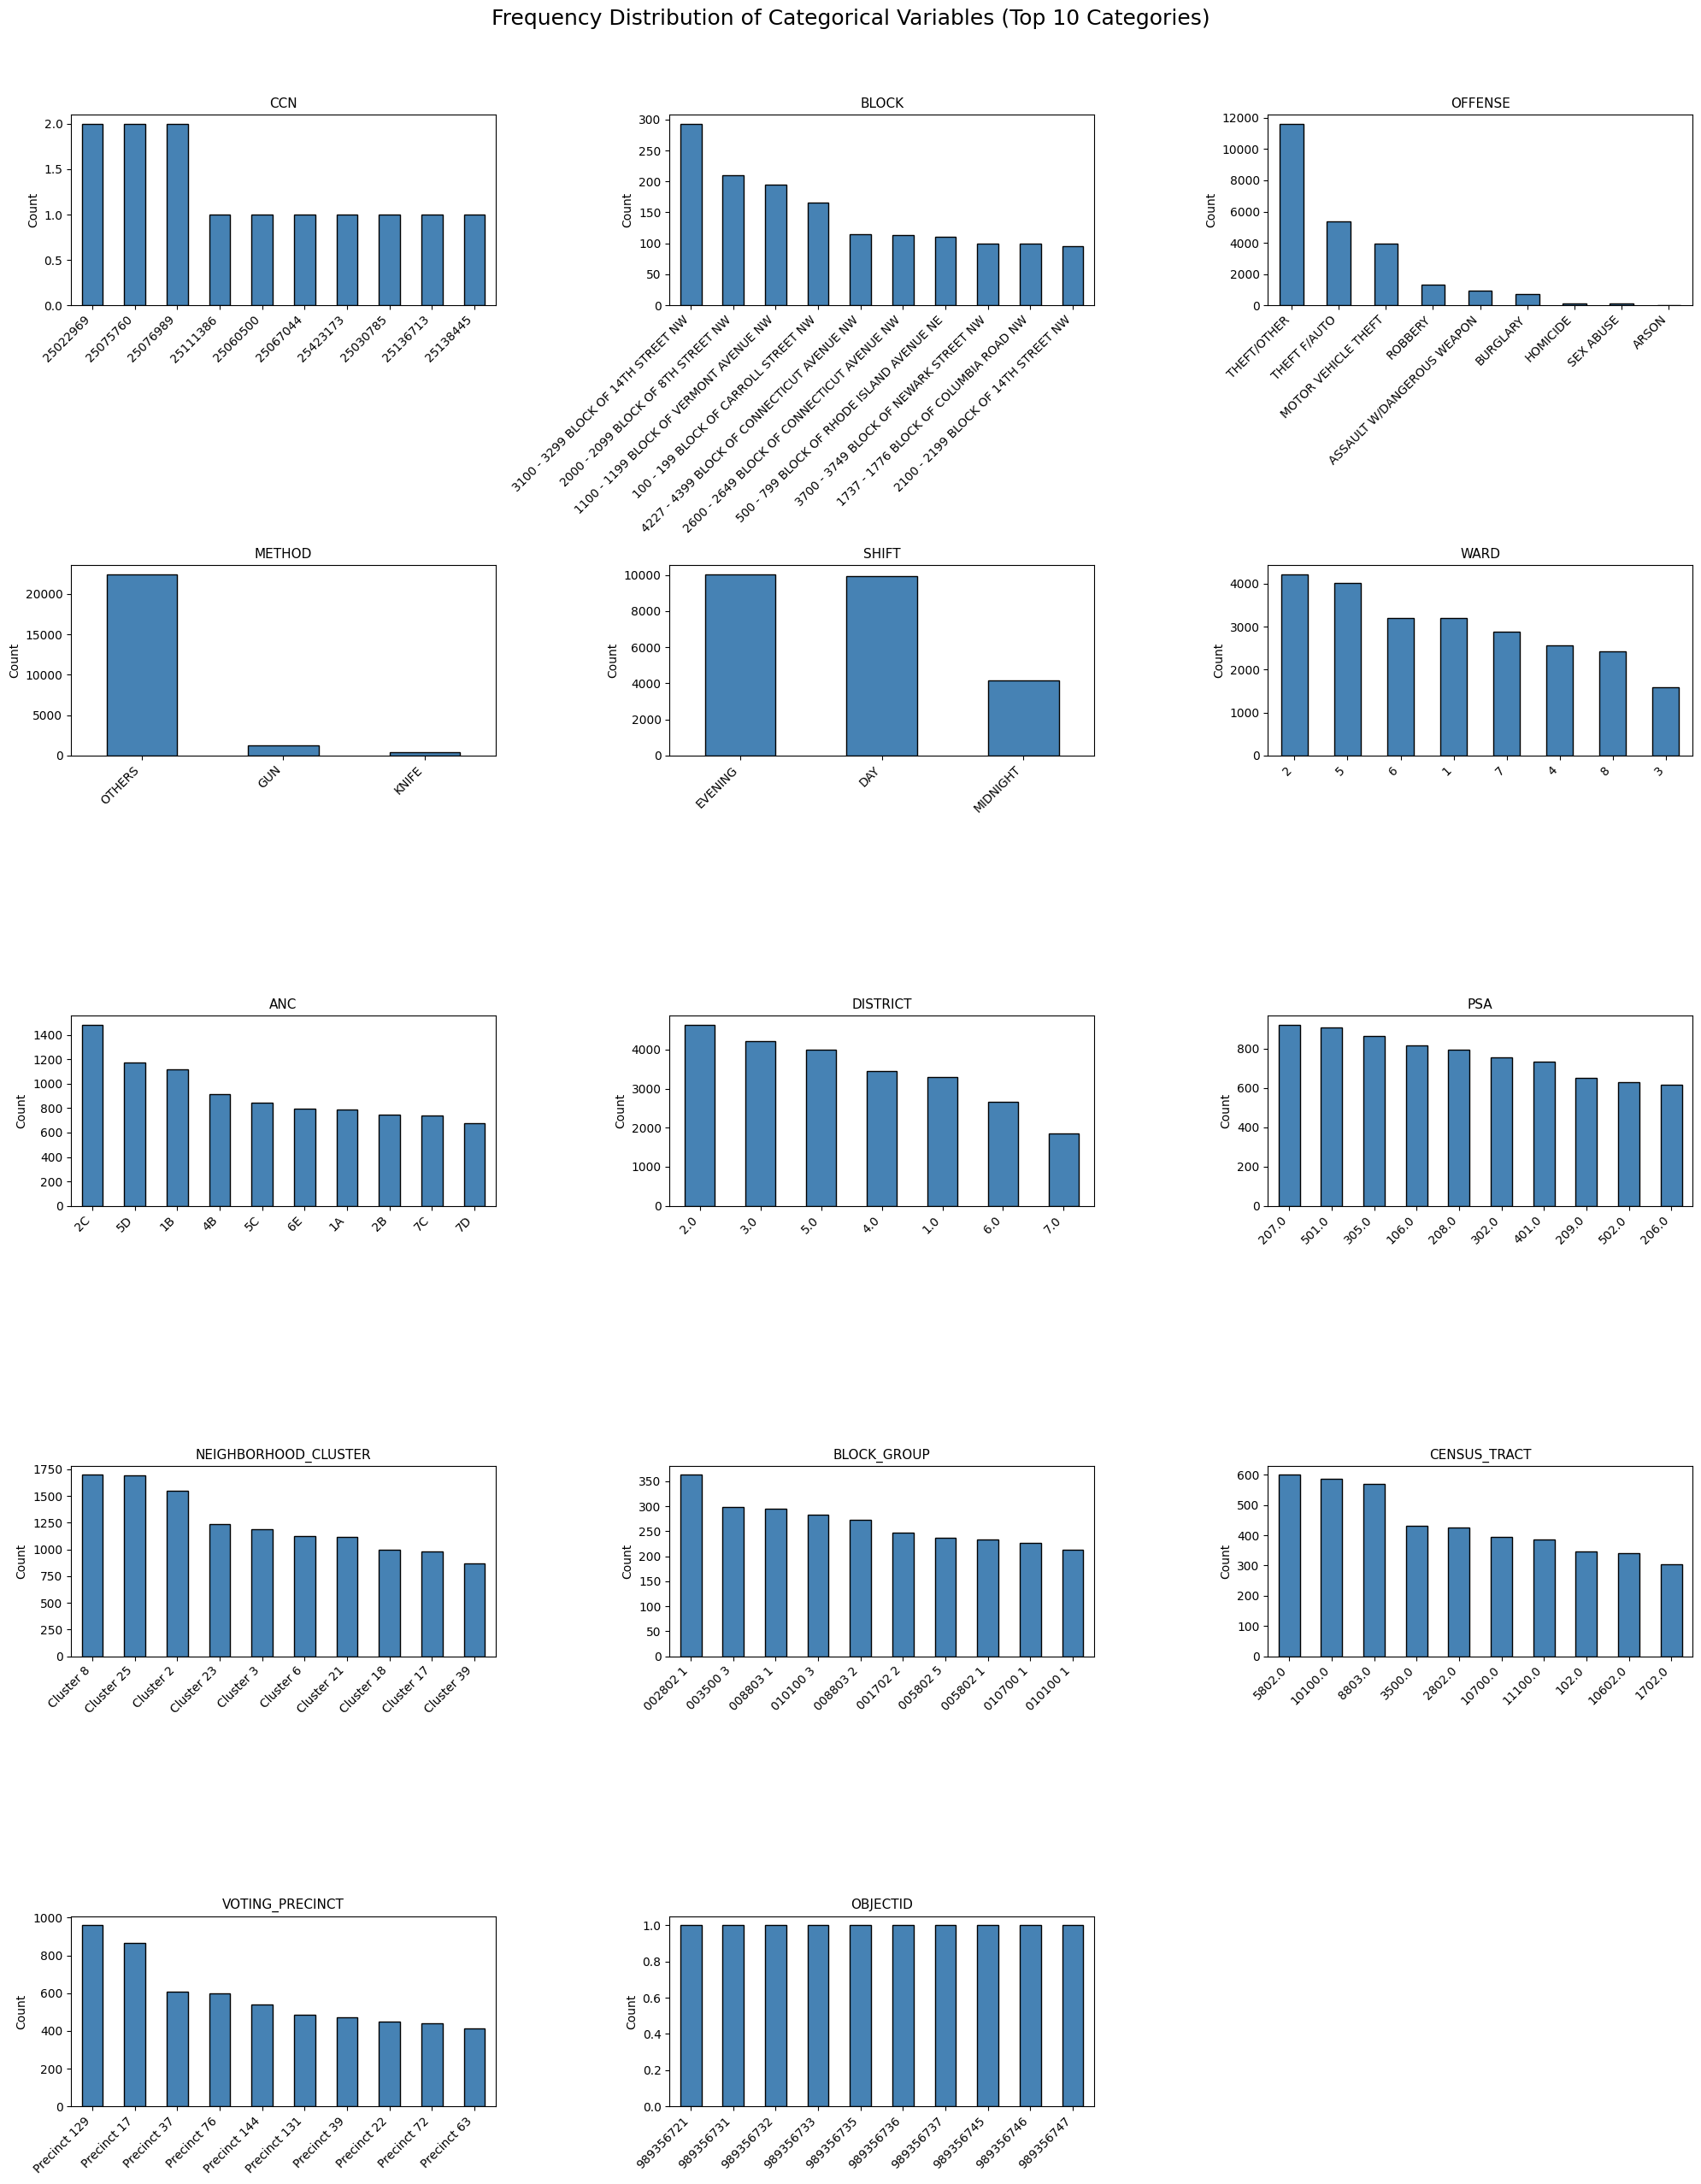

In [20]:
# ============================================================
# Step 18: Univariate Analysis – Categorical Variable Frequency Distribution
# ============================================================

# Select all categorical/text columns
categorical_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

print(f"Total Categorical Variables: {len(categorical_columns)}")
print(categorical_columns.tolist())

# Number of categorical variables
n_cols = 3
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

# Create figure
plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)

    # Plot top 10 categories only for readability
    df_clean[col].value_counts().head(10).plot(
        kind="bar",
        color="steelblue",
        edgecolor="black"
    )

    plt.title(col, fontsize=11)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")

plt.suptitle(
    "Frequency Distribution of Categorical Variables (Top 10 Categories)",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# Step 18: Univariate Analysis – Categorical Variable Frequency Distribution

## Objective

The purpose of this step is to examine the frequency distribution of the categorical variables in the dataset. This helps identify dominant categories, class imbalance, high-cardinality variables, rare categories, and possible identifiers that may not provide meaningful analytical information.

## Method

All columns stored as either `object` or pandas `string` data types were selected as categorical variables.

For variables containing many unique categories, only the ten most frequent values were displayed to maintain readability.

A total of **14 categorical variables** were identified:

- `CCN`
- `BLOCK`
- `OFFENSE`
- `METHOD`
- `SHIFT`
- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`
- `BLOCK_GROUP`
- `CENSUS_TRACT`
- `VOTING_PRECINCT`
- `OBJECTID`

## Output Summary

The frequency plots reveal the following patterns:

- **OFFENSE** is strongly dominated by `THEFT/OTHER`, followed by `THEFT F/AUTO` and `MOTOR VEHICLE THEFT`.
- **METHOD** is heavily dominated by `OTHERS`, while `GUN` and `KNIFE` occur much less frequently.
- **SHIFT** is distributed across `DAY`, `EVENING`, and `MIDNIGHT`. Day and evening incidents occur more frequently than midnight incidents.
- **WARD** contains eight categories, with some wards recording noticeably more incidents than others.
- **DISTRICT** contains seven categories and also shows an uneven distribution of incidents.
- **ANC**, **PSA**, **NEIGHBORHOOD_CLUSTER**, **BLOCK_GROUP**, **CENSUS_TRACT**, and **VOTING_PRECINCT** contain several location-based categories with varying incident frequencies.
- **BLOCK** has a large number of unique street-block descriptions, indicating high cardinality.
- **CCN** and **OBJECTID** are nearly unique for every record, confirming that they function primarily as record identifiers rather than descriptive categorical features.

## Observation

The categorical variables show considerable differences in both category frequency and cardinality.

Crime-related variables such as `OFFENSE`, `METHOD`, and `SHIFT` contain a relatively small number of interpretable categories and provide useful information about the nature and timing of reported incidents.

Geographical variables such as `WARD`, `DISTRICT`, `ANC`, `PSA`, `NEIGHBORHOOD_CLUSTER`, `BLOCK_GROUP`, `CENSUS_TRACT`, and `VOTING_PRECINCT` provide information about the spatial distribution of incidents. Their frequency differences suggest that crime incidents are not evenly distributed across all administrative and geographical areas.

The `BLOCK` variable contains thousands of unique locations. Although the most frequent blocks can be examined, the variable may require careful treatment because its high cardinality could create a very large number of encoded features.

The frequency plots for `CCN` and `OBJECTID` show counts of approximately one for most values. This is expected because these columns uniquely identify individual records. Their distributions do not describe meaningful patterns in crime activity.

## Important Analytical Consideration

Although `CCN` and `OBJECTID` are stored as strings and correctly classified as categorical data types, they should not automatically be treated as predictive categorical features.

Including unique identifiers in a machine-learning model may cause the model to memorise individual records rather than learn general patterns. This may lead to overfitting, misleading feature importance, and poor performance on unseen data.

High-cardinality location variables such as `BLOCK` should also be assessed carefully before encoding because they may substantially increase the number of model features.

## Importance

Categorical frequency analysis is important because it:

- Identifies the most common crime types, methods, shifts, and locations.
- Reveals imbalanced categories that may influence statistical analysis or model training.
- Detects high-cardinality variables that may require grouping, transformation, or exclusion.
- Distinguishes meaningful categorical features from record identifiers.
- Supports informed decisions during feature engineering and machine-learning preparation.
- Reduces the risk of using identifiers or overly specific variables that could contribute to overfitting or data leakage.

Total Categorical Variables: 14
['CCN', 'BLOCK', 'OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 'VOTING_PRECINCT', 'OBJECTID']


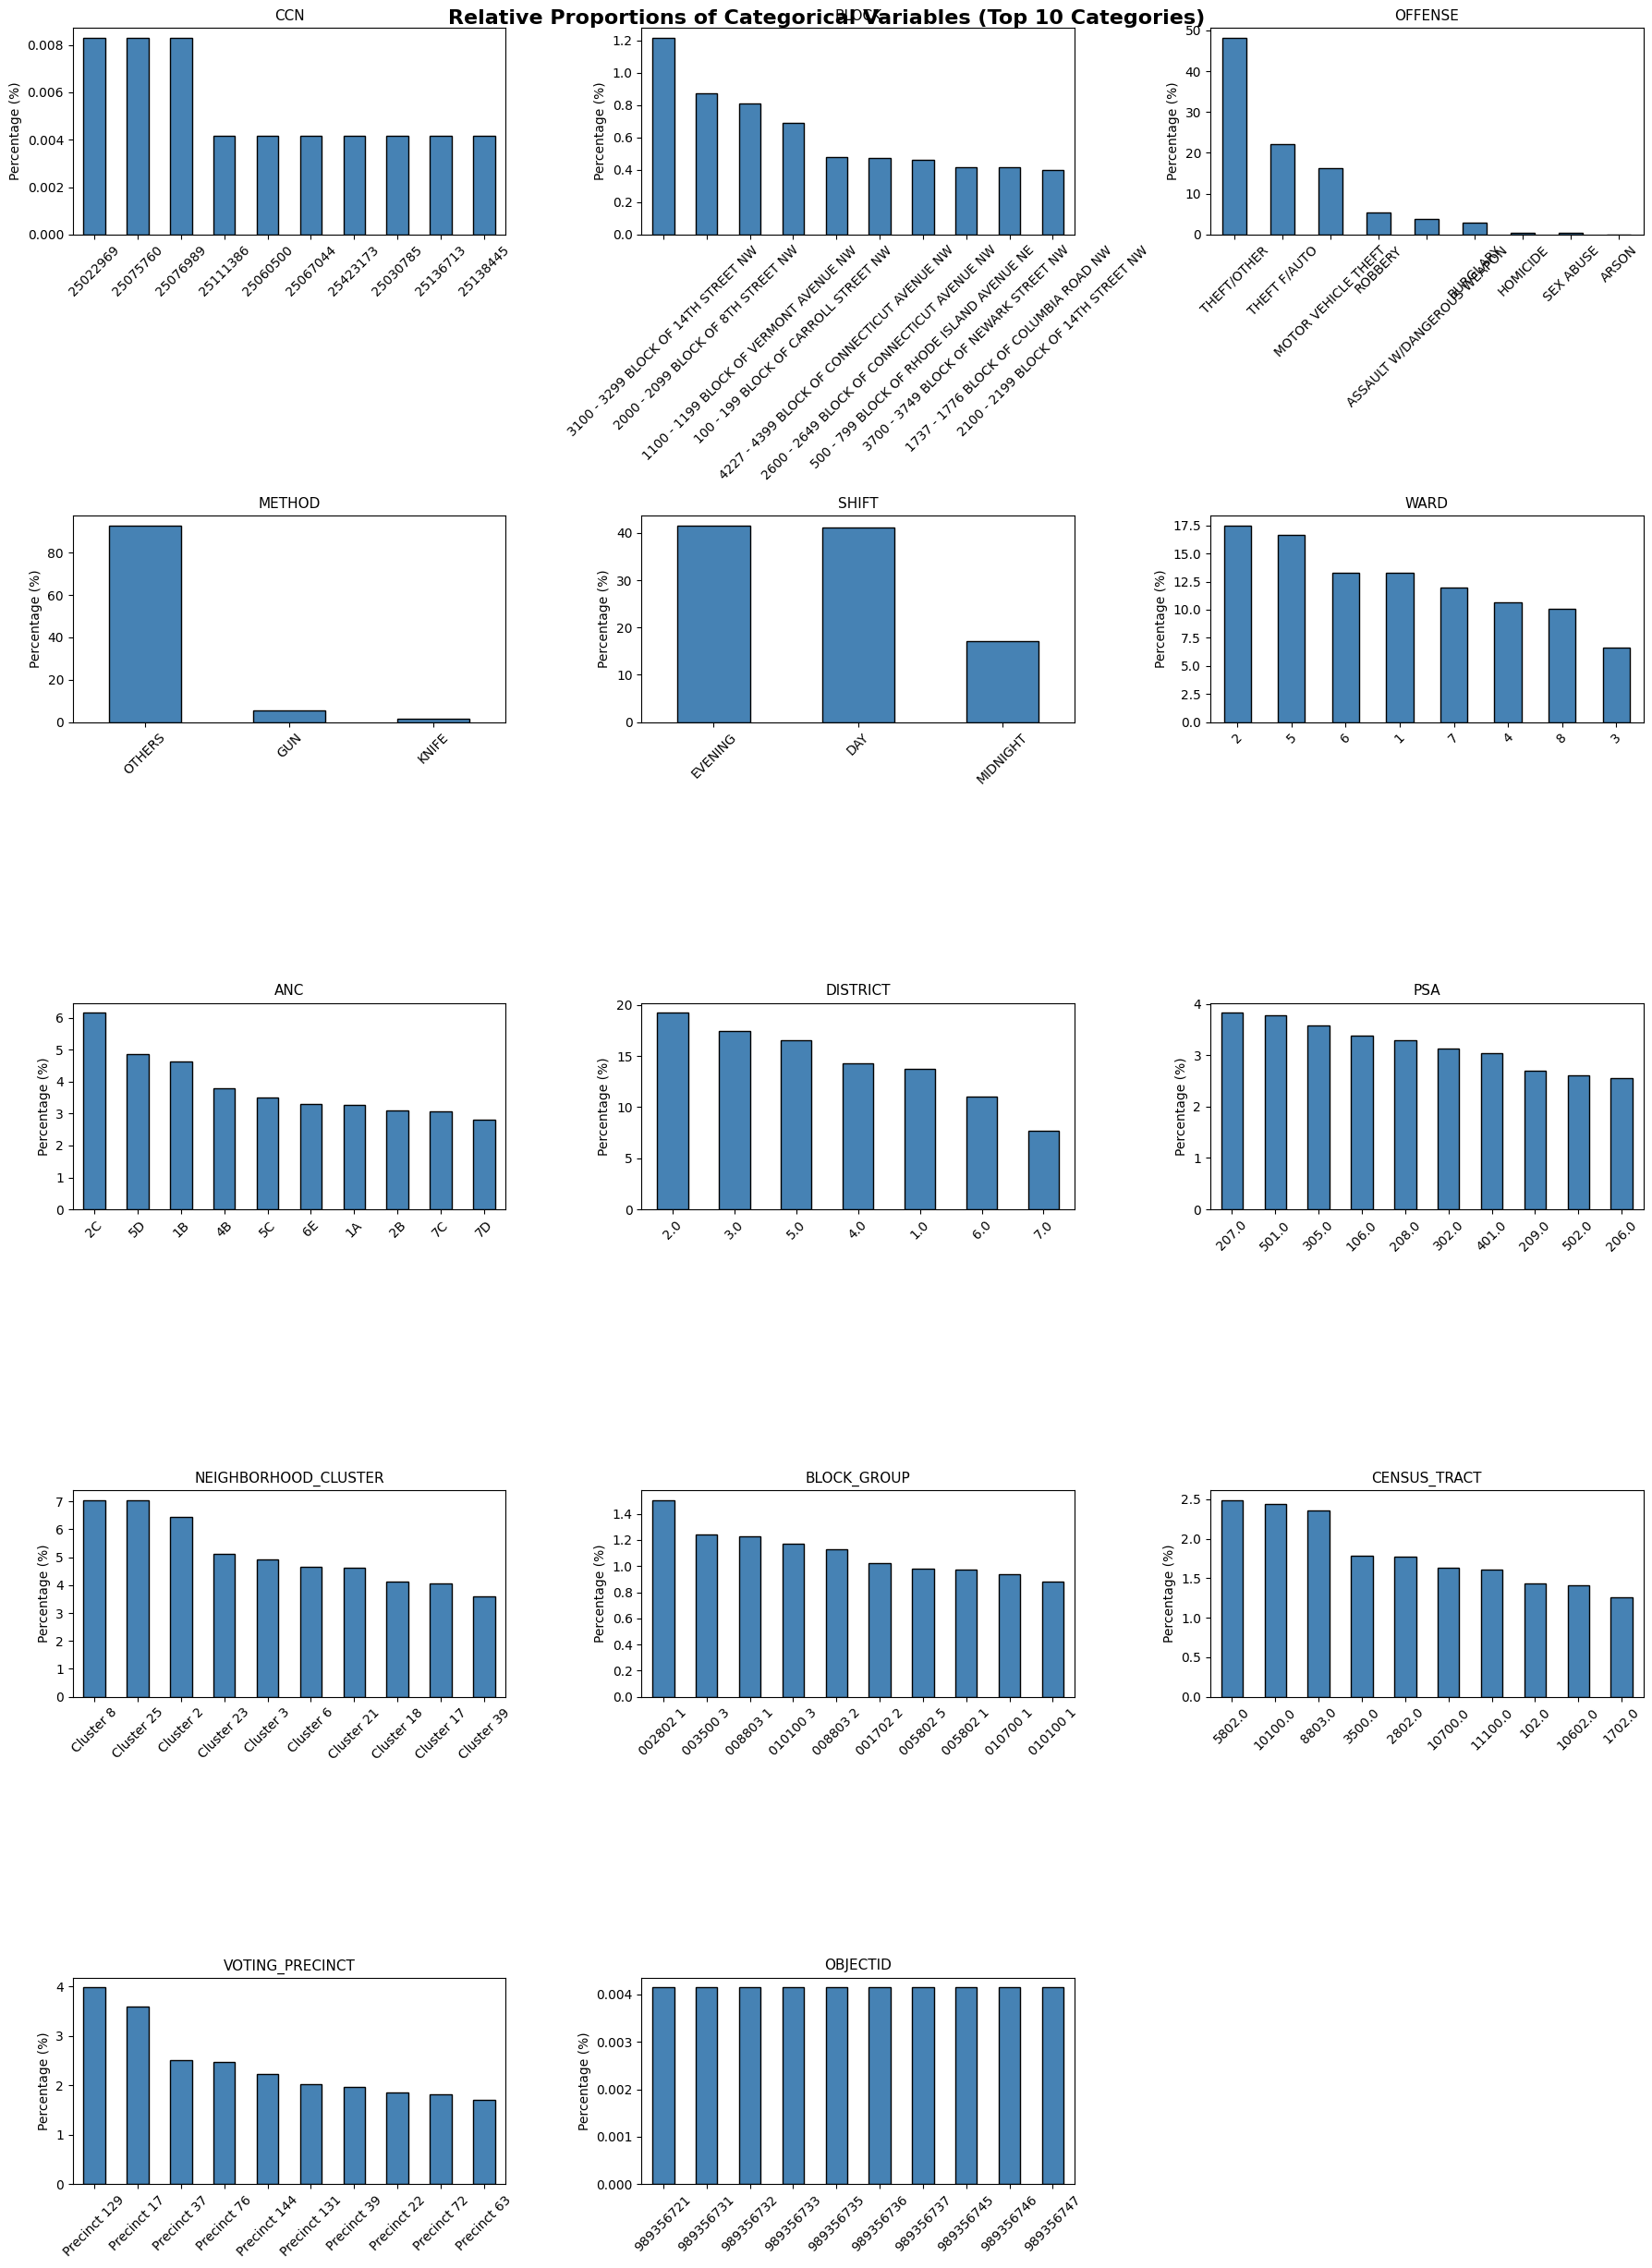

In [21]:
# ============================================================
# Step 19: Univariate Analysis - Relative Proportions of
# Categorical Variables (Top 10 Categories)
# ============================================================

import math
import matplotlib.pyplot as plt

# Select all categorical/text columns
categorical_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

print(f"Total Categorical Variables: {len(categorical_columns)}")
print(categorical_columns.tolist())

# Create subplot layout
n_cols = 3
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot percentage distributions
for i, col in enumerate(categorical_columns):

    percent = (
        df_clean[col]
        .value_counts(normalize=True)
        .head(10)
        .sort_values(ascending=False)
        * 100
    )

    percent.plot(
        kind="bar",
        ax=axes[i],
        color="steelblue",
        edgecolor="black"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Relative Proportions of Categorical Variables (Top 10 Categories)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 19: Univariate Analysis – Relative Proportions of Categorical Variables

## Objective

The objective of this step was to examine the relative percentage distribution of the categorical variables in the dataset. Percentage-based distributions make it easier to compare categories across variables with different numbers of observations and identify dominant, balanced, or rare groups.

For variables containing many unique categories, only the ten most frequent categories were displayed to maintain readability.

---

## Method

The categorical variables were selected using both the `object` and `string` data types to ensure that all text-based and categorical-code columns were included.

For each variable:

- The frequency of each category was calculated.
- Frequencies were converted into percentages of the complete dataset.
- The ten most common categories were selected.
- The resulting proportions were visualized using bar charts.

A total of **14 categorical variables** were identified:

- `CCN`
- `BLOCK`
- `OFFENSE`
- `METHOD`
- `SHIFT`
- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`
- `BLOCK_GROUP`
- `CENSUS_TRACT`
- `VOTING_PRECINCT`
- `OBJECTID`

---

## Output Summary

The percentage distributions show substantial differences in concentration across the categorical variables.

### Crime-related variables

- `OFFENSE` is highly concentrated, with **THEFT/OTHER** representing the largest proportion of recorded incidents.
- `THEFT F/AUTO` and `MOTOR VEHICLE THEFT` are also prominent offence categories.
- `METHOD` is strongly dominated by **OTHERS**, while `GUN` and `KNIFE` represent considerably smaller proportions.
- The `SHIFT` distribution is more balanced, although **EVENING** and **DAY** account for larger proportions than **MIDNIGHT**.

### Geographic variables

- `WARD` contains eight categories, with some wards representing a larger proportion of incidents than others.
- `DISTRICT` also shows variation across its seven categories, indicating that incidents are not distributed evenly between police districts.
- `ANC`, `PSA`, `NEIGHBORHOOD_CLUSTER`, `BLOCK_GROUP`, `CENSUS_TRACT`, and `VOTING_PRECINCT` contain many geographic categories.
- Their leading categories represent relatively small percentages of the dataset, indicating that incidents are distributed across numerous geographic areas rather than being concentrated in only one location.
- `BLOCK` has very high cardinality, and even its most frequent street block represents only a small percentage of the total records.

### Identifier variables

- `CCN` and `OBJECTID` are record identifiers rather than meaningful analytical categories.
- Their individual percentage values are extremely small because almost every value is unique.
- The nearly equal bars in `OBJECTID` confirm that each identifier generally appears once.
- These identifier variables should not be interpreted as evidence of patterns in crime incidents.

---

## Observation

The dataset contains both low-cardinality categorical variables, such as `OFFENSE`, `METHOD`, `SHIFT`, `WARD`, and `DISTRICT`, and high-cardinality variables, such as `BLOCK`, `CCN`, `OBJECTID`, `BLOCK_GROUP`, and `CENSUS_TRACT`.

The crime-related variables reveal clear concentration patterns. Theft-related offences account for a substantial share of incidents, while the general `OTHERS` method category dominates the method distribution. Incident activity is spread across shifts, although daytime and evening periods contain larger shares.

The geographic variables show that incidents occur across many wards, districts, neighbourhood clusters, police service areas, census tracts, and voting precincts. No single detailed geographic category appears to account for an overwhelmingly large proportion of all incidents.

High-cardinality identifiers and detailed location codes produce very small category percentages. Although they are technically stored as categorical variables, their distributions have limited interpretive value and should be treated carefully in later analysis and modelling.

---

## Importance

Relative proportions provide a clearer understanding of categorical imbalance than raw frequency counts alone. This analysis helps identify:

- Dominant offence and method categories.
- Potential class imbalance within categorical features.
- Geographic areas with comparatively higher incident representation.
- High-cardinality variables that may require grouping, transformation, exclusion, or specialised encoding.
- Identifier columns that should not be treated as predictive or explanatory features.

Understanding these distributions supports reliable visualization, feature engineering, model preparation, and the prevention of overfitting or data leakage caused by unique identifiers.

Total Scatter Plots: 5
Variable Pairs:
- Y versus X
- YBLOCK versus XBLOCK
- LATITUDE versus LONGITUDE
- LONGITUDE versus X
- LATITUDE versus Y


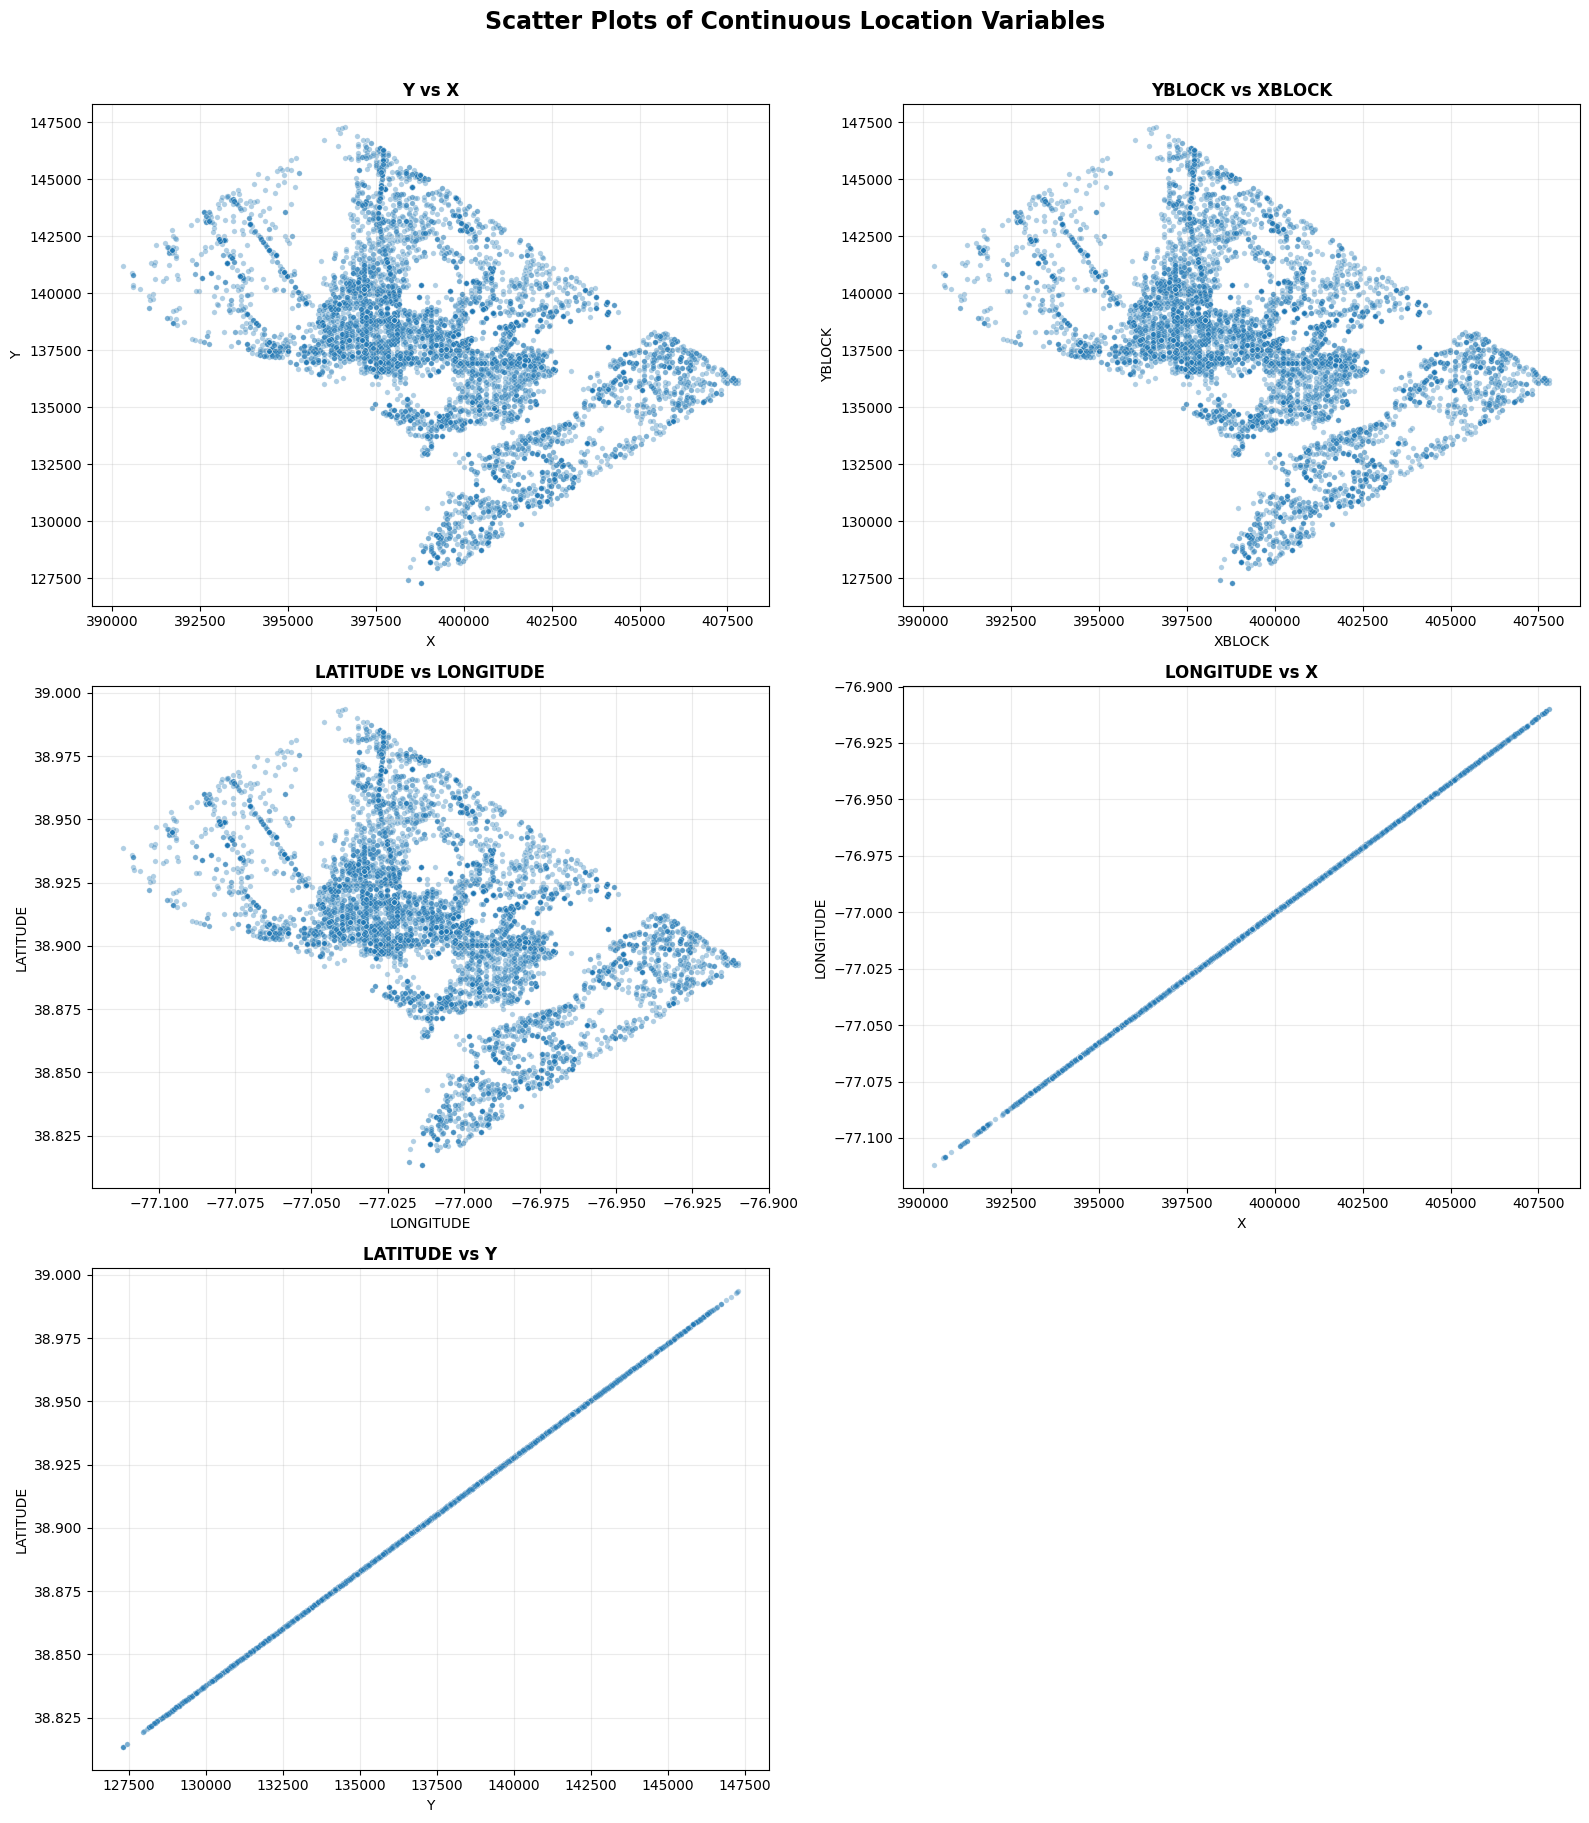

In [22]:
# ============================================================
# Step 20: Bivariate Analysis - Scatter Plots
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create a 40% sample to make plotting faster and reduce memory usage
plot_sample = df_clean.sample(
    frac=0.40,
    random_state=42
).copy()

# Select meaningful pairs of continuous numerical variables
scatter_pairs = [
    ("X", "Y"),
    ("XBLOCK", "YBLOCK"),
    ("LONGITUDE", "LATITUDE"),
    ("X", "LONGITUDE"),
    ("Y", "LATITUDE")
]

print(f"Total Scatter Plots: {len(scatter_pairs)}")
print("Variable Pairs:")
for x_col, y_col in scatter_pairs:
    print(f"- {y_col} versus {x_col}")

# Create subplot layout
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Generate scatter plots
for ax, (x_col, y_col) in zip(axes, scatter_pairs):

    # Remove missing values only for the current variable pair
    pair_data = plot_sample[[x_col, y_col]].dropna()

    sns.scatterplot(
        data=pair_data,
        x=x_col,
        y=y_col,
        alpha=0.35,
        s=15,
        ax=ax
    )

    ax.set_title(
        f"{y_col} vs {x_col}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(alpha=0.25)

# Remove any unused subplot
for unused_ax in axes[len(scatter_pairs):]:
    fig.delaxes(unused_ax)

plt.suptitle(
    "Scatter Plots of Continuous Location Variables",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

# Step 20: Bivariate Analysis – Scatter Plots of Continuous Location Variables

## Objective

The objective of this step is to examine the relationships between the continuous geographical variables in the dataset. Scatter plots are used to identify spatial patterns, linear relationships, duplicate measurements, and possible multicollinearity among the coordinate features.

## Variables Analysed

The following continuous numerical relationships were examined:

- `X` versus `Y`
- `XBLOCK` versus `YBLOCK`
- `LONGITUDE` versus `LATITUDE`
- `X` versus `LONGITUDE`
- `Y` versus `LATITUDE`

A 40% random sample of the dataset was used to reduce plotting time and memory usage while preserving the overall spatial structure of the observations.

## Output Summary

The scatter plots show clear geographical patterns across the coordinate variables.

- The `Y` versus `X` plot forms a recognisable spatial map of the crime incident locations.
- The `YBLOCK` versus `XBLOCK` plot produces almost the same spatial pattern as the `Y` versus `X` plot.
- The `LATITUDE` versus `LONGITUDE` plot also reproduces the same geographical distribution using standard geographic coordinates.
- `LONGITUDE` and `X` display an almost perfectly positive linear relationship.
- `LATITUDE` and `Y` also display an almost perfectly positive linear relationship.

## Observation

The plots confirm that the dataset contains several coordinate systems describing the same underlying geographical locations.

The very strong linear relationship between `X` and `LONGITUDE`, and between `Y` and `LATITUDE`, indicates that these variables are alternative representations of east–west and north–south positions.

Similarly, the nearly identical spatial patterns produced by `X` and `Y` compared with `XBLOCK` and `YBLOCK` suggest substantial duplication or very strong correlation between these coordinate pairs.

The dense clusters visible in the geographical scatter plots indicate that crime incidents are concentrated more heavily in certain locations rather than being evenly distributed across the study area.

## Importance

This analysis is important because highly correlated geographical variables can introduce redundancy and multicollinearity into later statistical analysis or machine-learning models.

Keeping several coordinate systems that represent the same location may:

- Provide little additional predictive information.
- Increase model complexity.
- Distort feature-importance results.
- Increase the risk of overfitting.
- Cause instability in models that are sensitive to multicollinearity.

The scatter plots therefore provide strong evidence that the coordinate variables should be assessed carefully before feature selection and modelling.

In [23]:
# ==========================================================
# Step 21: Correlation Matrix of Numerical Variables
# ==========================================================

# Select all numerical columns
numerical_cols = df_clean.select_dtypes(include=["number"]).columns

print(f"Total Numerical Variables: {len(numerical_cols)}")
print(list(numerical_cols))

# Compute correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()

# Display correlation matrix
print("\nCorrelation Matrix:")
display(correlation_matrix.round(3))

Total Numerical Variables: 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']

Correlation Matrix:


,X,Y,XBLOCK,YBLOCK,LATITUDE,LONGITUDE
X,1.000,-0.425,1.000,-0.425,-0.425,1.000
Y,-0.425,1.000,-0.425,1.000,1.000,-0.425
XBLOCK,1.000,-0.425,1.000,-0.425,-0.425,1.000
YBLOCK,-0.425,1.000,-0.425,1.000,1.000,-0.425
LATITUDE,-0.425,1.000,-0.425,1.000,1.000,-0.425
LONGITUDE,1.000,-0.425,1.000,-0.425,-0.425,1.000


# Step 21: Correlation Matrix of Numerical Variables

## Objective

The objective of this step was to examine the strength and direction of the linear relationships among the six continuous numerical location variables in the dataset. Pearson correlation coefficients were calculated to identify duplicated coordinate information, highly correlated features, and possible multicollinearity.

## Output Summary

The correlation matrix was calculated for the following numerical variables:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

Correlation coefficients range from **-1 to +1**:

- A value close to **+1** indicates a strong positive linear relationship.
- A value close to **-1** indicates a strong negative linear relationship.
- A value close to **0** indicates little or no linear relationship.

## Observation

The correlation matrix reveals several important relationships:

- `X` and `XBLOCK` have a perfect positive correlation of **1.000**, indicating that they contain identical coordinate information.
- `Y` and `YBLOCK` also have a perfect positive correlation of **1.000**.
- `X` and `LONGITUDE` have a perfect positive correlation of **1.000**.
- `XBLOCK` and `LONGITUDE` also have a perfect positive correlation of **1.000**.
- `Y` and `LATITUDE` have a perfect positive correlation of **1.000**.
- `YBLOCK` and `LATITUDE` also have a perfect positive correlation of **1.000**.
- The east–west coordinate variables and north–south coordinate variables have a moderate negative correlation of approximately **-0.425**.

The perfect correlations show that the dataset contains multiple representations of the same geographic location. `X` and `XBLOCK` represent the same east–west coordinate information, while `Y` and `YBLOCK` represent the same north–south coordinate information. Longitude and latitude are geographic transformations of these coordinate values.

## Key Insight

The six numerical variables do not represent six independent measurements. They form two strongly redundant groups:

- **East–west location:** `X`, `XBLOCK`, and `LONGITUDE`
- **North–south location:** `Y`, `YBLOCK`, and `LATITUDE`

Using all of these variables together in a machine-learning model would provide duplicated information rather than additional predictive value.

## Importance

Identifying highly correlated variables is important because redundant features can:

- Increase multicollinearity.
- Add unnecessary model complexity.
- Increase the risk of overfitting.
- Distort feature-importance results.
- Make model coefficients unstable.
- Increase processing time without providing meaningful additional information.

The correlation analysis therefore provides strong evidence that only one suitable coordinate pair should be retained during feature selection or modelling, rather than using all six location variables simultaneously.

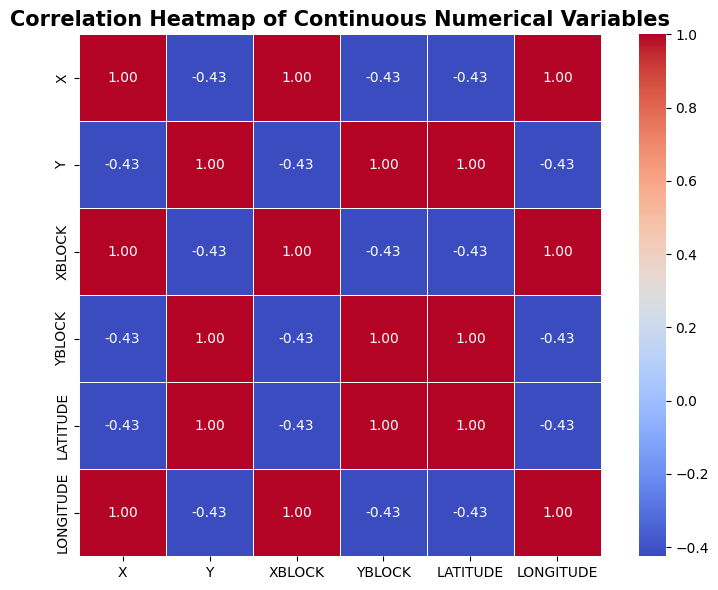

In [24]:
# ==========================================================
# Step 22: Correlation Heatmap of Continuous Numerical Variables
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
correlation_matrix = df_clean.select_dtypes(include=["number"]).corr()

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title(
    "Correlation Heatmap of Continuous Numerical Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 22: Correlation Heatmap of Continuous Numerical Variables

## Objective

The objective of this step was to visually examine the strength and direction of the relationships among the continuous numerical location variables. A correlation heatmap was created from the Pearson correlation matrix to make duplicated and highly related coordinate variables easier to identify.

## Output Summary

The heatmap includes the following six continuous numerical variables:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

The annotated values represent correlation coefficients ranging from **-1 to +1**:

- Values close to **+1** indicate a strong positive relationship.
- Values close to **-1** indicate a strong negative relationship.
- Values close to **0** indicate a weak linear relationship.

The colour scale also supports interpretation, with stronger positive and negative relationships represented by contrasting colours.

## Observation

The heatmap confirms several perfect correlations:

- `X` and `XBLOCK` have a correlation of **1.00**.
- `X` and `LONGITUDE` have a correlation of **1.00**.
- `XBLOCK` and `LONGITUDE` have a correlation of **1.00**.
- `Y` and `YBLOCK` have a correlation of **1.00**.
- `Y` and `LATITUDE` have a correlation of **1.00**.
- `YBLOCK` and `LATITUDE` have a correlation of **1.00**.

The heatmap also shows a moderate negative correlation of approximately **-0.43** between the east–west coordinate variables and the north–south coordinate variables.

The diagonal values are all **1.00** because every variable is perfectly correlated with itself.

## Key Insight

The heatmap provides clear visual evidence that the six coordinate variables contain substantial duplicated information.

They can be grouped into two sets:

- **East–west position:** `X`, `XBLOCK`, and `LONGITUDE`
- **North–south position:** `Y`, `YBLOCK`, and `LATITUDE`

The perfect correlations within each group indicate that retaining every coordinate variable would not provide six independent sources of information. Instead, multiple columns represent the same underlying geographic position using different coordinate systems or labels.

## Importance

Identifying these relationships is important because using perfectly correlated variables together may:

- Introduce severe multicollinearity.
- Increase model complexity unnecessarily.
- Produce unstable model coefficients.
- Distort feature-importance results.
- Increase the risk of overfitting.
- Add duplicated information without improving predictive performance.

The heatmap therefore supports retaining only one suitable geographic coordinate pair during modelling, such as `LATITUDE` and `LONGITUDE`, while carefully assessing whether the remaining duplicated coordinate columns should be removed.

Continuous Numerical Variables: 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']

Categorical Variables: 8
['OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER']


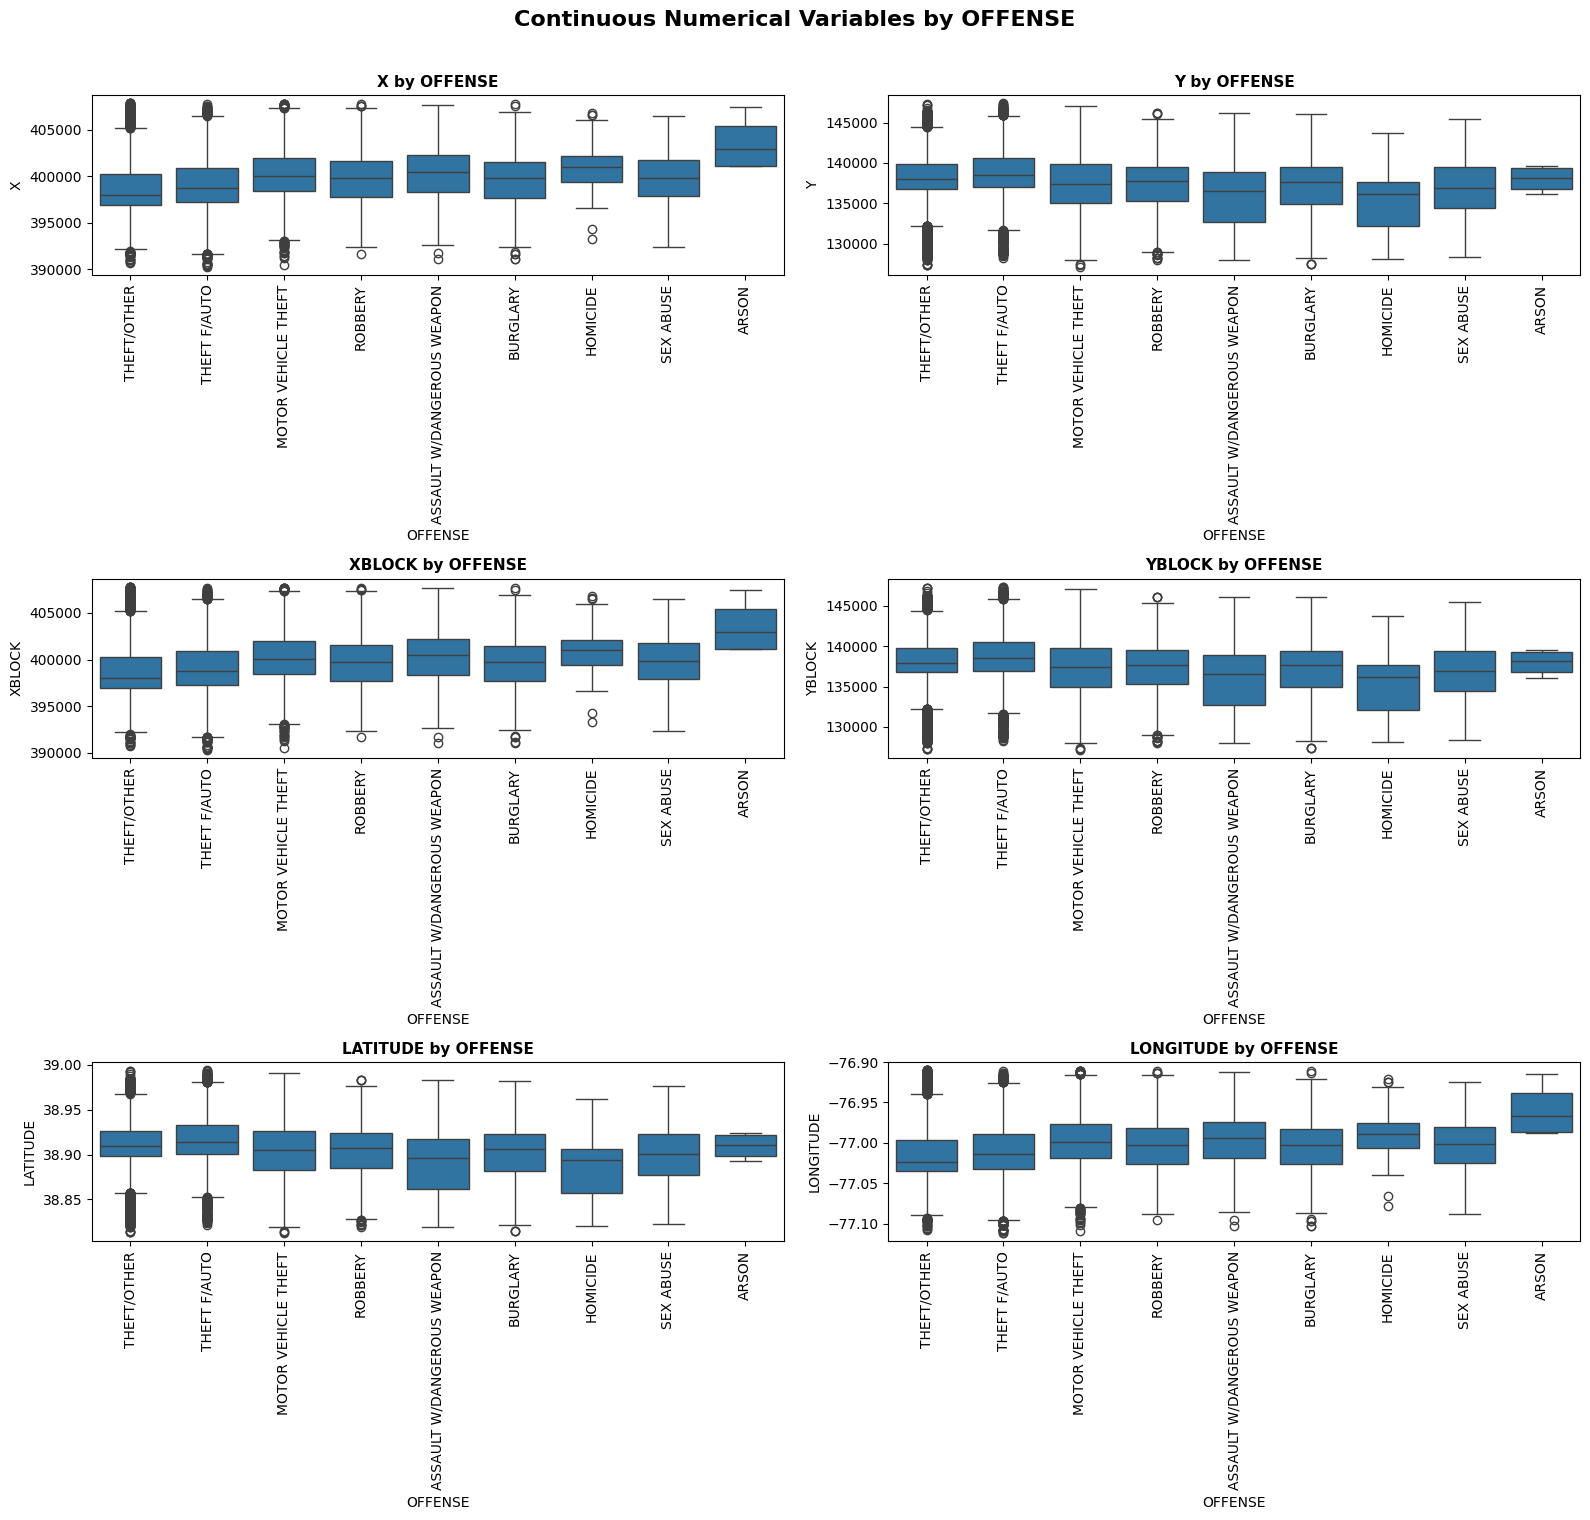

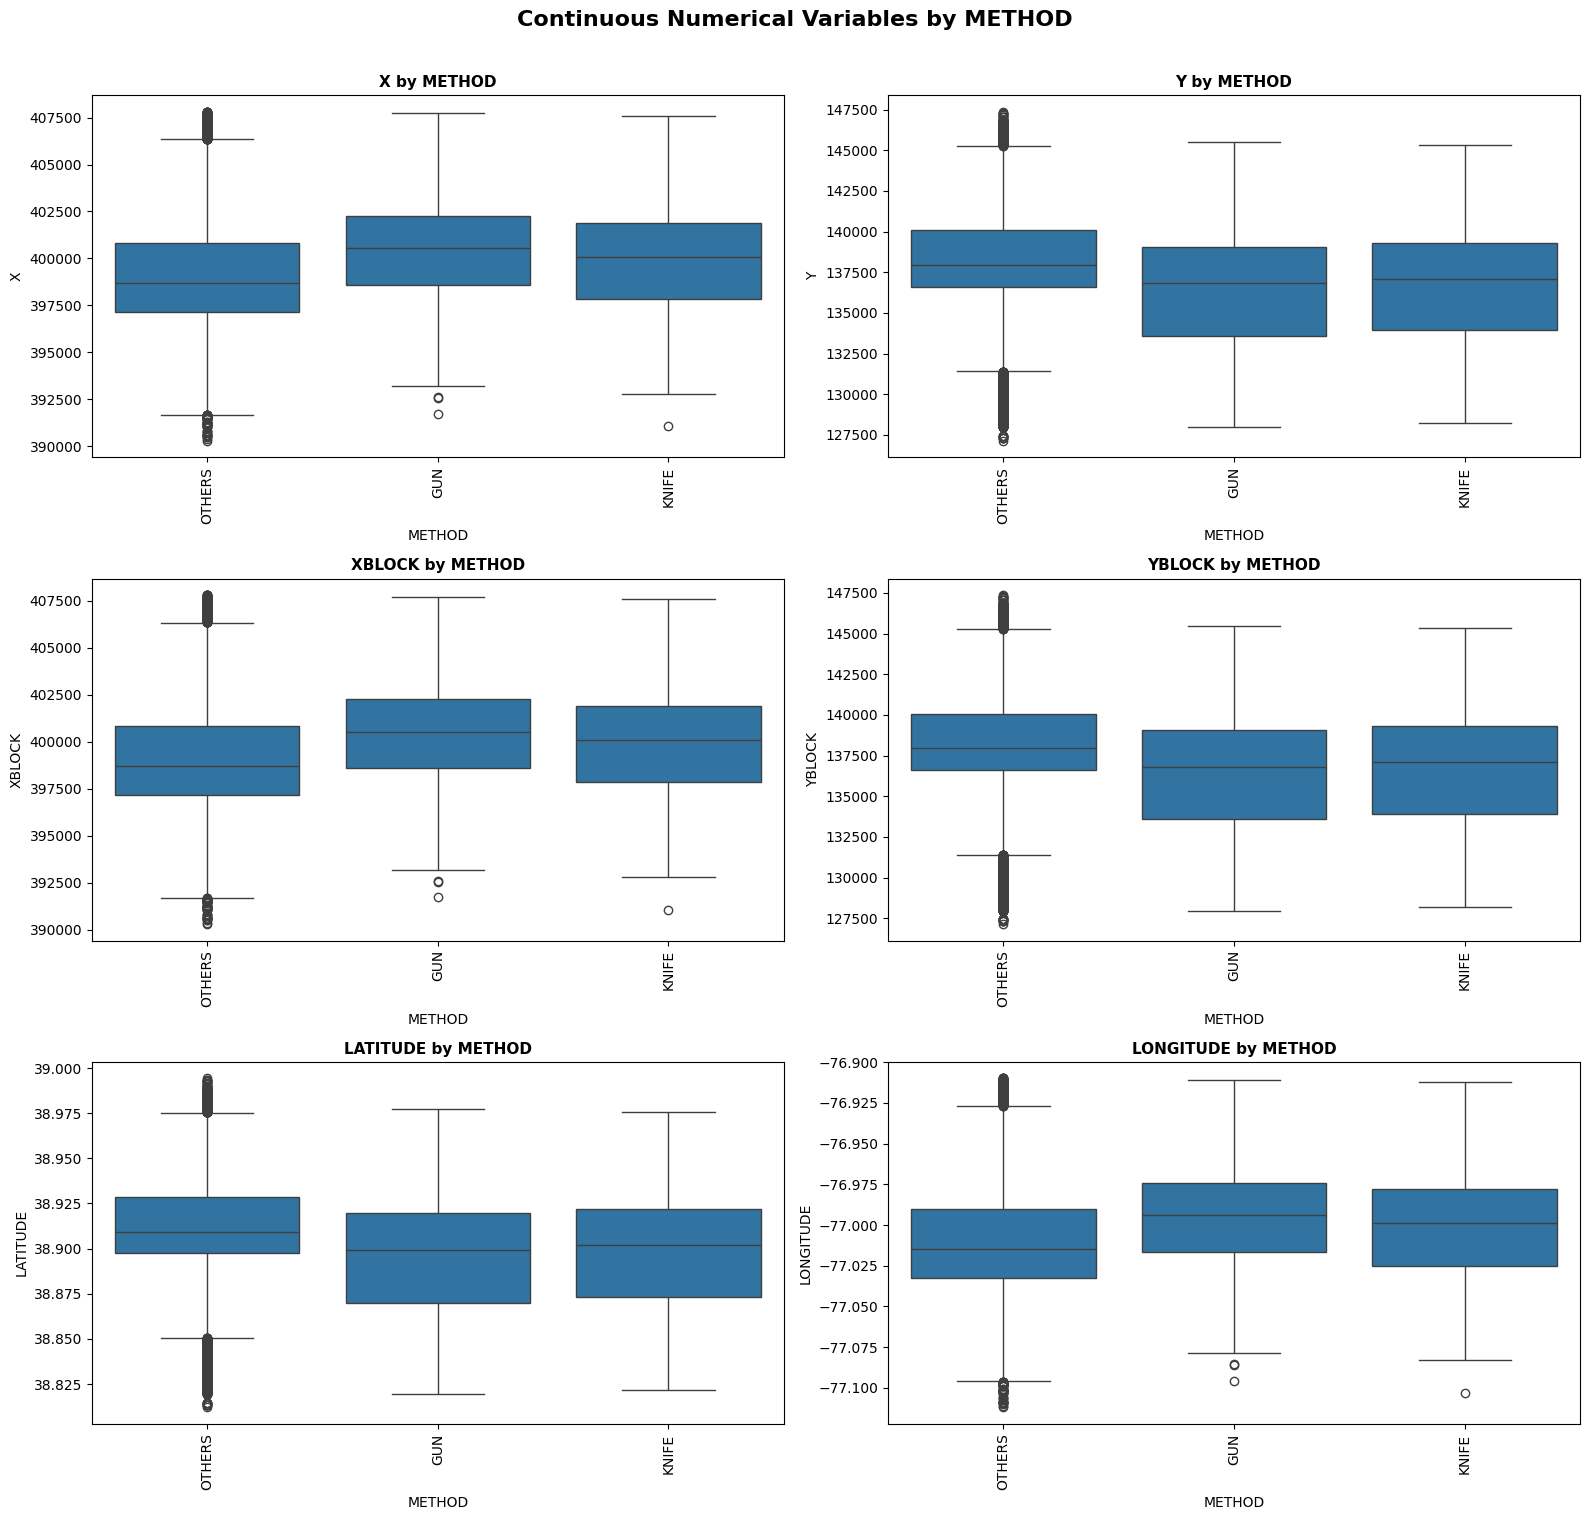

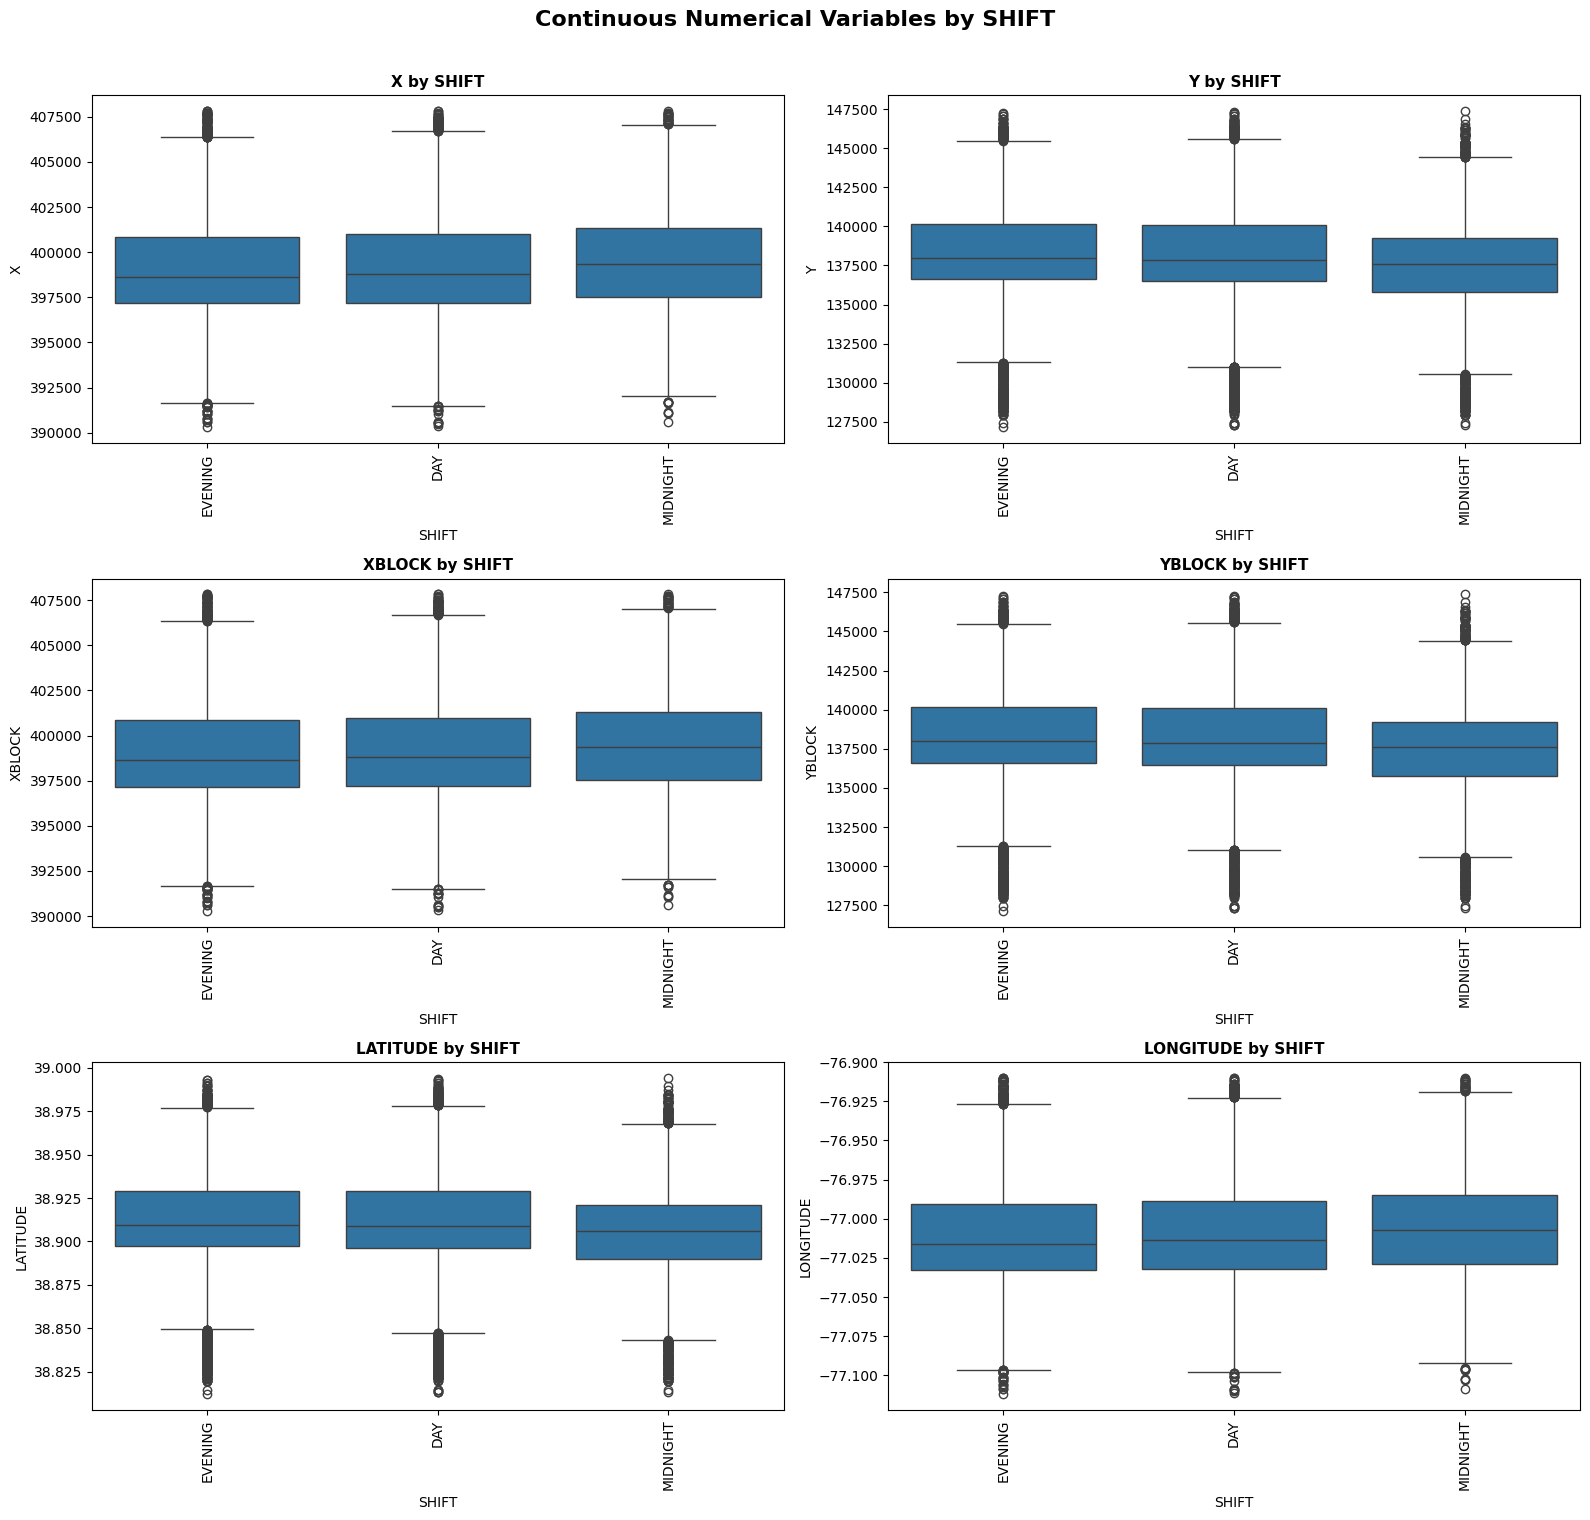

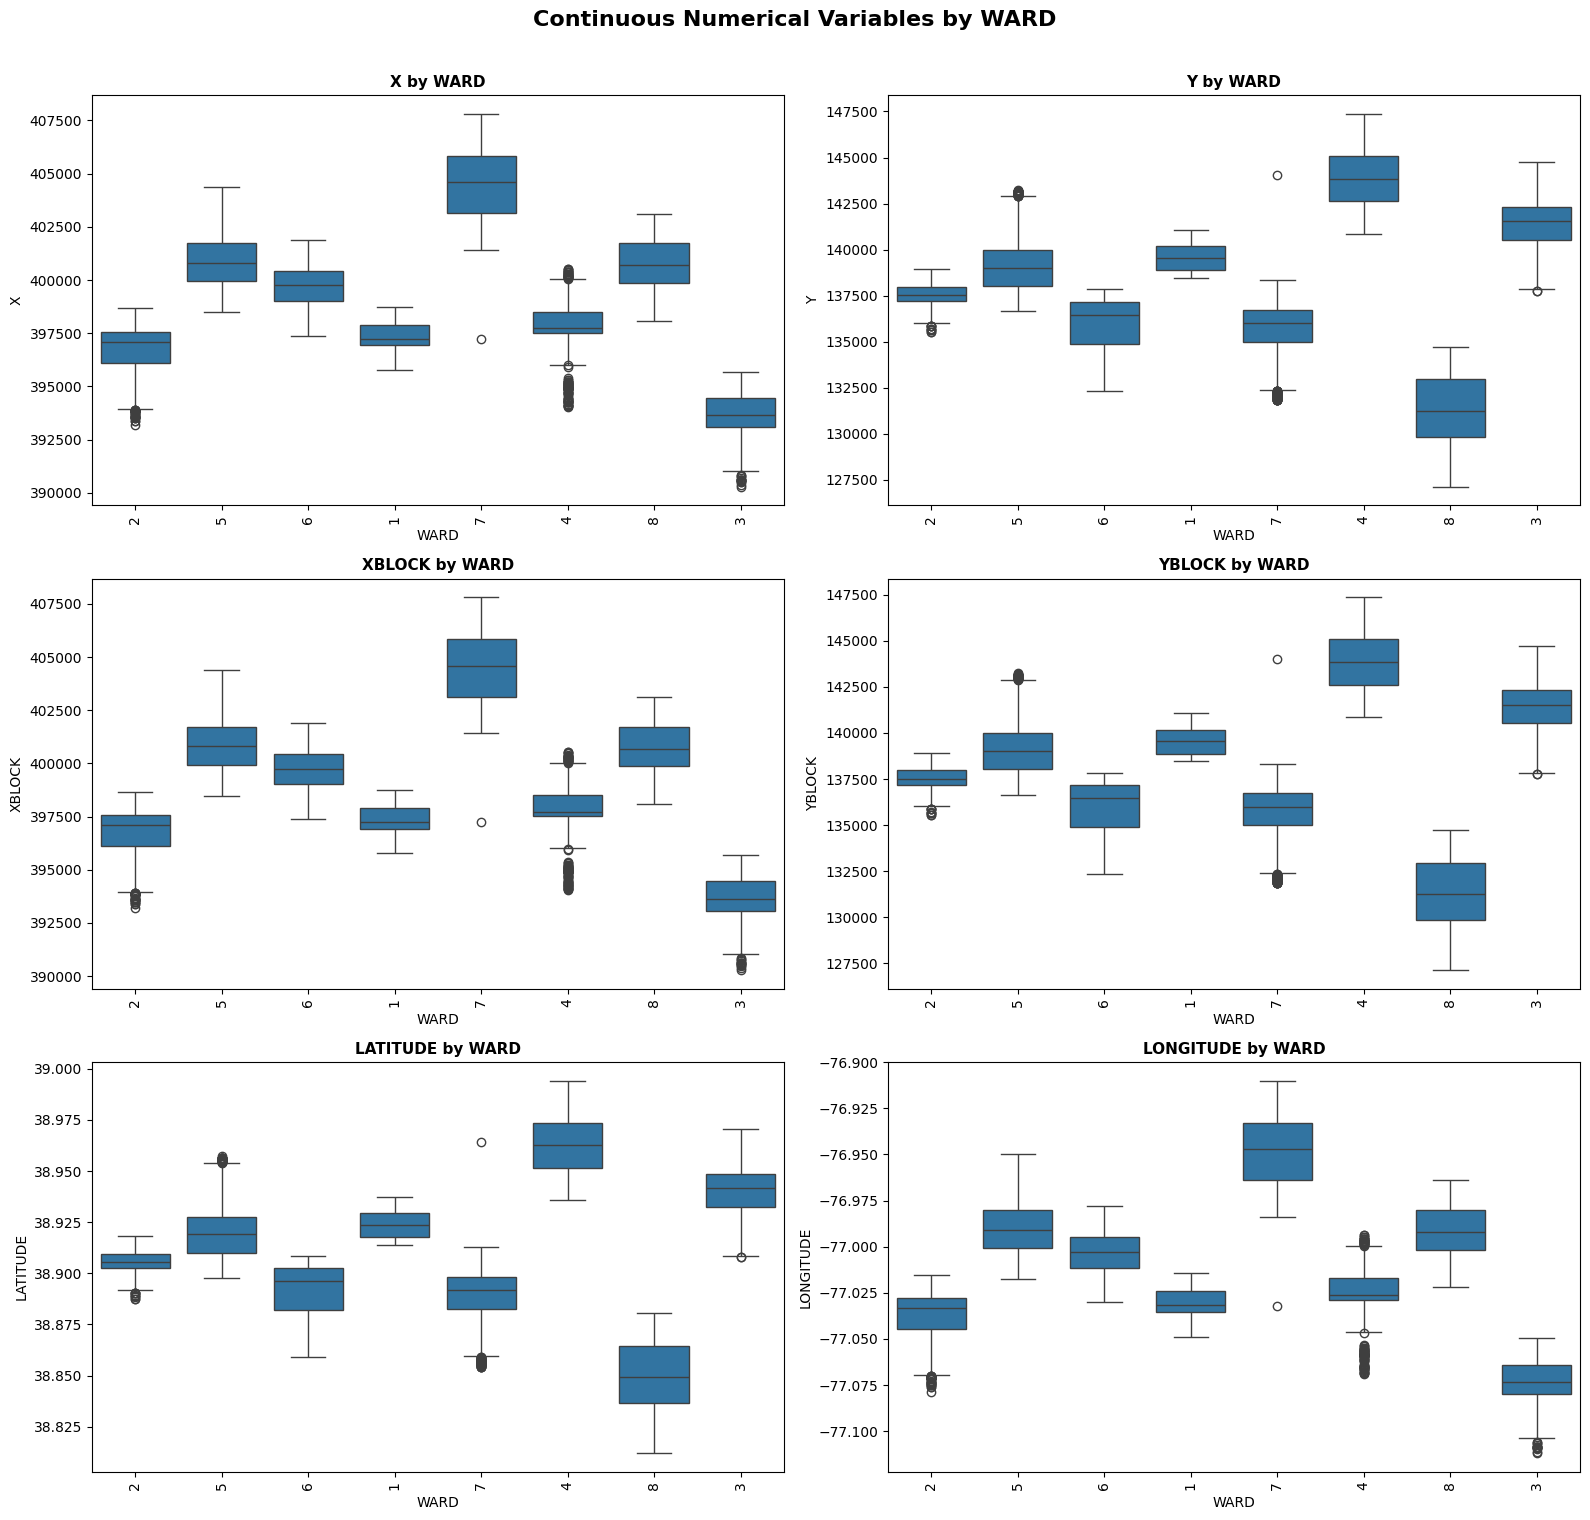

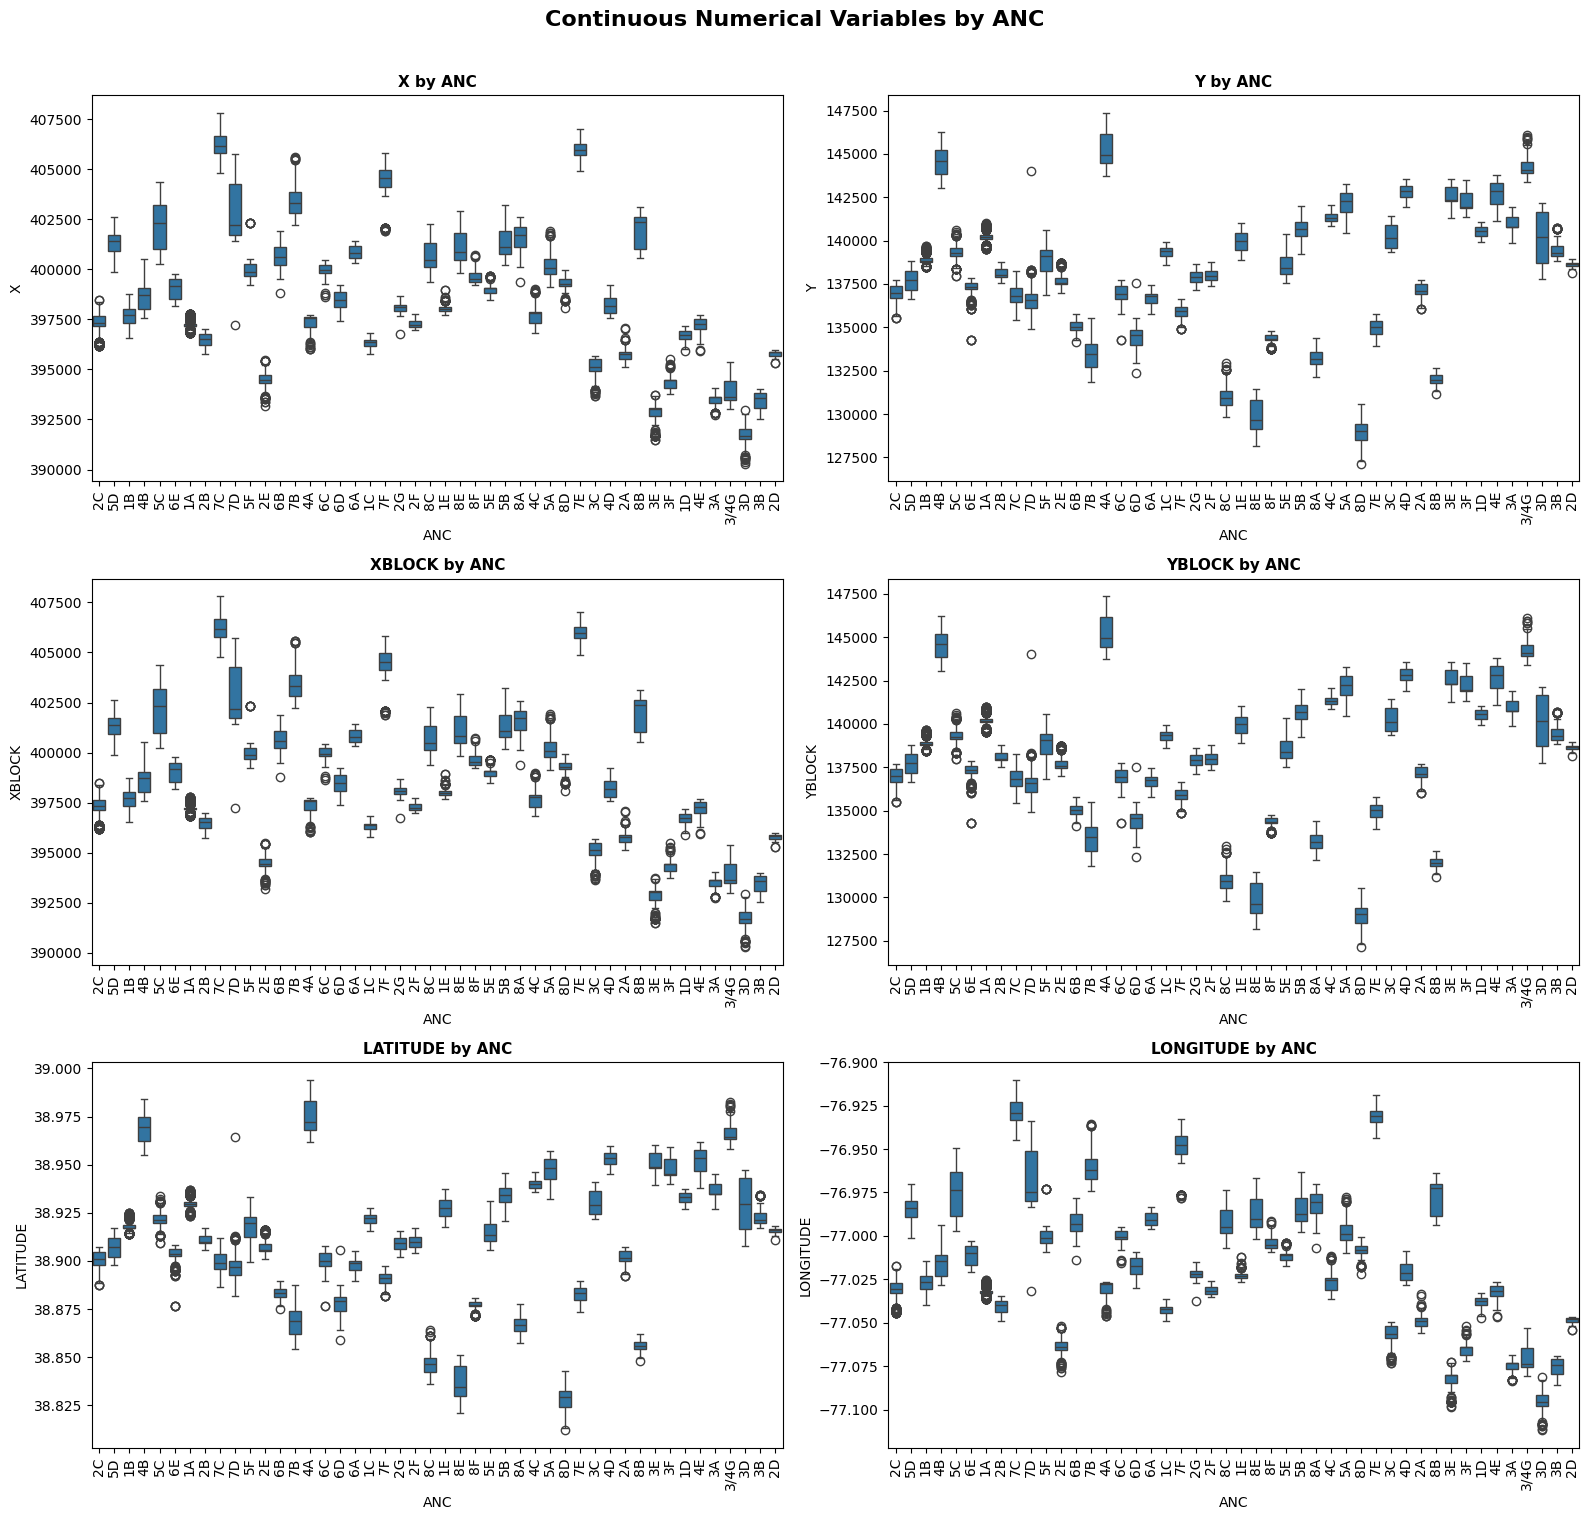

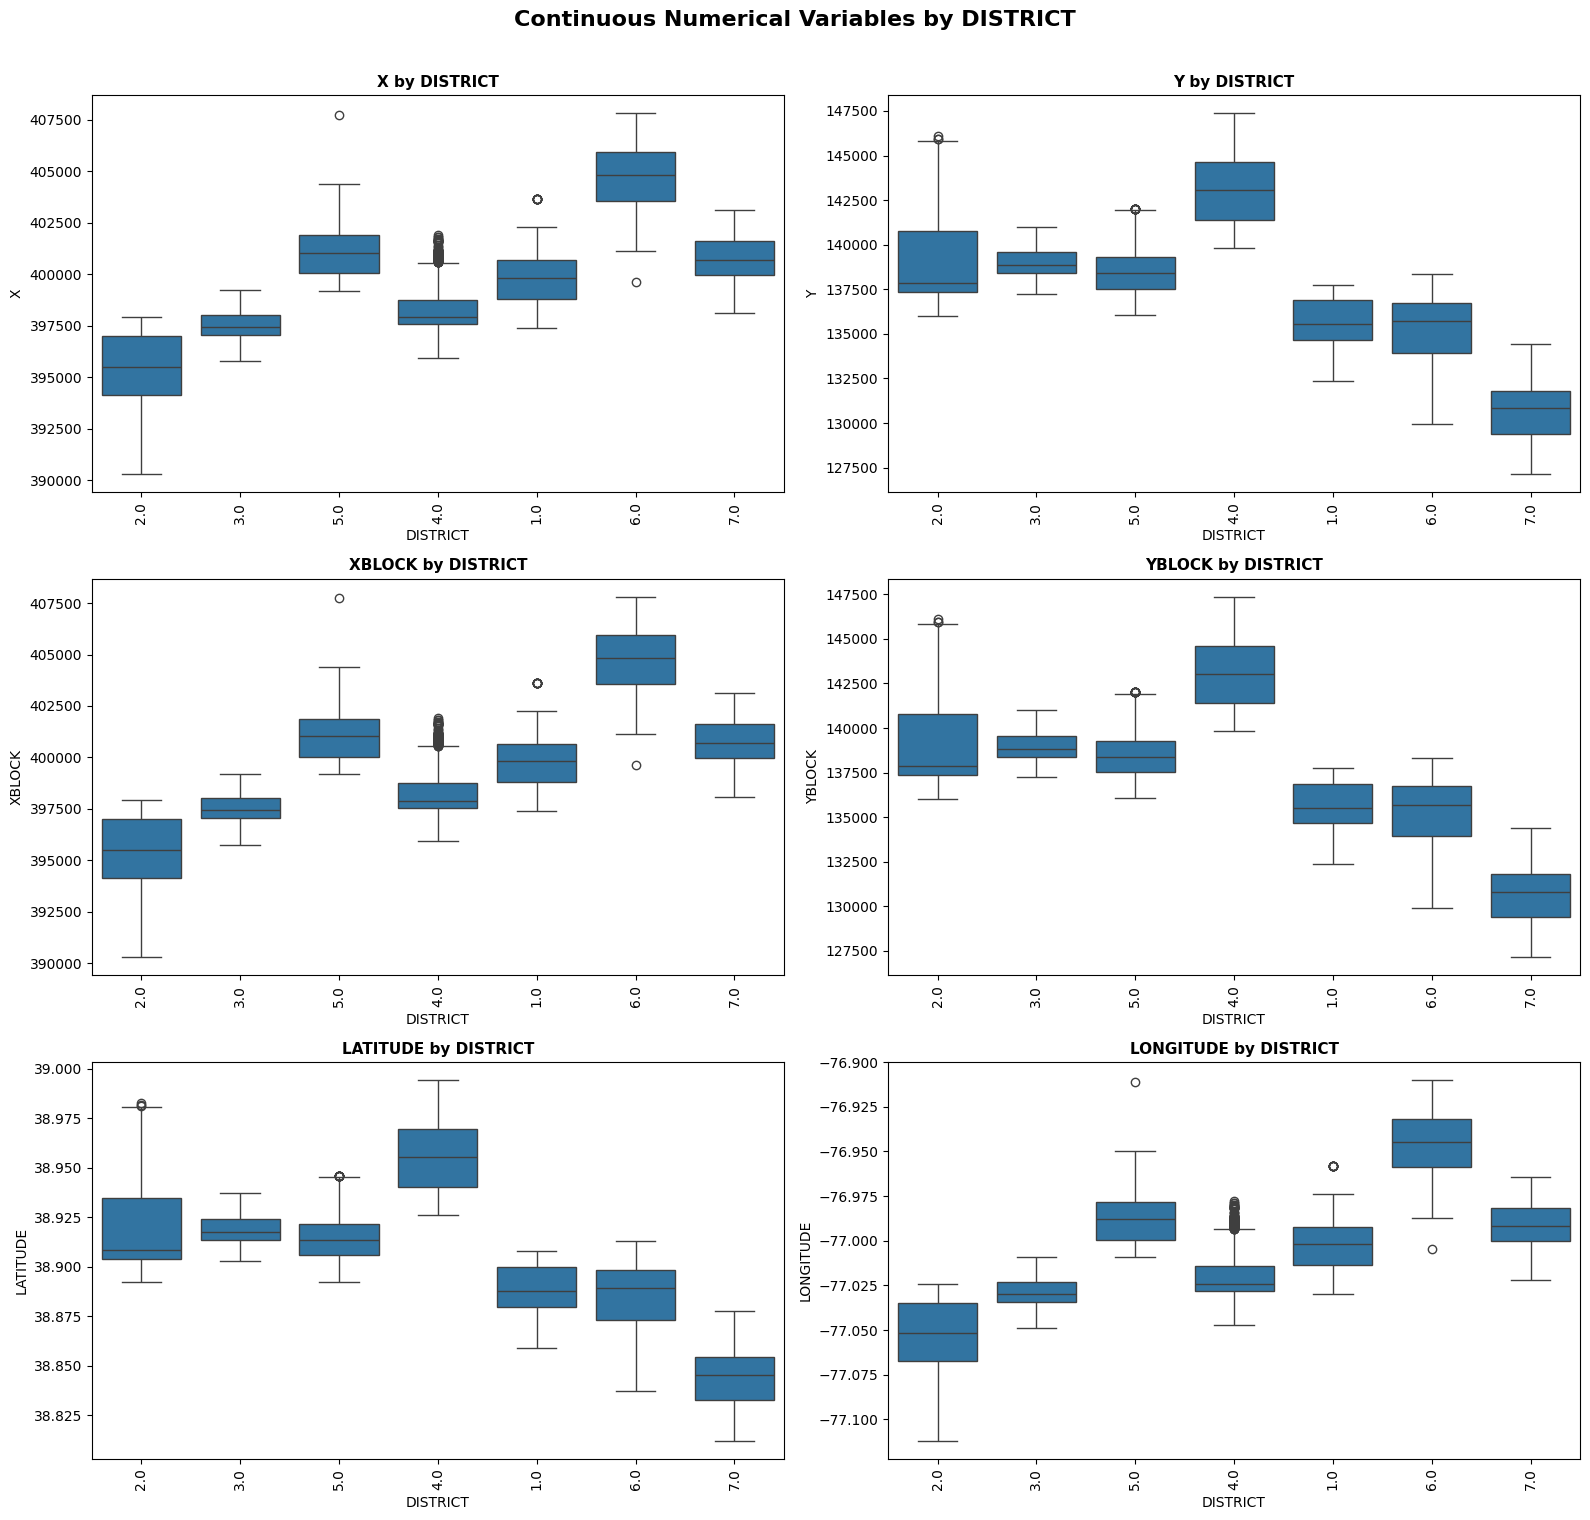

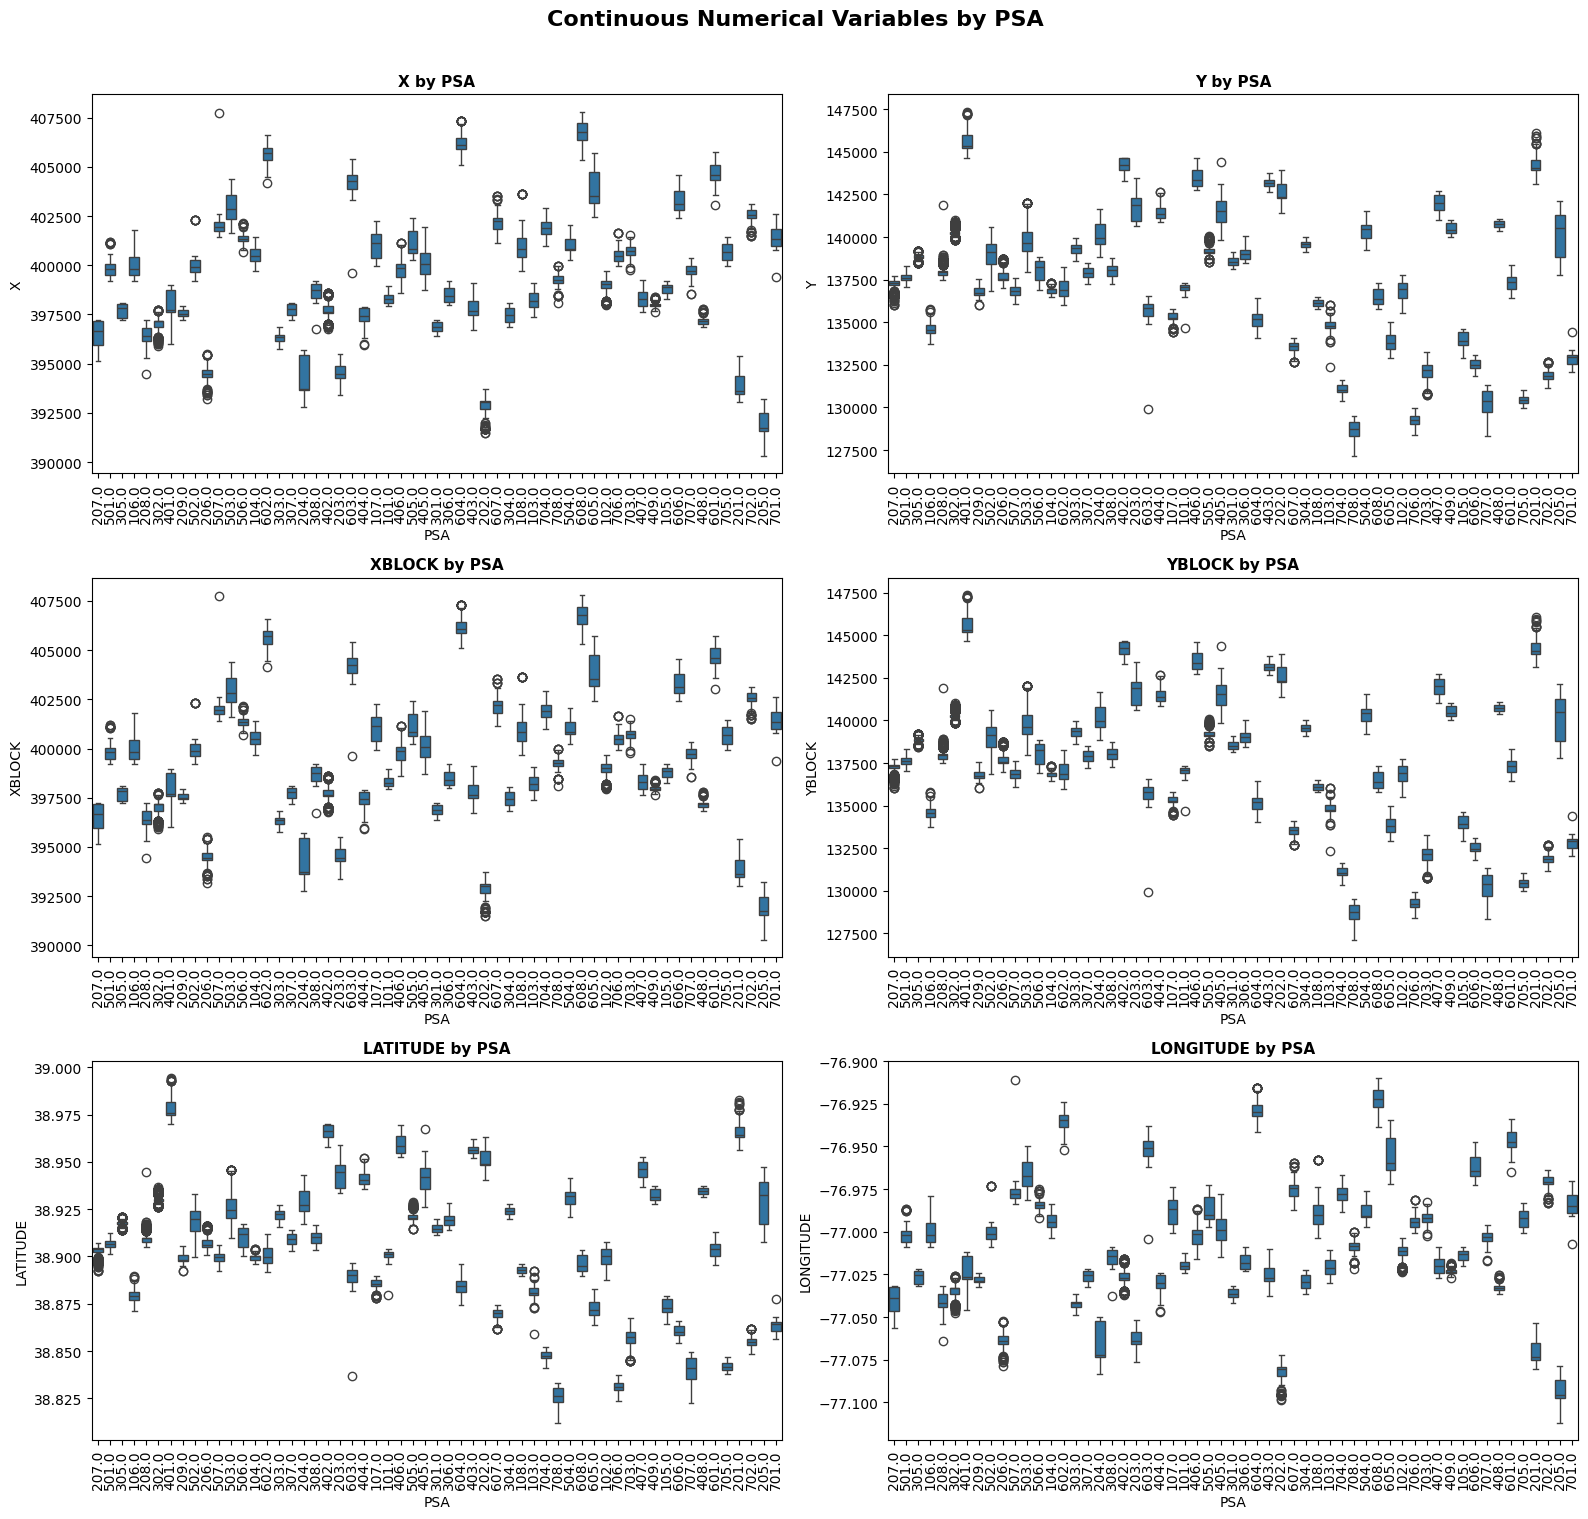

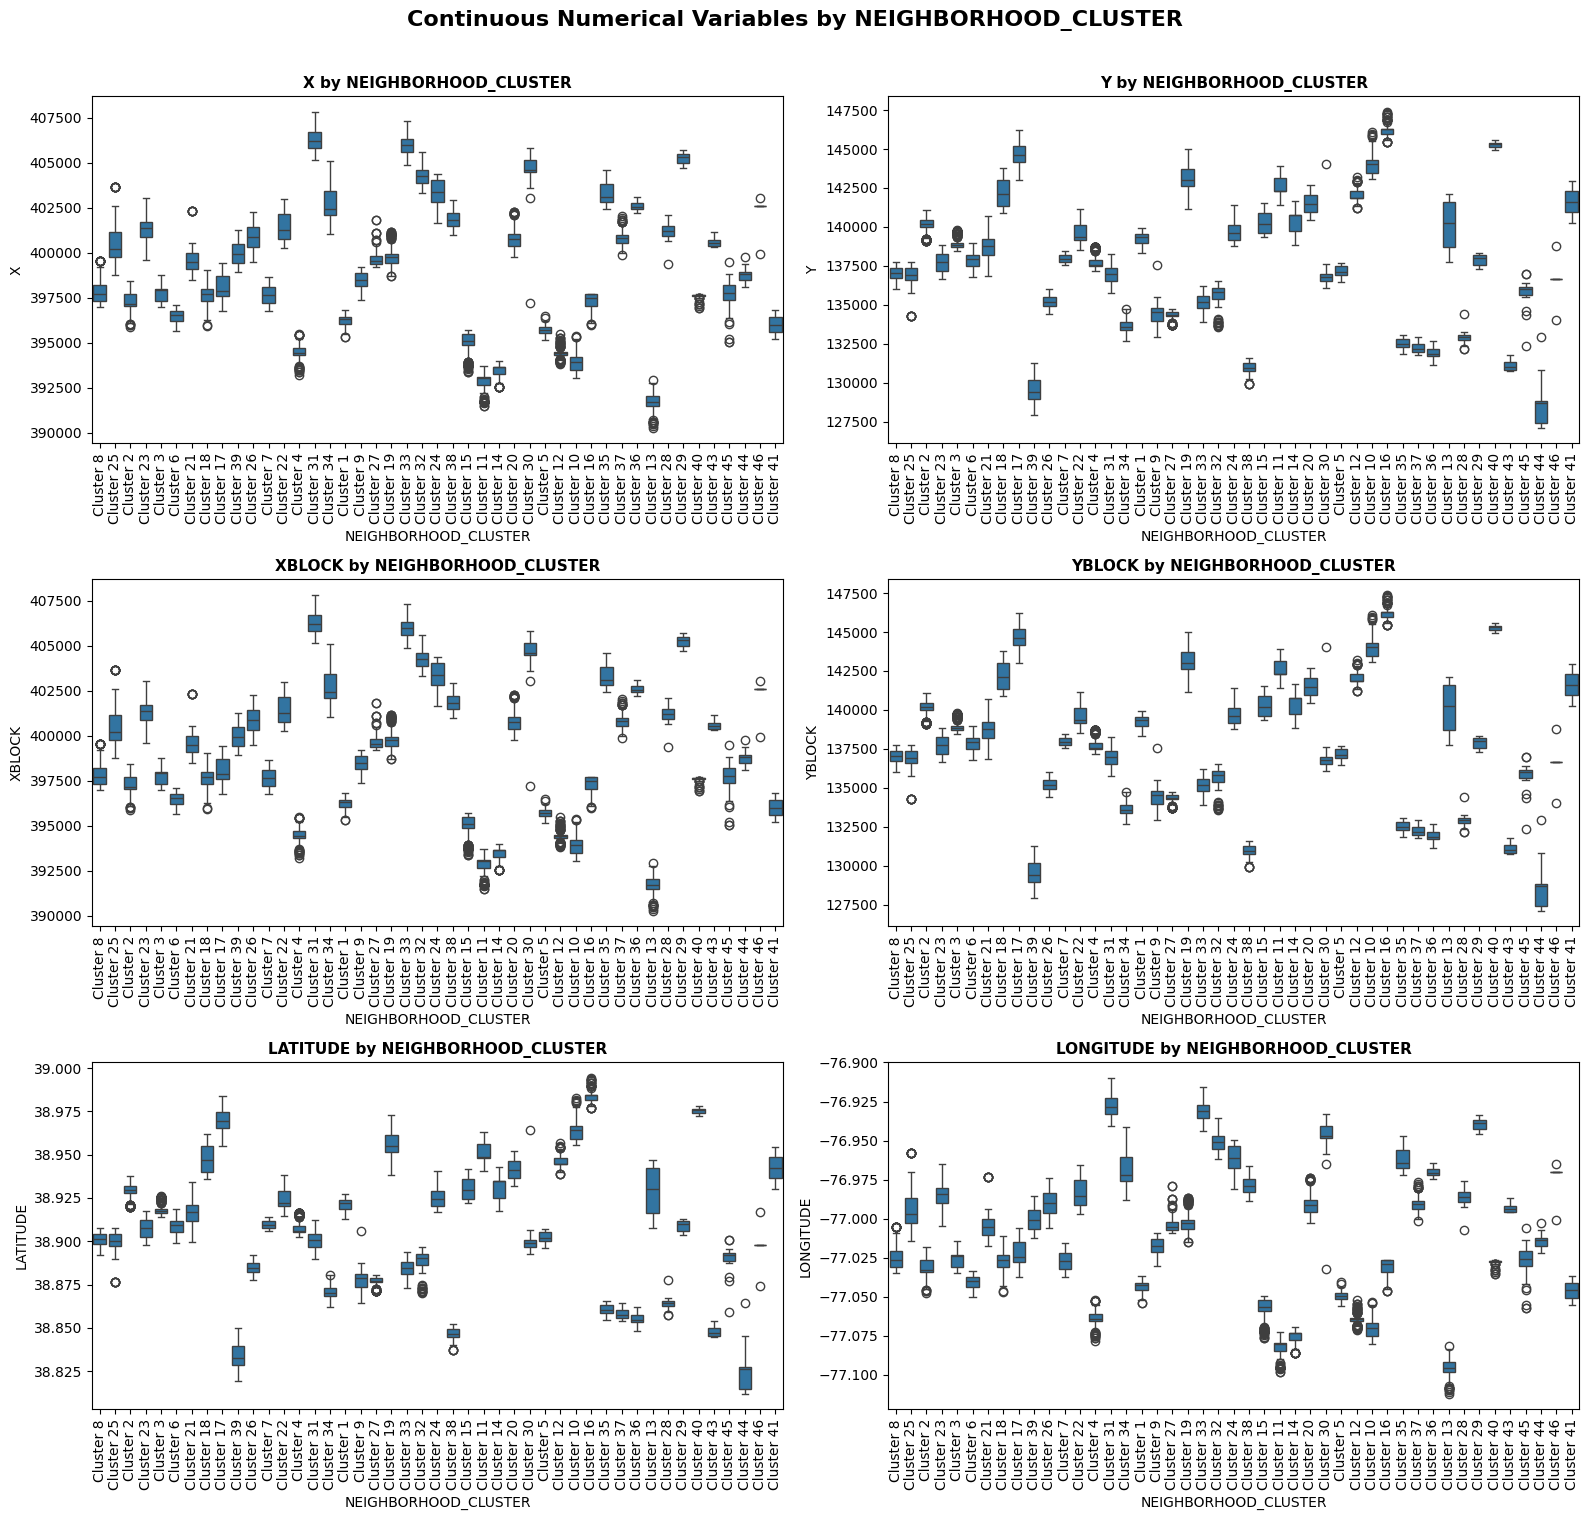

In [25]:
# ==============================================================
# Step 22: Numerical vs Categorical Analysis
# ==============================================================

import math
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous numerical location variables
numerical_cols = [
    "X",
    "Y",
    "XBLOCK",
    "YBLOCK",
    "LATITUDE",
    "LONGITUDE"
]

# Meaningful categorical variables with manageable categories
categorical_cols = [
    "OFFENSE",
    "METHOD",
    "SHIFT",
    "WARD",
    "ANC",
    "DISTRICT",
    "PSA",
    "NEIGHBORHOOD_CLUSTER"
]

# Keep only columns that currently exist in df_clean
numerical_cols = [
    col for col in numerical_cols
    if col in df_clean.columns
]

categorical_cols = [
    col for col in categorical_cols
    if col in df_clean.columns
]

print(f"Continuous Numerical Variables: {len(numerical_cols)}")
print(numerical_cols)

print(f"\nCategorical Variables: {len(categorical_cols)}")
print(categorical_cols)

# Loop through each categorical variable
for cat_col in categorical_cols:

    # Order categories by frequency
    category_order = (
        df_clean[cat_col]
        .value_counts(dropna=False)
        .index
        .tolist()
    )

    n_cols = 2
    n_rows = math.ceil(len(numerical_cols) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 5 * n_rows)
    )

    axes = axes.flatten()

    # Create one boxplot for each numerical variable
    for i, num_col in enumerate(numerical_cols):

        sns.boxplot(
            data=df_clean,
            x=cat_col,
            y=num_col,
            order=category_order,
            ax=axes[i]
        )

        axes[i].set_title(
            f"{num_col} by {cat_col}",
            fontsize=11,
            fontweight="bold"
        )

        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)

        axes[i].tick_params(
            axis="x",
            rotation=90
        )

    # Remove unused subplot spaces
    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"Continuous Numerical Variables by {cat_col}",
        fontsize=16,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()

# Step 22: Bivariate Analysis — Continuous Numerical Variables by Categorical Variables

## Description

This step examines how the six continuous location variables vary across selected categorical variables using boxplots.

The continuous numerical variables analysed are:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

The categorical variables analysed are:

- `OFFENSE`
- `METHOD`
- `SHIFT`
- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`

Each boxplot compares the distribution, median, spread and possible outlying values of a continuous location variable across the categories of another variable.

## Objective

The purpose of this analysis is to:

- Determine whether crime incidents occupy different geographical areas across offence categories.
- Compare crime locations across methods, shifts and administrative divisions.
- Identify categorical variables that contain meaningful spatial information.
- Detect categories with unusually wide or narrow geographical distributions.
- Assess whether some variables provide duplicate or highly overlapping location information.
- Support careful feature selection before statistical modelling or machine-learning development.

## Analysis Performed

For each selected categorical variable, separate boxplots were created for the six continuous numerical variables.

The boxplots display:

- The median location value for each category.
- The interquartile range containing the middle 50% of observations.
- The overall spread represented by the whiskers.
- Individual observations located outside the whiskers.
- Differences in geographical concentration between categories.

## Key Observations

### 1. Continuous Variables by `OFFENSE`

The geographical distributions differ across offence categories.

- Categories such as theft, robbery, burglary, homicide, sex abuse and arson show different median coordinate values.
- Some offences have wider geographical spreads, indicating that they occur across broader parts of the city.
- Other offences have narrower boxes and shorter whiskers, suggesting greater geographical concentration.
- Arson contains comparatively fewer observations, so its boxplots appear narrower and should be interpreted cautiously.
- The differences in `X`, `Y`, `LATITUDE` and `LONGITUDE` suggest that offence type has a meaningful association with incident location.

This indicates that offences are not distributed uniformly across the study area.

### 2. Continuous Variables by `METHOD`

The three method categories—`OTHERS`, `GUN` and `KNIFE`—show visible geographical differences.

- Incidents involving guns and knives have different median location values from incidents classified as other methods.
- The `OTHERS` category contains the largest number of observations and displays a broader distribution.
- Gun- and knife-related incidents appear more concentrated in particular geographical regions.
- The coordinate differences suggest that incident method may contain useful spatial information.

However, the categories are imbalanced because `OTHERS` represents the majority of incidents.

### 3. Continuous Variables by `SHIFT`

The distributions across `DAY`, `EVENING` and `MIDNIGHT` are broadly similar.

- The median values of the location variables are relatively close across the three shifts.
- Midnight incidents show small geographical shifts in some coordinates.
- The overall ranges overlap considerably.
- Outlying observations are present across all shifts.

This suggests that time of day has a weaker relationship with geographical location than administrative variables such as ward or district.

### 4. Continuous Variables by `WARD`

Strong geographical differences are visible across wards.

- Each ward occupies a distinct range of `X`, `Y`, `LATITUDE` and `LONGITUDE`.
- Several ward distributions have limited overlap.
- The median coordinate values vary substantially between wards.
- The ordering of the ward boxplots reflects their geographical placement within the city.

These results are expected because wards are geographical administrative areas. `WARD` therefore carries substantial spatial information.

### 5. Continuous Variables by `ANC`

The Advisory Neighborhood Commission categories show considerable geographical variation.

- Median coordinate values differ noticeably across ANC categories.
- Many ANC categories have narrow distributions, indicating that incidents are concentrated within clearly defined geographical boundaries.
- Categories with fewer observations produce smaller or less stable boxes.
- The large number of ANC categories makes the plots crowded and reduces label readability.

`ANC` contains detailed geographical information, but its relatively high cardinality may increase model complexity.

### 6. Continuous Variables by `DISTRICT`

Districts display clear and systematic separation across all location variables.

- The medians of `X`, `Y`, `LATITUDE` and `LONGITUDE` differ strongly between districts.
- Several district distributions show limited overlap.
- District 4 occupies noticeably different coordinate ranges from many other districts.
- Districts 2 and 7 also show distinctive geographical positions.

This confirms that `DISTRICT` is strongly associated with incident location and acts as a broader geographical grouping variable.

### 7. Continuous Variables by `PSA`

The Police Service Area categories show detailed geographical variation.

- Median coordinate values differ across PSA categories.
- Several PSAs occupy very narrow coordinate ranges.
- Some PSAs contain visibly different spreads due to variations in geographical size and incident volume.
- The large number of categories makes the x-axis crowded and difficult to interpret in a single combined figure.

`PSA` provides detailed spatial information but has relatively high cardinality and may overlap with district, ward, ANC and neighbourhood information.

### 8. Continuous Variables by `NEIGHBORHOOD_CLUSTER`

Neighbourhood clusters show clear geographical separation.

- Different clusters occupy distinct coordinate and latitude-longitude ranges.
- Several clusters have narrow boxes, indicating concentrated incident locations.
- Other clusters show broader distributions, possibly reflecting larger or irregularly shaped neighbourhood areas.
- Median location values vary substantially across clusters.
- The large number of clusters results in crowded category labels.

`NEIGHBORHOOD_CLUSTER` contains strong location information and may be useful for spatial analysis, although it may duplicate information contained in the raw coordinate variables.

## Relationship Between the Coordinate Variables

The plots reinforce the earlier finding that the coordinate variables form two nearly duplicate pairs:

- `X` and `XBLOCK`
- `Y` and `YBLOCK`

Similarly:

- `LONGITUDE` closely follows the east-west position represented by `X` and `XBLOCK`.
- `LATITUDE` closely follows the north-south position represented by `Y` and `YBLOCK`.

The boxplot patterns for each pair are almost identical across the categorical variables. This confirms that the six continuous variables do not represent six independent geographical measurements.

Using all of them simultaneously could:

- Add redundant information.
- Increase multicollinearity.
- Increase model complexity.
- Distort feature-importance results.
- Encourage overfitting.
- Make model interpretation more difficult.

## Outlier Interpretation

Several observations appear outside the boxplot whiskers.

These points should not automatically be treated as incorrect records because:

- They may represent valid incidents occurring near the geographical boundaries of a category.
- Administrative areas can have irregular shapes.
- Some categories contain incidents distributed across disconnected or widely separated locations.
- A point may be unusual relative to its category while still being geographically valid.

The plotted points should therefore be investigated before any outlier-removal decision is made.

## Data Quality and Modelling Considerations

The analysis highlights an important distinction between useful geographical information and redundant geographical information.

Variables such as `WARD`, `ANC`, `DISTRICT`, `PSA` and `NEIGHBORHOOD_CLUSTER` are meaningful categorical identifiers, but they describe related administrative representations of location.

The continuous variables also describe the same underlying location through different coordinate systems.

Including all geographical variables in one model may:

- Provide little additional predictive information.
- Create strong multicollinearity.
- Generate a large number of encoded features.
- Increase computational requirements.
- Cause the model to memorise highly specific locations.
- Increase the risk of spatial overfitting.
- Produce misleading feature-importance rankings.

High-cardinality variables such as `ANC`, `PSA` and `NEIGHBORHOOD_CLUSTER` require especially careful treatment because some categories may contain relatively few incidents.

## Overall Interpretation

The boxplots confirm that incident location varies meaningfully across offence types, methods and administrative geographical categories.

The strongest geographical separation is observed across:

- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`

The distributions across `SHIFT` are comparatively similar, indicating a weaker geographical relationship with time of day.

`OFFENSE` and `METHOD` also show visible spatial differences, suggesting that particular crime types and methods are more concentrated in certain locations.

At the same time, the results reveal substantial duplication among the geographical variables. The categorical administrative areas and continuous coordinate measurements all describe different representations of the same underlying spatial structure.

## Importance of This Step

This analysis is important because it:

- Reveals geographical differences between crime categories.
- Identifies administrative variables with strong spatial information.
- Highlights categorical variables with high cardinality.
- Confirms redundancy among multiple coordinate representations.
- Prevents identifiers and geographical codes from being treated as ordinary continuous measurements.
- Supports more reliable feature selection.
- Reduces the risk of multicollinearity and overfitting.
- Helps distinguish meaningful spatial patterns from duplicated location information.

Overall, the bivariate boxplot analysis confirms that location is a major structural component of the crime incident dataset, but the geographical variables must be selected carefully to avoid unnecessary duplication and excessive model complexity.

Selected Categorical Variables: ['OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER']

Total Pairs: 28


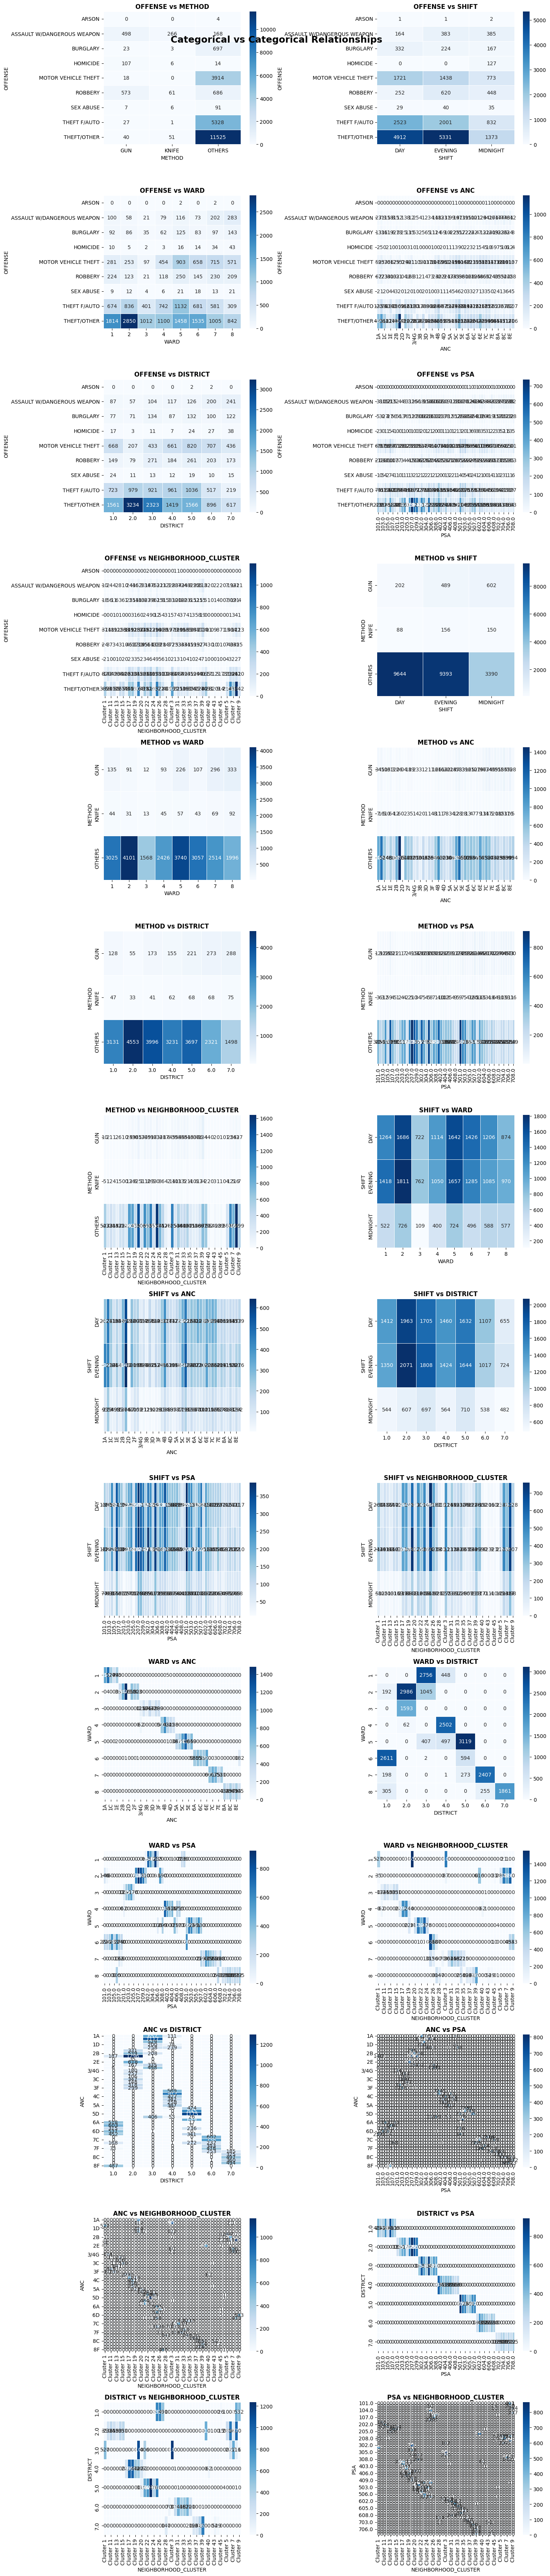

In [26]:
# ==========================================================
# Step 23: Categorical vs Categorical Analysis
# (Reusable Code)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ----------------------------------------------------------
# Select important categorical variables
# ----------------------------------------------------------

categorical_cols = [
     "OFFENSE",
    "METHOD",
    "SHIFT",
    "WARD",
    "ANC",
    "DISTRICT",
    "PSA",
    "NEIGHBORHOOD_CLUSTER"
]

print(f"Selected Categorical Variables: {categorical_cols}")

# ----------------------------------------------------------
# Create all unique variable pairs
# ----------------------------------------------------------

pairs = []

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):
        pairs.append((categorical_cols[i], categorical_cols[j]))

print(f"\nTotal Pairs: {len(pairs)}")

# ----------------------------------------------------------
# Plot Heatmaps
# ----------------------------------------------------------

cols = 2
rows = math.ceil(len(pairs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for ax, (var1, var2) in zip(axes, pairs):

    cross_tab = pd.crosstab(df_clean[var1], df_clean[var2])

    sns.heatmap(
        cross_tab,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f"{var1} vs {var2}", fontsize=12, fontweight="bold")

# Remove unused axes
for ax in axes[len(pairs):]:
    fig.delaxes(ax)

plt.suptitle(
    "Categorical vs Categorical Relationships",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Step 23: Bivariate Analysis — Categorical Variables by Categorical Variables

### Description

This step examines the relationships between selected categorical variables using cross-tabulation heatmaps. Each heatmap displays the number of crime incidents recorded for every combination of two categorical variables.

The analysis used the following variables:

- `OFFENSE`
- `METHOD`
- `SHIFT`
- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`

A total of **28 unique categorical-variable pairs** were generated and compared.

### Key Observations

#### Offence relationships

- `THEFT/OTHER` is the most frequent offence across most methods, shifts and geographic categories.
- `THEFT F/AUTO` and `MOTOR VEHICLE THEFT` also contribute substantial numbers of incidents.
- Most offences were recorded under the `OTHERS` method category.
- Gun-related incidents are more strongly associated with offences such as robbery and assault with a dangerous weapon.
- Knife-related incidents occur less frequently than both gun and other-method incidents.
- Crime counts vary across day, evening and midnight shifts, with day and evening generally recording more incidents than midnight.

#### Method and shift relationships

- The `OTHERS` method strongly dominates all three shifts.
- Gun and knife incidents occur across each shift but at considerably lower frequencies.
- Day and evening shifts have broadly similar incident volumes, while midnight records fewer incidents.
- The method distribution remains relatively consistent across wards and districts.

#### Geographic relationships

- Clear structural relationships are visible among `WARD`, `ANC`, `DISTRICT`, `PSA` and `NEIGHBORHOOD_CLUSTER`.
- Particular wards are concentrated within specific police districts rather than being distributed evenly across all districts.
- Individual ANCs, PSAs and neighbourhood clusters are associated with defined geographic areas.
- The diagonal and block-like patterns in several heatmaps indicate that these variables describe overlapping administrative or spatial boundaries.
- `DISTRICT` and `PSA`, as well as `PSA` and `NEIGHBORHOOD_CLUSTER`, show especially strong geographic dependence.
- These relationships confirm that many geographic variables contain similar location information at different levels of detail.

### Readability Considerations

Some heatmaps involving `ANC`, `PSA` and `NEIGHBORHOOD_CLUSTER` are visually crowded because these variables contain many categories. Their overlapping labels and annotations make individual values difficult to read.

The plots remain useful for identifying broad concentration patterns, but detailed interpretation of high-cardinality pairs may require:

- displaying only the most frequent categories;
- removing numerical annotations;
- increasing the figure size;
- using row-normalised percentages instead of raw counts; or
- analysing selected geographic pairs separately.

### Analytical Importance

This analysis demonstrates that crime characteristics are not distributed independently across categorical variables. Offence type is associated with method and shift, while the geographic variables show strong structural dependence.

The close relationships among ward, ANC, district, PSA and neighbourhood cluster also indicate potential redundancy. Including all of these variables together in a machine-learning model could:

- increase model complexity;
- introduce multicollinearity-like redundancy after encoding;
- increase the number of encoded features;
- raise the risk of overfitting; and
- cause the model to place excessive importance on location.

The categorical relationships should therefore be considered carefully during feature selection and model preparation.

In [27]:
# ==========================================================
# Step 24: Multicollinearity Analysis (Variance Inflation Factor)
# Reusable Code
# ==========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Select only continuous numerical variables
# ----------------------------------------------------------

continuous_cols = [
    "X",
    "Y",
    "XBLOCK",
    "YBLOCK",
    "LATITUDE",
    "LONGITUDE"
]

# Create a copy
vif_data = df_clean[continuous_cols].copy()

# Remove missing values
vif_data = vif_data.dropna()

print(f"Total Variables for VIF: {len(vif_data.columns)}")
print(list(vif_data.columns))

# ----------------------------------------------------------
# Calculate VIF
# ----------------------------------------------------------

vif = pd.DataFrame()

vif["Variable"] = vif_data.columns

vif["VIF"] = [
    variance_inflation_factor(vif_data.values, i)
    for i in range(vif_data.shape[1])
]

# Round results
vif["VIF"] = vif["VIF"].round(2)

# Sort from highest to lowest
vif = vif.sort_values(by="VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
display(vif)

Total Variables for VIF: 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']

Variance Inflation Factor (VIF):


C:\Users\mapfi\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
2,XBLOCK,inf
0,X,4.503600e+15
1,Y,1.976680e+03
3,YBLOCK,8.834500e+02
4,LATITUDE,6.000000e-02
5,LONGITUDE,0.000000e+00


## Step 24: Multicollinearity Analysis — Variance Inflation Factor

### Description

This step evaluates multicollinearity among the six continuous location variables using the Variance Inflation Factor (VIF).

The variables assessed were:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

VIF measures how strongly each numerical variable can be explained by the remaining numerical variables. A high VIF indicates that a variable contains information that is already represented by other variables.

### VIF Interpretation Guide

- A VIF close to **1** indicates little or no multicollinearity.
- A VIF between **1 and 5** generally indicates a moderate relationship.
- A VIF above **5** suggests potentially problematic multicollinearity.
- A VIF above **10** indicates severe multicollinearity.
- An infinite VIF indicates that a variable can be predicted perfectly from one or more of the other variables.

### Results

The VIF analysis produced extremely high values:

- `XBLOCK` returned an infinite VIF.
- `X` returned a VIF of approximately \(4.50 \times 10^{15}\).
- `Y` returned a VIF of approximately 1,976.68.
- `YBLOCK` returned a VIF of approximately 883.45.
- `LATITUDE` returned a VIF of approximately 600.
- `LONGITUDE` returned an unusual value of zero because of numerical instability in the VIF calculation.

### Key Observations

- Severe multicollinearity exists among all six continuous location variables.
- `X` and `XBLOCK` represent almost identical east–west coordinate information.
- `Y` and `YBLOCK` represent almost identical north–south coordinate information.
- `LONGITUDE` is effectively a transformed representation of `X` and `XBLOCK`.
- `LATITUDE` is effectively a transformed representation of `Y` and `YBLOCK`.
- The infinite and extremely large VIF values confirm the perfect or near-perfect relationships previously identified by the scatter plots and correlation matrix.
- The divide-by-zero warning occurred because at least one variable was predicted perfectly by the remaining variables, producing an \(R^2\) value of 1.

### Analytical Importance

Using all six coordinate variables together would add substantial redundant information without providing six independent location measurements.

This redundancy could:

- make coefficient-based models unstable;
- distort coefficient interpretation;
- increase model complexity;
- produce unreliable feature-importance results; and
- increase the risk of overfitting.

Only one coordinate pair should normally be retained to represent location, such as `LATITUDE` and `LONGITUDE`, while the duplicated coordinate representations should be excluded from the final modelling features.

In [28]:
# ============================================================
# Step 25: Detect Outliers Using the IQR Method
# ============================================================

import pandas as pd

# Select continuous numerical variables
continuous_cols = [
    "X",
    "Y",
    "XBLOCK",
    "YBLOCK",
    "LATITUDE",
    "LONGITUDE"
]

# Create an empty list to store results
iqr_summary = []

# Loop through each continuous variable
for col in continuous_cols:

    # Calculate Quartiles
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate Lower and Upper Bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Detect Outliers
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    # Save Summary
    iqr_summary.append({
        "Variable": col,
        "Q1": round(Q1, 3),
        "Q3": round(Q3, 3),
        "IQR": round(IQR, 3),
        "Lower Bound": round(lower_bound, 3),
        "Upper Bound": round(upper_bound, 3),
        "Outliers": len(outliers),
        "Outlier (%)": round((len(outliers) / len(df_clean)) * 100, 2)
    })

# Convert to DataFrame
iqr_summary = pd.DataFrame(iqr_summary)

# Display Results
print("=" * 70)
print("Step 25: IQR Outlier Detection Summary")
print("=" * 70)

display(iqr_summary)

Step 25: IQR Outlier Detection Summary


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier (%)
0,X,397203.830,400986.558,3782.727,391529.739,406660.649,252,1.05
1,Y,136473.742,139967.520,3493.777,131233.076,145208.186,1793,7.44
2,XBLOCK,397203.830,400986.558,3782.727,391529.739,406660.649,252,1.05
3,YBLOCK,136473.742,139967.520,3493.777,131233.076,145208.186,1793,7.44
4,LATITUDE,38.896,38.928,0.031,38.849,38.975,1796,7.45
5,LONGITUDE,-77.032,-76.989,0.044,-77.098,-76.923,251,1.04


## Step 25: Outlier Detection Using the IQR Method

### Description

This step detects potential outliers in the six continuous location variables using the Interquartile Range (IQR) method.

The variables assessed were:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

For each variable, the first quartile (`Q1`) and third quartile (`Q3`) were calculated. The interquartile range was then obtained using:

\[
IQR = Q3 - Q1
\]

Values were classified as potential outliers when they fell below or above the following limits:

\[
\text{Lower Bound} = Q1 - 1.5 \times IQR
\]

\[
\text{Upper Bound} = Q3 + 1.5 \times IQR
\]

### Results

The IQR analysis produced the following outlier counts:

- `X` contained **252 potential outliers**, representing approximately **1.05%** of the observations.
- `XBLOCK` also contained **252 potential outliers**, representing approximately **1.05%** of the observations.
- `LONGITUDE` contained **251 potential outliers**, representing approximately **1.04%** of the observations.
- `Y` contained **1,793 potential outliers**, representing approximately **7.44%** of the observations.
- `YBLOCK` also contained **1,793 potential outliers**, representing approximately **7.44%** of the observations.
- `LATITUDE` contained **1,796 potential outliers**, representing approximately **7.45%** of the observations.

### Key Observations

- The east–west coordinate variables, `X`, `XBLOCK`, and `LONGITUDE`, contain relatively few potential outliers, at approximately 1% each.
- The north–south coordinate variables, `Y`, `YBLOCK`, and `LATITUDE`, contain a noticeably higher proportion of potential outliers, at approximately 7.4% each.
- `X` and `XBLOCK` produced identical quartiles, IQR limits and outlier counts because they contain the same or nearly identical coordinate information.
- `Y` and `YBLOCK` also produced identical quartiles, IQR limits and outlier counts.
- The closely matching results for `Y`, `YBLOCK`, and `LATITUDE` further confirm that these variables are alternative representations of the same north–south geographic position.
- Similarly, the matching results for `X`, `XBLOCK`, and `LONGITUDE` confirm their strong spatial redundancy.

### Interpretation

The values identified by the IQR method should be treated as potential statistical outliers rather than automatically classified as incorrect records.

Because these variables represent geographic coordinates, observations outside the IQR limits may correspond to legitimate incidents located near the outer geographical boundaries of the study area. Removing them without further investigation could eliminate valid crime-location records and distort the spatial coverage of the dataset.

### Analytical Importance

This analysis confirms that outlier patterns are repeated across the duplicated coordinate systems. Therefore, decisions about outlier handling should not be made independently for all six variables.

The geographic validity of the observations should be considered before applying removal, capping or transformation. The results should also be interpreted alongside the scatter plots, boxplots and known geographic boundaries of the dataset.

In [29]:
# ============================================================
# Step 26: Detect Outliers Using the Z-score Method
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import zscore

# Select continuous numerical variables
continuous_cols = [
     "X",
    "Y",
    "XBLOCK",
    "YBLOCK",
    "LATITUDE",
    "LONGITUDE"
]

# Create an empty list to store results
zscore_summary = []

# Loop through each continuous variable
for col in continuous_cols:

    # Calculate Z-scores
    z_scores = np.abs(zscore(df_clean[col]))

    # Detect Outliers (Threshold = 3)
    outliers = df_clean[z_scores > 3]

    # Save Summary
    zscore_summary.append({
        "Variable": col,
        "Mean": round(df_clean[col].mean(), 3),
        "Std Dev": round(df_clean[col].std(), 3),
        "Outliers": len(outliers),
        "Outlier (%)": round((len(outliers) / len(df_clean)) * 100, 2)
    })

# Convert to DataFrame
zscore_summary = pd.DataFrame(zscore_summary)

# Display Results
print("=" * 70)
print("Step 26: Z-score Outlier Detection Summary")
print("=" * 70)

display(zscore_summary)

Step 26: Z-score Outlier Detection Summary


,Variable,Mean,Std Dev,Outliers,Outlier (%)
0,X,399154.904,3024.277,0,0.00
1,Y,137967.322,3472.291,10,0.04
2,XBLOCK,399154.904,3024.277,0,0.00
3,YBLOCK,137967.322,3472.291,10,0.04
4,LATITUDE,38.910,0.031,10,0.04
5,LONGITUDE,-77.010,0.035,0,0.00


## Step 26: Outlier Detection Using the Z-Score Method

### Description

This step detects potential outliers in the six continuous location variables using the Z-score method.

The variables assessed were:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

The Z-score measures how many standard deviations each observation is from the mean of its variable.

\[
Z = \frac{x - \mu}{\sigma}
\]

An observation was classified as a potential outlier when its absolute Z-score was greater than 3:

\[
|Z| > 3
\]

This means that only observations located more than three standard deviations away from the mean were identified as outliers.

### Results

The Z-score analysis produced the following results:

- `X` contained **0 outliers**, representing **0.00%** of the observations.
- `XBLOCK` contained **0 outliers**, representing **0.00%** of the observations.
- `LONGITUDE` contained **0 outliers**, representing **0.00%** of the observations.
- `Y` contained **10 potential outliers**, representing approximately **0.04%** of the observations.
- `YBLOCK` contained **10 potential outliers**, representing approximately **0.04%** of the observations.
- `LATITUDE` contained **10 potential outliers**, representing approximately **0.04%** of the observations.

### Key Observations

- The Z-score method identified substantially fewer outliers than the IQR method.
- No extreme observations were detected in the east–west location variables `X`, `XBLOCK`, and `LONGITUDE`.
- Only 10 extreme observations were detected in each of the north–south variables `Y`, `YBLOCK`, and `LATITUDE`.
- `X` and `XBLOCK` produced identical means, standard deviations and outlier results because they represent the same or nearly identical east–west coordinate information.
- `Y` and `YBLOCK` also produced identical statistical results.
- The identical outlier counts for `Y`, `YBLOCK`, and `LATITUDE` confirm that these variables describe the same north–south geographic dimension using different coordinate systems.
- The repeated results across the coordinate variables provide further evidence of strong redundancy and multicollinearity.

### Comparison with the IQR Method

The IQR method identified approximately:

- **1.04%–1.05%** of observations as outliers in the east–west variables.
- **7.44%–7.45%** of observations as outliers in the north–south variables.

In comparison, the Z-score method identified:

- **0.00%** of observations as outliers in the east–west variables.
- Only **0.04%** of observations as outliers in the north–south variables.

This difference occurs because the Z-score method uses a stricter threshold and focuses on observations that are extremely far from the mean. The IQR method is more sensitive to values located outside the central distribution and may classify geographically valid boundary locations as statistical outliers.

### Interpretation

The Z-score results suggest that the dataset contains very few extremely unusual geographic coordinates.

The 10 observations detected in `Y`, `YBLOCK`, and `LATITUDE` may represent the same underlying records expressed through three related coordinate variables. Therefore, they should not be counted as 30 separate incidents.

Because these variables describe geographical positions, the detected observations may correspond to legitimate crime incidents near the northern or southern boundaries of the study area rather than data-entry errors.

### Analytical Importance

The very small number of Z-score outliers indicates that extreme coordinate errors are unlikely to be a major problem in the dataset.

However, the identified records should be examined using their complete location information before any removal or modification is considered. Geographic validity, rather than statistical distance alone, should guide the final outlier-handling decision.

The matching results across related coordinate variables also reinforce the need to avoid using all six location variables together in a machine-learning model because they contain highly duplicated spatial information.

In [30]:
# ============================================================
# Step 27: Compare IQR vs Z-score Outlier Detection Results
# ============================================================

# Merge both summary tables
comparison = (
    iqr_summary[["Variable", "Outliers", "Outlier (%)"]]
    .rename(columns={
        "Outliers": "IQR Outliers",
        "Outlier (%)": "IQR Outlier (%)"
    })
    .merge(
        zscore_summary[["Variable", "Outliers", "Outlier (%)"]]
        .rename(columns={
            "Outliers": "Z-score Outliers",
            "Outlier (%)": "Z-score Outlier (%)"
        }),
        on="Variable"
    )
)

# Calculate Difference
comparison["Difference"] = (
    comparison["IQR Outliers"] -
    comparison["Z-score Outliers"]
)

# Display Results
print("=" * 80)
print("Step 27: Comparison of IQR vs Z-score Outlier Detection")
print("=" * 80)

display(comparison)

Step 27: Comparison of IQR vs Z-score Outlier Detection


,Variable,IQR Outliers,IQR Outlier (%),Z-score Outliers,Z-score Outlier (%),Difference
0,X,252,1.05,0,0.00,252
1,Y,1793,7.44,10,0.04,1783
2,XBLOCK,252,1.05,0,0.00,252
3,YBLOCK,1793,7.44,10,0.04,1783
4,LATITUDE,1796,7.45,10,0.04,1786
5,LONGITUDE,251,1.04,0,0.00,251


In [31]:
# ============================================================
# Step 28.1: Remove Outliers Using the IQR Method
# ============================================================

import pandas as pd

# Create a copy of the cleaned dataset
df_iqr_removed = df_clean.copy()

# Numerical columns
numerical_cols = df_iqr_removed.select_dtypes(include=["number"]).columns

# Remove outliers using the IQR method
for col in numerical_cols:
    Q1 = df_iqr_removed[col].quantile(0.25)
    Q3 = df_iqr_removed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_iqr_removed = df_iqr_removed[
        (df_iqr_removed[col] >= lower_bound) &
        (df_iqr_removed[col] <= upper_bound)
    ]

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 28.1: IQR Outlier Removal")
print("=" * 70)

print(f"Original Dataset Shape : {df_clean.shape}")
print(f"IQR Removed Shape      : {df_iqr_removed.shape}")

rows_removed = len(df_clean) - len(df_iqr_removed)
percent_removed = (rows_removed / len(df_clean)) * 100

print(f"\nRows Removed           : {rows_removed:,}")
print(f"Percentage Removed     : {percent_removed:.2f}%")

Step 28.1: IQR Outlier Removal
Original Dataset Shape : (24114, 23)
IQR Removed Shape      : (21063, 23)

Rows Removed           : 3,051
Percentage Removed     : 12.65%


## Step 28.1: Remove Outliers Using the IQR Method

### Description

This step creates a separate copy of the cleaned dataset and removes observations classified as outliers using the Interquartile Range (IQR) method.

The IQR method calculates the middle 50% of each continuous numerical variable using:

- First quartile: `Q1`
- Third quartile: `Q3`
- Interquartile range: `IQR = Q3 - Q1`

Observations below the lower boundary or above the upper boundary are removed:

- `Lower Bound = Q1 - 1.5 × IQR`
- `Upper Bound = Q3 + 1.5 × IQR`

The original `df_clean` dataset remains unchanged because the outlier-removal process is performed on the copied dataset `df_iqr_removed`.

### Results

The original dataset contained:

- **24,114 rows**
- **23 columns**

After applying the IQR removal method, the resulting dataset contained:

- **21,063 rows**
- **23 columns**

A total of:

- **3,051 rows**
- **12.65% of the original dataset**

were removed.

### Key Observations

- The number of columns remained unchanged because only rows containing outlying numerical values were removed.
- Approximately one-eighth of the dataset was removed, which represents a considerable reduction in the available crime records.
- The percentage removed is greater than the individual outlier percentages reported for each variable because one observation may be outside the IQR boundaries of one or several coordinate variables.
- The removal process was applied across the continuous location variables, including `X`, `Y`, `XBLOCK`, `YBLOCK`, `LATITUDE`, and `LONGITUDE`.
- Since these variables describe the geographic position of incidents, observations near the boundaries of the study area may be statistically unusual without being incorrect.

### Important Methodological Note

The code filters the dataset sequentially inside the loop. This means that after outliers are removed from one variable, the quartiles for the following variable are calculated using the already reduced dataset.

Therefore, the final result can depend on the order in which the numerical variables are processed. It may also produce different boundaries from those calculated using the complete original dataset.

### Interpretation

The IQR removal method has substantially reduced the dataset. Although the removed observations fall outside the statistical IQR boundaries, they should not automatically be considered errors.

For geographic coordinate data, extreme values may represent valid incidents located near the northern, southern, eastern, or western edges of the study area.

Removing 12.65% of the records could:

- Reduce the geographic coverage of the dataset.
- Underrepresent incidents occurring near boundary areas.
- Change the distribution of wards, districts, PSAs, ANCs, and neighbourhood clusters.
- Affect relationships between crime type and location.
- Reduce the amount of information available for later modelling.

### Conclusion

The IQR removal method produced a reduced dataset containing 21,063 observations after removing 3,051 rows.

Because the variables represent geographic coordinates and the percentage removed is relatively high, this version should be treated as an experimental outlier-handling dataset rather than automatically replacing the original cleaned dataset.

In [32]:
# ============================================================
# Step 28.2: IQR Outlier Capping (Winsorization)
# ============================================================

import pandas as pd

# Create a copy of the cleaned dataset
df_iqr_capped = df_clean.copy()

# Select numerical columns
numerical_cols = df_iqr_capped.select_dtypes(include=["number"]).columns

# Apply IQR capping
for col in numerical_cols:

    Q1 = df_iqr_capped[col].quantile(0.25)
    Q3 = df_iqr_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_iqr_capped[col] = df_iqr_capped[col].clip(lower=lower_bound,
                                                 upper=upper_bound)

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 28.2: IQR Outlier Capping (Winsorization)")
print("=" * 70)

print(f"Original Dataset Shape : {df_clean.shape}")
print(f"IQR Capped Shape       : {df_iqr_capped.shape}")

rows_changed = (df_iqr_capped[numerical_cols] != df_clean[numerical_cols]).sum().sum()

print(f"\nTotal Values Capped    : {rows_changed:,}")
print(f"Rows Preserved         : {len(df_iqr_capped):,}")

Step 28.2: IQR Outlier Capping (Winsorization)
Original Dataset Shape : (24114, 23)
IQR Capped Shape       : (24114, 23)

Total Values Capped    : 6,137
Rows Preserved         : 24,114


## Step 28.2: IQR Outlier Capping (Winsorization)

### Description

This step applies the Interquartile Range (IQR) capping method to the continuous numerical variables in the cleaned dataset.

Instead of deleting observations identified as outliers, values below or above the calculated IQR boundaries are replaced with the nearest boundary value.

The capping limits are calculated as:

- `Lower Bound = Q1 - 1.5 × IQR`
- `Upper Bound = Q3 + 1.5 × IQR`

Values below the lower bound are replaced with the lower bound, while values above the upper bound are replaced with the upper bound.

A separate copy named `df_iqr_capped` was created, ensuring that the original `df_clean` dataset remained unchanged.

### Results

The original dataset shape was:

- **24,114 rows**
- **23 columns**

After IQR capping, the dataset shape remained:

- **24,114 rows**
- **23 columns**

A total of **6,137 numerical values** were capped.

All **24,114 observations** were preserved.

### Key Observations

- No rows or columns were removed during the capping process.
- The value **6,137** represents individual numerical cells that were changed, not necessarily 6,137 different rows.
- One observation may contain capped values in more than one coordinate variable.
- The method reduces the influence of extreme values while retaining every crime incident.
- Capping preserves more data than the IQR removal method, which removed 3,051 rows or 12.65% of the dataset.
- Because the numerical variables represent geographic coordinates, the capped values may correspond to valid incidents located near the geographic boundaries of the study area.

### Interpretation

IQR capping offers a less destructive alternative to outlier removal because it preserves the complete number of observations.

However, replacing extreme coordinate values with fixed boundary values can slightly alter the original geographic location of affected incidents. This may cause several observations to share the same capped coordinate boundary and may compress the geographic spread of the data.

The capped dataset should therefore be compared with the original and removed versions before selecting the most suitable outlier-handling method.

### Conclusion

The IQR capping method preserved the full dataset of 24,114 observations while adjusting 6,137 extreme numerical values.

This approach protects the dataset from substantial record loss, but its effect on the geographic structure and coordinate distributions should be assessed carefully before it is selected as the final outlier-handling method.

In [33]:
# ============================================================
# Step 28.3: Log Transformation
# ============================================================

import numpy as np
import pandas as pd

# Create a copy of the cleaned dataset
df_log_transformed = df_clean.copy()

# Select numerical columns
numerical_cols = df_log_transformed.select_dtypes(include=["number"]).columns

# Apply log1p transformation
# log1p(x) = log(x + 1)
# Shift is added automatically for columns containing
# zero or negative values.

for col in numerical_cols:

    min_value = df_log_transformed[col].min()

    if min_value <= 0:
        shift = abs(min_value) + 1
        df_log_transformed[col] = np.log1p(df_log_transformed[col] + shift)
    else:
        df_log_transformed[col] = np.log1p(df_log_transformed[col])

# ============================================================
# Display Results
# ============================================================

print("=" * 70)
print("Step 28.3: Log Transformation")
print("=" * 70)

print(f"Original Dataset Shape      : {df_clean.shape}")
print(f"Log Transformed Shape       : {df_log_transformed.shape}")

print("\nTransformation Applied Successfully.")
print(f"Numerical Variables Transformed : {len(numerical_cols)}")
print(list(numerical_cols))

Step 28.3: Log Transformation
Original Dataset Shape      : (24114, 23)
Log Transformed Shape       : (24114, 23)

Transformation Applied Successfully.
Numerical Variables Transformed : 6
['X', 'Y', 'XBLOCK', 'YBLOCK', 'LATITUDE', 'LONGITUDE']


## Step 28.3: Log Transformation

### Description

This step applies a logarithmic transformation to the six continuous numerical location variables:

- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`
- `LATITUDE`
- `LONGITUDE`

A separate copy of the cleaned dataset was created as `df_log_transformed`, ensuring that the original `df_clean` dataset remained unchanged.

The transformation used `np.log1p()`, which applies:

`log(x + 1)`

For variables containing zero or negative values, a positive shift was added before applying the transformation. This was necessary for variables such as `LONGITUDE`, whose values are negative.

### Results

The original dataset shape was:

- **24,114 rows**
- **23 columns**

The log-transformed dataset shape remained:

- **24,114 rows**
- **23 columns**

A total of **6 continuous numerical variables** were transformed successfully.

### Key Observations

- No rows or columns were removed.
- All 24,114 crime incident records were preserved.
- The transformation changed the numerical scale of the coordinate variables.
- The shift applied to variables with negative values ensured that the logarithm could be calculated without producing invalid values.
- The method may reduce the influence of extreme values and compress large numerical ranges.
- `X` and `XBLOCK` contain identical information, while `Y`, `YBLOCK`, and `LATITUDE` are also strongly related. Therefore, transforming all six variables does not resolve the previously identified multicollinearity.

### Important Consideration

Log transformation is usually most useful for positively skewed variables such as income, price, population, or transaction amounts.

In this dataset, the numerical variables represent geographic coordinates rather than conventional measurement variables. Their extreme values may describe valid locations rather than errors or unusual magnitudes.

Applying logarithmic transformation therefore changes the geographic scale and makes the transformed coordinates less directly interpretable. The relative spatial order is retained because the transformation is monotonic, but distances between locations are altered.

### Conclusion

The log transformation was completed successfully while preserving the full dataset. However, because all six numerical variables represent geographic coordinates, this method may provide limited practical benefit compared with retaining the original coordinate values.

The transformed version should be treated as an experimental outlier-handling alternative and compared carefully with the original, IQR-removed, and IQR-capped datasets before choosing the final approach.

In [34]:
# ============================================================
# Step 29: Compare Original vs Treated Datasets
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Dataset": [
        "Original",
        "IQR Removed",
        "IQR Capped",
        "Log Transformed"
    ],
    "Rows": [
        len(df_clean),
        len(df_iqr_removed),
        len(df_iqr_capped),
        len(df_log_transformed)
    ],
    "Columns": [
        df_clean.shape[1],
        df_iqr_removed.shape[1],
        df_iqr_capped.shape[1],
        df_log_transformed.shape[1]
    ],
})

comparison["Rows Removed"] = (
    len(df_clean) - comparison["Rows"]
)

comparison["Data Retained (%)"] = (
    comparison["Rows"] / len(df_clean) * 100
).round(2)

print("=" * 80)
print("Step 29: Comparison of Original vs Treated Datasets")
print("=" * 80)

display(comparison)

Step 29: Comparison of Original vs Treated Datasets


,Dataset,Rows,Columns,Rows Removed,Data Retained (%)
0,Original,24114,23,0,100.00
1,IQR Removed,21063,23,3051,87.35
2,IQR Capped,24114,23,0,100.00
3,Log Transformed,24114,23,0,100.00


## Step 29: Comparison of Original and Treated Datasets

### Description

This step compares the size of the original cleaned dataset with the three alternative outlier-treatment datasets:

- Original dataset
- IQR outlier removal
- IQR outlier capping
- Log transformation

The comparison focuses on the number of rows and columns retained after each treatment method.

### Results

| Dataset | Rows | Columns | Rows Removed | Data Retained |
|---|---:|---:|---:|---:|
| Original | 24,114 | 23 | 0 | 100.00% |
| IQR Removed | 21,063 | 23 | 3,051 | 87.35% |
| IQR Capped | 24,114 | 23 | 0 | 100.00% |
| Log Transformed | 24,114 | 23 | 0 | 100.00% |

### Key Observations

- The original cleaned dataset contains **24,114 rows and 23 columns**.
- The IQR removal method deleted **3,051 rows**, representing **12.65%** of the dataset.
- Only **87.35%** of the original observations were retained after IQR removal.
- IQR capping preserved all **24,114 rows** while adjusting values that fell outside the calculated IQR limits.
- Log transformation also preserved all rows and columns while changing the numerical scale of the continuous variables.
- None of the treatment methods removed any columns.

### Interpretation

The IQR removal method produced the greatest loss of data. Removing more than twelve percent of the observations may discard valid geographic records because the continuous variables represent crime-location coordinates.

IQR capping preserved the complete dataset, but it changed extreme coordinate values by replacing them with boundary values. This could place several geographically distinct observations at identical artificial coordinate limits.

Log transformation also preserved the complete dataset, but it changed the measurement scale and reduced the direct geographic interpretation of the coordinate variables.

### Conclusion

From a data-retention perspective, IQR capping and log transformation perform better than IQR removal because they preserve all observations.

However, retaining all rows alone does not determine the most suitable method. The effects of each treatment on the distributions, summary statistics, boxplots, correlations and geographic relationships should also be compared before selecting the final outlier-handling approach.

In [35]:
# ============================================================
# Step 30: Prepare Dataset for Feature Engineering
# ============================================================

import pandas as pd

# Create a separate feature-engineering dataset
df_features = df_clean.copy()

# Redundant coordinate and identifier columns
columns_to_remove = [
    "OBJECTID",
    "X",
    "Y",
    "XBLOCK",
    "YBLOCK"
]

# Keep only columns that exist in the dataset
columns_to_remove = [
    col for col in columns_to_remove
    if col in df_features.columns
]

# Remove redundant columns
df_features = df_features.drop(columns=columns_to_remove)

# Display results
print("=" * 70)
print("Step 30: Dataset Prepared for Feature Engineering")
print("=" * 70)

print(f"Original cleaned dataset shape : {df_clean.shape}")
print(f"Feature dataset shape          : {df_features.shape}")

print("\nColumns removed:")
print(columns_to_remove)

print("\nRemaining columns:")
print(df_features.columns.tolist())

Step 30: Dataset Prepared for Feature Engineering
Original cleaned dataset shape : (24114, 23)
Feature dataset shape          : (24114, 18)

Columns removed:
['OBJECTID', 'X', 'Y', 'XBLOCK', 'YBLOCK']

Remaining columns:
['CCN', 'REPORT_DAT', 'START_DATE', 'END_DATE', 'BLOCK', 'OFFENSE', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 'VOTING_PRECINCT', 'LATITUDE', 'LONGITUDE']


## Step 30: Dataset Preparation for Feature Engineering

### Description

A separate feature-engineering dataset named `df_features` was created from the cleaned dataset `df_clean`. This preserves the original cleaned dataset while allowing further transformations to be performed safely.

The following columns were removed:

- `OBJECTID`
- `X`
- `Y`
- `XBLOCK`
- `YBLOCK`

`OBJECTID` was removed because it is a unique record identifier and does not provide meaningful information about the characteristics of a crime incident.

The coordinate variables `X`, `Y`, `XBLOCK`, and `YBLOCK` were removed because the correlation and multicollinearity analysis showed that they contained the same geographic information already represented by `LATITUDE` and `LONGITUDE`.

### Results

- Original cleaned dataset shape: **24,114 rows and 23 columns**
- Feature-engineering dataset shape: **24,114 rows and 18 columns**
- Total columns removed: **5**
- No rows were removed during this process.

### Remaining Variables

The feature-engineering dataset contains the following variables:

- `CCN`
- `REPORT_DAT`
- `START_DATE`
- `END_DATE`
- `BLOCK`
- `OFFENSE`
- `METHOD`
- `SHIFT`
- `WARD`
- `ANC`
- `DISTRICT`
- `PSA`
- `NEIGHBORHOOD_CLUSTER`
- `BLOCK_GROUP`
- `CENSUS_TRACT`
- `VOTING_PRECINCT`
- `LATITUDE`
- `LONGITUDE`

### Observations

- The dataset retains all **24,114 crime incident records**.
- Redundant geographic coordinate variables have been removed.
- `LATITUDE` and `LONGITUDE` remain as the main continuous location variables.
- Date, crime, administrative-area and neighbourhood variables remain available for feature creation.
- The reduced dataset is less likely to experience multicollinearity caused by duplicate coordinate variables.

### Importance

Removing redundant and identifier-based columns reduces unnecessary model complexity and helps prevent overfitting.

This also ensures that future engineered features are created from meaningful incident, time and location information rather than duplicated geographic measurements or unique record identifiers.

In [36]:
# ============================================================
# Step 31: Create Date and Time Features
# ============================================================

import pandas as pd

# Create a safe copy
df_features = df_features.copy()

# Date columns
date_columns = ["REPORT_DAT", "START_DATE", "END_DATE"]

# Convert available date columns to datetime
for col in date_columns:
    if col in df_features.columns:
        df_features[col] = pd.to_datetime(
            df_features[col],
            errors="coerce"
        )

# Create features from REPORT_DAT
df_features["REPORT_YEAR"] = df_features["REPORT_DAT"].dt.year
df_features["REPORT_MONTH"] = df_features["REPORT_DAT"].dt.month
df_features["REPORT_DAY"] = df_features["REPORT_DAT"].dt.day
df_features["REPORT_DAY_OF_WEEK"] = df_features["REPORT_DAT"].dt.day_name()
df_features["REPORT_HOUR"] = df_features["REPORT_DAT"].dt.hour
df_features["REPORT_IS_WEEKEND"] = (
    df_features["REPORT_DAT"].dt.dayofweek >= 5
).astype(int)

# Create features from START_DATE
df_features["START_YEAR"] = df_features["START_DATE"].dt.year
df_features["START_MONTH"] = df_features["START_DATE"].dt.month
df_features["START_DAY"] = df_features["START_DATE"].dt.day
df_features["START_DAY_OF_WEEK"] = df_features["START_DATE"].dt.day_name()
df_features["START_HOUR"] = df_features["START_DATE"].dt.hour
df_features["START_IS_WEEKEND"] = (
    df_features["START_DATE"].dt.dayofweek >= 5
).astype(int)

# Calculate incident duration in hours
df_features["INCIDENT_DURATION_HOURS"] = (
    df_features["END_DATE"] - df_features["START_DATE"]
).dt.total_seconds() / 3600

# Replace impossible negative durations with missing values
df_features.loc[
    df_features["INCIDENT_DURATION_HOURS"] < 0,
    "INCIDENT_DURATION_HOURS"
] = pd.NA

# Display results
print("=" * 75)
print("Step 31: Date and Time Feature Engineering")
print("=" * 75)

print(f"Dataset shape: {df_features.shape}")

new_date_features = [
    "REPORT_YEAR",
    "REPORT_MONTH",
    "REPORT_DAY",
    "REPORT_DAY_OF_WEEK",
    "REPORT_HOUR",
    "REPORT_IS_WEEKEND",
    "START_YEAR",
    "START_MONTH",
    "START_DAY",
    "START_DAY_OF_WEEK",
    "START_HOUR",
    "START_IS_WEEKEND",
    "INCIDENT_DURATION_HOURS"
]

print(f"\nTotal new date features created: {len(new_date_features)}")
print(new_date_features)

print("\nPreview:")
display(df_features[new_date_features].head())

print("\nMissing values in new date features:")
display(
    df_features[new_date_features]
    .isnull()
    .sum()
    .to_frame("Missing Values")
)

Step 31: Date and Time Feature Engineering
Dataset shape: (24114, 31)

Total new date features created: 13
['REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DAY_OF_WEEK', 'REPORT_HOUR', 'REPORT_IS_WEEKEND', 'START_YEAR', 'START_MONTH', 'START_DAY', 'START_DAY_OF_WEEK', 'START_HOUR', 'START_IS_WEEKEND', 'INCIDENT_DURATION_HOURS']

Preview:


,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DAY_OF_WEEK,REPORT_HOUR,REPORT_IS_WEEKEND,START_YEAR,START_MONTH,START_DAY,START_DAY_OF_WEEK,START_HOUR,START_IS_WEEKEND,INCIDENT_DURATION_HOURS
0,2025,7,23,Wednesday,19,0,2025,7,23,Wednesday,17,0,0.500000
1,2025,4,26,Saturday,1,1,2025,4,26,Saturday,0,1,0.916667
2,2025,5,7,Wednesday,9,0,2025,5,7,Wednesday,9,0,0.133333
3,2025,8,8,Friday,12,0,2025,8,2,Saturday,2,1,19.000000
4,2025,3,3,Monday,21,0,2025,3,2,Sunday,19,1,0.100000



Missing values in new date features:


,Missing Values
REPORT_YEAR,0
REPORT_MONTH,0
REPORT_DAY,0
REPORT_DAY_OF_WEEK,0
REPORT_HOUR,0
REPORT_IS_WEEKEND,0
START_YEAR,0
START_MONTH,0
START_DAY,0
START_DAY_OF_WEEK,0


# Step 31: Date and Time Feature Engineering

## Description

This step created additional date and time features from the `REPORT_DAT`, `START_DATE`, and `END_DATE` columns.

The original date columns were converted to datetime format before extracting useful components such as year, month, day, hour, day of the week, and weekend status.

The duration of each crime incident was also calculated by subtracting `START_DATE` from `END_DATE`.

## Features Created

A total of **13 new features** were created:

- `REPORT_YEAR`
- `REPORT_MONTH`
- `REPORT_DAY`
- `REPORT_DAY_OF_WEEK`
- `REPORT_HOUR`
- `REPORT_IS_WEEKEND`
- `START_YEAR`
- `START_MONTH`
- `START_DAY`
- `START_DAY_OF_WEEK`
- `START_HOUR`
- `START_IS_WEEKEND`
- `INCIDENT_DURATION_HOURS`

## Results

- Dataset shape before feature creation: **24,114 rows × 18 columns**
- Dataset shape after feature creation: **24,114 rows × 31 columns**
- Total new date and time features created: **13**
- No rows were removed during this process.

## Missing-Value Results

All extracted report-date and start-date features contain **zero missing values**.

However, `INCIDENT_DURATION_HOURS` contains **1,695 missing values**.

These missing duration values may occur because:

- Some incidents do not have a valid `END_DATE`.
- Some end dates may be missing in the original dataset.
- Some calculated durations were negative and were replaced with missing values because a negative incident duration is not logically valid.

## Observations

- All incidents in the preview occurred during **2025**, which is consistent with the dataset period.
- The extracted hour features show that incidents were reported and started at different times of the day.
- The weekend indicators correctly classify Saturdays and Sundays as `1` and weekdays as `0`.
- Incident duration varies considerably, ranging from short incidents lasting only a few minutes to incidents lasting several hours.
- The created weekday and hour variables can help identify temporal patterns in crime incidents.
- The missing duration values should not automatically be treated as data errors because some incidents may not have a reliable recorded end time.

## Importance

Date and time feature engineering converts raw datetime values into variables that are easier for statistical and machine-learning models to interpret.

These features may help identify:

- Seasonal patterns in crime incidents.
- Differences between weekday and weekend crime activity.
- Variations by hour of the day.
- Relationships between crime types and incident duration.
- Reporting patterns compared with the actual start time of incidents.

The original date columns remain available, while the newly created features provide more useful information for analysis and modelling.

In [37]:
# ================================================================
# Step 32: Handle Missing Incident Duration Values
# ================================================================

import pandas as pd

# Create a backup before making changes
df_features_before_duration_imputation = df_features.copy()

# Record whether the original duration was missing
df_features["DURATION_WAS_MISSING"] = (
    df_features["INCIDENT_DURATION_HOURS"].isna().astype(int)
)

# Calculate the median using valid duration values only
duration_median = df_features["INCIDENT_DURATION_HOURS"].median()

# Fill missing duration values with the median
df_features["INCIDENT_DURATION_HOURS"] = (
    df_features["INCIDENT_DURATION_HOURS"].fillna(duration_median)
)

# Confirm the results
print("=" * 75)
print("Step 32: Missing Incident Duration Handling")
print("=" * 75)

print(f"Dataset shape: {df_features.shape}")
print(f"Median duration used: {duration_median:.3f} hours")

print(
    f"Originally missing durations: "
    f"{df_features['DURATION_WAS_MISSING'].sum():,}"
)

print(
    f"Remaining missing durations: "
    f"{df_features['INCIDENT_DURATION_HOURS'].isna().sum():,}"
)

print("\nDuration missing indicator distribution:")
display(
    df_features["DURATION_WAS_MISSING"]
    .value_counts()
    .rename_axis("DURATION_WAS_MISSING")
    .to_frame("Count")
)

print("\nUpdated duration summary:")
display(
    df_features["INCIDENT_DURATION_HOURS"]
    .describe()
    .round(3)
    .to_frame("INCIDENT_DURATION_HOURS")
)

Step 32: Missing Incident Duration Handling
Dataset shape: (24114, 32)
Median duration used: 0.983 hours
Originally missing durations: 1,695
Remaining missing durations: 0

Duration missing indicator distribution:


,Count
DURATION_WAS_MISSING,
0,22419
1,1695



Updated duration summary:


,INCIDENT_DURATION_HOURS
count,24114.000
mean,28.868
std,563.984
min,0.000
25%,0.383
50%,0.983
75%,2.600
max,66289.350


## Step 32: Handle Missing Incident Duration Values

### Description

This step handles missing values in the engineered `INCIDENT_DURATION_HOURS` variable.

The missing-duration values were not removed because doing so would reduce the number of crime incident records available for analysis. Instead, the missing values were replaced with the median duration, and a separate indicator variable called `DURATION_WAS_MISSING` was created to identify records whose duration was originally unavailable.

### Results

- Dataset shape after processing: **24,114 rows and 32 columns**
- Missing duration values before treatment: **1,695**
- Remaining missing duration values: **0**
- Median duration used for imputation: **0.983 hours**
- Records with an originally available duration: **22,419**
- Records with an originally missing duration: **1,695**

### Updated Duration Summary

The median incident duration is approximately **0.983 hours**, while 75% of incidents lasted no more than approximately **2.600 hours**.

The mean duration is much higher at approximately **28.868 hours**, and the maximum duration is approximately **66,289.350 hours**. This large difference between the mean and median indicates that the duration variable is strongly right-skewed and contains a small number of extremely large duration values.

### Observations

- Median imputation preserved all observations in the dataset.
- The missing-value indicator retains information about which duration values were originally missing.
- The median was more appropriate than the mean because the duration distribution contains extreme values.
- The unusually large maximum duration may represent long-running incidents, data-entry issues, or incidents whose recorded end dates occurred much later than their start dates.
- The `INCIDENT_DURATION_HOURS` variable should therefore be assessed carefully for extreme values before it is used in modelling.

Step 33: Extreme Incident Duration Investigation

Duration percentiles:


,Duration Hours
Minimum,0.000
25%,0.383
Median,0.983
75%,2.600
90%,16.000
95%,45.601
99%,410.376
99.5%,793.024
99.9%,3582.426
Maximum,66289.350



Duration threshold summary:


,Threshold,Incident Count,Percentage (%)
0,More than 24 hours,1802,7.47
1,More than 72 hours,909,3.77
2,More than 1 week,508,2.11
3,More than 30 days,143,0.59
4,More than 1 year,8,0.03



Top 15 largest incident durations:


,REPORT_DAT,START_DATE,END_DATE,OFFENSE,METHOD,SHIFT,INCIDENT_DURATION_HOURS,DURATION_WAS_MISSING
22794,2025-12-10 21:34:43+00:00,2018-05-18 19:55:00+00:00,2025-12-09 21:16:00+00:00,THEFT F/AUTO,OTHERS,EVENING,66289.350000,0
18132,2025-08-03 19:48:24+00:00,2022-08-03 18:07:00+00:00,2025-08-03 19:25:00+00:00,THEFT/OTHER,OTHERS,EVENING,26305.300000,0
12612,2025-04-04 11:01:57+00:00,2020-12-28 12:00:00+00:00,2023-12-28 20:00:00+00:00,THEFT/OTHER,OTHERS,DAY,26288.000000,0
19876,2025-06-26 21:52:30+00:00,2018-01-01 19:41:00+00:00,2019-12-30 19:44:00+00:00,SEX ABUSE,OTHERS,EVENING,17472.050000,0
7652,2025-09-06 00:28:41+00:00,2023-10-05 21:20:00+00:00,2025-09-05 21:30:00+00:00,THEFT/OTHER,OTHERS,EVENING,16824.166667,0
10822,2025-12-05 18:13:27+00:00,2024-01-10 21:34:00+00:00,2025-12-05 16:10:00+00:00,THEFT/OTHER,OTHERS,DAY,16674.600000,0
21271,2025-11-13 17:44:36+00:00,2024-08-08 13:00:00+00:00,2025-10-24 13:37:00+00:00,THEFT F/AUTO,OTHERS,DAY,10608.616667,0
17595,2025-07-08 18:26:47+00:00,2024-07-15 16:00:00+00:00,2025-08-02 16:00:00+00:00,THEFT/OTHER,OTHERS,DAY,9192.000000,0
22899,2025-08-25 12:58:47+00:00,2024-10-02 12:06:00+00:00,2025-08-25 12:06:00+00:00,THEFT/OTHER,OTHERS,DAY,7848.000000,0
13013,2025-11-15 01:03:49+00:00,2025-01-01 05:00:00+00:00,2025-11-15 01:30:00+00:00,THEFT/OTHER,OTHERS,EVENING,7628.500000,0


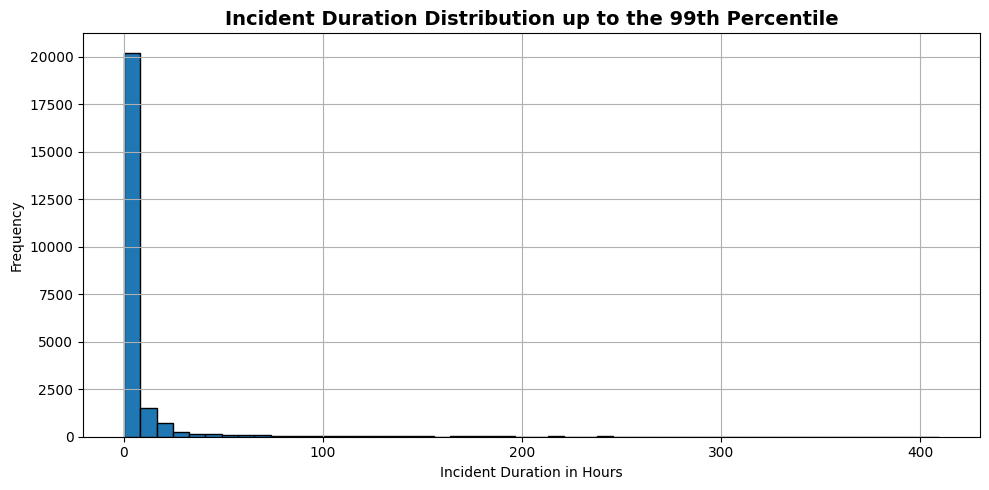

In [38]:
# ============================================================
# Step 33: Investigate Extreme Incident Duration Values
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

duration_col = "INCIDENT_DURATION_HOURS"

# ------------------------------------------------------------
# 1. Display important duration percentiles
# ------------------------------------------------------------
duration_percentiles = (
    df_features[duration_col]
    .quantile([0.00, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00])
    .rename("Duration Hours")
    .to_frame()
)

duration_percentiles.index = [
    "Minimum",
    "25%",
    "Median",
    "75%",
    "90%",
    "95%",
    "99%",
    "99.5%",
    "99.9%",
    "Maximum"
]

# ------------------------------------------------------------
# 2. Count incidents above meaningful time thresholds
# ------------------------------------------------------------
thresholds = {
    "More than 24 hours": 24,
    "More than 72 hours": 72,
    "More than 1 week": 168,
    "More than 30 days": 720,
    "More than 1 year": 8760
}

threshold_summary = []

for label, threshold in thresholds.items():
    count = (df_features[duration_col] > threshold).sum()
    percentage = (count / len(df_features)) * 100

    threshold_summary.append({
        "Threshold": label,
        "Incident Count": count,
        "Percentage (%)": round(percentage, 2)
    })

threshold_summary = pd.DataFrame(threshold_summary)

# ------------------------------------------------------------
# 3. Display the largest duration records
# ------------------------------------------------------------
review_columns = [
    col for col in [
        "REPORT_DAT",
        "START_DATE",
        "END_DATE",
        "OFFENSE",
        "METHOD",
        "SHIFT",
        duration_col,
        "DURATION_WAS_MISSING"
    ]
    if col in df_features.columns
]

largest_durations = (
    df_features[review_columns]
    .sort_values(by=duration_col, ascending=False)
    .head(15)
)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------
print("=" * 75)
print("Step 33: Extreme Incident Duration Investigation")
print("=" * 75)

print("\nDuration percentiles:")
display(duration_percentiles.round(3))

print("\nDuration threshold summary:")
display(threshold_summary)

print("\nTop 15 largest incident durations:")
display(largest_durations)

# ------------------------------------------------------------
# 5. Plot duration distribution up to the 99th percentile
# ------------------------------------------------------------
upper_99 = df_features[duration_col].quantile(0.99)

plt.figure(figsize=(10, 5))

df_features.loc[
    df_features[duration_col] <= upper_99,
    duration_col
].hist(
    bins=50,
    edgecolor="black"
)

plt.title(
    "Incident Duration Distribution up to the 99th Percentile",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Incident Duration in Hours")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 33: Extreme Incident Duration Investigation

### Description

This step investigated the distribution of `INCIDENT_DURATION_HOURS` to determine whether the unusually large duration values were genuine long-running incidents or possible date-related anomalies.

The analysis examined:

- Key duration percentiles.
- Counts of incidents exceeding selected time thresholds.
- The 15 largest incident durations.
- The duration distribution up to the 99th percentile.

### Results

The incident-duration variable is strongly right-skewed.

- Minimum duration: **0 hours**
- Median duration: **0.983 hours**
- 75th percentile: **2.600 hours**
- 90th percentile: **16.000 hours**
- 95th percentile: **45.601 hours**
- 99th percentile: **410.376 hours**
- 99.5th percentile: **793.024 hours**
- 99.9th percentile: **3,582.426 hours**
- Maximum duration: **66,289.350 hours**

Most incidents therefore lasted only a few hours, while a relatively small number had exceptionally long recorded durations.

### Duration Threshold Summary

- **1,802 incidents (7.47%)** lasted longer than 24 hours.
- **909 incidents (3.77%)** lasted longer than 72 hours.
- **508 incidents (2.11%)** lasted longer than one week.
- **143 incidents (0.59%)** lasted longer than 30 days.
- **8 incidents (0.03%)** lasted longer than one year.

### Investigation of the Largest Values

The records with the largest durations generally contained `START_DATE` values several months or years before their corresponding `END_DATE`.

For example, the maximum duration of approximately **66,289 hours** was generated from a start date in 2018 and an end date in 2025. Other extreme records similarly covered several months or years.

These durations may represent incidents for which the recorded start date describes when an offence period began rather than the exact time at which a single incident occurred. They are therefore not automatically data-entry errors, but they behave as extreme statistical values.

### Distribution Observation

The histogram shows that most observations are concentrated close to zero hours, followed by a long, sparse right tail. Even after limiting the graph to the 99th percentile, the duration distribution remains highly positively skewed.

### Key Insight

`INCIDENT_DURATION_HOURS` contains useful information, but the raw variable is dominated by a small number of very large values. Using it directly could distort summary statistics and influence models that are sensitive to scale.

The original duration should therefore be retained for reference, while a treated version such as a capped or logarithmically transformed duration may be more appropriate for modelling.

In [39]:
# ==============================================================
# Step 34: Incident Duration Feature Engineering
# ==============================================================

import numpy as np
import pandas as pd

# Create a working copy
df_features = df_features.copy()

# --------------------------------------------------------------
# 1. Preserve the original duration
# --------------------------------------------------------------
df_features["INCIDENT_DURATION_HOURS_ORIGINAL"] = (
    df_features["INCIDENT_DURATION_HOURS"]
)

# --------------------------------------------------------------
# 2. Cap extreme durations at the 99th percentile
# --------------------------------------------------------------
duration_cap = df_features["INCIDENT_DURATION_HOURS"].quantile(0.99)

df_features["INCIDENT_DURATION_HOURS_CAPPED"] = (
    df_features["INCIDENT_DURATION_HOURS"]
    .clip(lower=0, upper=duration_cap)
)

# --------------------------------------------------------------
# 3. Create a log-transformed duration
# --------------------------------------------------------------
df_features["INCIDENT_DURATION_LOG"] = np.log1p(
    df_features["INCIDENT_DURATION_HOURS_CAPPED"]
)

# --------------------------------------------------------------
# 4. Create meaningful duration categories
# --------------------------------------------------------------
duration_bins = [
    -0.01,
    1,
    3,
    6,
    12,
    24,
    72,
    168,
    np.inf
]

duration_labels = [
    "Up to 1 Hour",
    "1 to 3 Hours",
    "3 to 6 Hours",
    "6 to 12 Hours",
    "12 to 24 Hours",
    "1 to 3 Days",
    "3 Days to 1 Week",
    "More Than 1 Week"
]

df_features["INCIDENT_DURATION_CATEGORY"] = pd.cut(
    df_features["INCIDENT_DURATION_HOURS"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

# --------------------------------------------------------------
# 5. Create useful binary duration indicators
# --------------------------------------------------------------
df_features["DURATION_OVER_24_HOURS"] = (
    df_features["INCIDENT_DURATION_HOURS"] > 24
).astype(int)

df_features["DURATION_OVER_72_HOURS"] = (
    df_features["INCIDENT_DURATION_HOURS"] > 72
).astype(int)

df_features["DURATION_OVER_ONE_WEEK"] = (
    df_features["INCIDENT_DURATION_HOURS"] > 168
).astype(int)

# --------------------------------------------------------------
# Display results
# --------------------------------------------------------------
duration_features = [
    "INCIDENT_DURATION_HOURS",
    "INCIDENT_DURATION_HOURS_ORIGINAL",
    "INCIDENT_DURATION_HOURS_CAPPED",
    "INCIDENT_DURATION_LOG",
    "INCIDENT_DURATION_CATEGORY",
    "DURATION_OVER_24_HOURS",
    "DURATION_OVER_72_HOURS",
    "DURATION_OVER_ONE_WEEK"
]

print("=" * 75)
print("Step 34: Incident Duration Feature Engineering")
print("=" * 75)

print(f"Dataset shape: {df_features.shape}")
print(f"99th percentile capping value: {duration_cap:.3f} hours")
print(f"New duration features created: {len(duration_features) - 1}")

print("\nPreview:")
display(df_features[duration_features].head(10))

print("\nDuration category distribution:")
display(
    df_features["INCIDENT_DURATION_CATEGORY"]
    .value_counts(dropna=False)
    .rename("Incident Count")
    .to_frame()
)

print("\nMissing values in engineered duration features:")
display(
    df_features[duration_features]
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

Step 34: Incident Duration Feature Engineering
Dataset shape: (24114, 39)
99th percentile capping value: 410.376 hours
New duration features created: 7

Preview:


,INCIDENT_DURATION_HOURS,INCIDENT_DURATION_HOURS_ORIGINAL,INCIDENT_DURATION_HOURS_CAPPED,INCIDENT_DURATION_LOG,INCIDENT_DURATION_CATEGORY,DURATION_OVER_24_HOURS,DURATION_OVER_72_HOURS,DURATION_OVER_ONE_WEEK
0,0.500000,0.500000,0.500000,0.405465,Up to 1 Hour,0,0,0
1,0.916667,0.916667,0.916667,0.650588,Up to 1 Hour,0,0,0
2,0.133333,0.133333,0.133333,0.125163,Up to 1 Hour,0,0,0
3,19.000000,19.000000,19.000000,2.995732,12 to 24 Hours,0,0,0
4,0.100000,0.100000,0.100000,0.095310,Up to 1 Hour,0,0,0
5,6.000000,6.000000,6.000000,1.945910,3 to 6 Hours,0,0,0
6,0.166667,0.166667,0.166667,0.154151,Up to 1 Hour,0,0,0
7,5.000000,5.000000,5.000000,1.791759,3 to 6 Hours,0,0,0
8,107.000000,107.000000,107.000000,4.682131,3 Days to 1 Week,1,1,0
9,0.033333,0.033333,0.033333,0.032790,Up to 1 Hour,0,0,0



Duration category distribution:


,Incident Count
INCIDENT_DURATION_CATEGORY,
Up to 1 Hour,13460
1 to 3 Hours,5083
12 to 24 Hours,1274
6 to 12 Hours,1265
3 to 6 Hours,1230
1 to 3 Days,893
More Than 1 Week,508
3 Days to 1 Week,401



Missing values in engineered duration features:


,Missing Values
INCIDENT_DURATION_HOURS,0
INCIDENT_DURATION_HOURS_ORIGINAL,0
INCIDENT_DURATION_HOURS_CAPPED,0
INCIDENT_DURATION_LOG,0
INCIDENT_DURATION_CATEGORY,0
DURATION_OVER_24_HOURS,0
DURATION_OVER_72_HOURS,0
DURATION_OVER_ONE_WEEK,0


## Step 34: Incident Duration Feature Engineering

### Description

This step created additional features from `INCIDENT_DURATION_HOURS` to improve its usefulness for later analysis and modelling. The original duration values were preserved, while alternative versions were created to reduce the influence of extreme durations and represent incident length in more interpretable forms.

### Results

- The dataset contains **24,114 rows and 39 columns** after feature engineering.
- The **99th percentile duration value was 410.376 hours**.
- Seven new duration features were created.
- All engineered duration features contain **zero missing values**.

### Features Created

- `INCIDENT_DURATION_HOURS_ORIGINAL` preserves the original duration values.
- `INCIDENT_DURATION_HOURS_CAPPED` limits durations above **410.376 hours** to the 99th percentile threshold.
- `INCIDENT_DURATION_LOG` applies a logarithmic transformation to reduce the strong right-skewness of the duration variable.
- `INCIDENT_DURATION_CATEGORY` groups incidents into meaningful duration ranges.
- `DURATION_OVER_24_HOURS` identifies incidents lasting more than one day.
- `DURATION_OVER_72_HOURS` identifies incidents lasting more than three days.
- `DURATION_OVER_ONE_WEEK` identifies incidents lasting longer than one week.

### Duration Category Distribution

- **Up to 1 Hour:** 13,460 incidents
- **1 to 3 Hours:** 5,083 incidents
- **3 to 6 Hours:** 1,230 incidents
- **6 to 12 Hours:** 1,265 incidents
- **12 to 24 Hours:** 1,274 incidents
- **1 to 3 Days:** 893 incidents
- **3 Days to 1 Week:** 401 incidents
- **More Than 1 Week:** 508 incidents

### Observations

Most crime incidents lasted no longer than one hour, accounting for more than half of the dataset. The number of incidents generally decreased as the duration range increased.

A relatively small group of incidents lasted several days or more than one week. These long-duration observations may represent genuine prolonged incidents, delayed administrative closure, reporting differences or unusual date records.

The capped and logarithmic duration variables reduce the effect of extreme values while preserving all observations. The categorical and binary duration features also provide more interpretable representations of incident length.

### Importance

These engineered features provide several alternative ways of representing incident duration. This allows future analysis and modelling to compare the original, capped, logarithmic, categorical and binary versions without deleting potentially valid records.

In [40]:
# ================================================================
# Step 35: Spatial Location Feature Engineering
# ================================================================

import numpy as np
import pandas as pd

# Create a working copy
df_features = df_features.copy()

# ------------------------------------------------
# Confirm required coordinate columns are present
# ------------------------------------------------
required_location_cols = ["LATITUDE", "LONGITUDE"]

missing_location_cols = [
    col for col in required_location_cols
    if col not in df_features.columns
]

if missing_location_cols:
    raise KeyError(
        f"Missing required location columns: {missing_location_cols}"
    )

# ------------------------------------------------
# Calculate the geographical centre of the dataset
# ------------------------------------------------
centre_latitude = df_features["LATITUDE"].median()
centre_longitude = df_features["LONGITUDE"].median()

# ------------------------------------------------
# Create distance-from-centre features
# These are approximate coordinate distances,
# not exact road or travel distances.
# ------------------------------------------------
df_features["LATITUDE_DISTANCE_FROM_CENTRE"] = (
    df_features["LATITUDE"] - centre_latitude
).abs()

df_features["LONGITUDE_DISTANCE_FROM_CENTRE"] = (
    df_features["LONGITUDE"] - centre_longitude
).abs()

# Approximate straight-line distance using the Haversine formula
earth_radius_km = 6371

latitude_radians = np.radians(df_features["LATITUDE"])
longitude_radians = np.radians(df_features["LONGITUDE"])
centre_latitude_radians = np.radians(centre_latitude)
centre_longitude_radians = np.radians(centre_longitude)

latitude_difference = latitude_radians - centre_latitude_radians
longitude_difference = longitude_radians - centre_longitude_radians

haversine_value = (
    np.sin(latitude_difference / 2) ** 2
    + np.cos(centre_latitude_radians)
    * np.cos(latitude_radians)
    * np.sin(longitude_difference / 2) ** 2
)

df_features["DISTANCE_FROM_CENTRE_KM"] = (
    2
    * earth_radius_km
    * np.arcsin(np.sqrt(haversine_value))
)

# ------------------------------------------------
# Create broad geographical direction
# ------------------------------------------------
north_south = np.where(
    df_features["LATITUDE"] >= centre_latitude,
    "North",
    "South"
)

east_west = np.where(
    df_features["LONGITUDE"] >= centre_longitude,
    "East",
    "West"
)

df_features["GEOGRAPHIC_QUADRANT"] = (
    pd.Series(north_south, index=df_features.index)
    + "-"
    + pd.Series(east_west, index=df_features.index)
)

# ------------------------------------------------
# Create rounded coordinate grid identifiers
# ------------------------------------------------
df_features["LATITUDE_ROUNDED"] = (
    df_features["LATITUDE"].round(3)
)

df_features["LONGITUDE_ROUNDED"] = (
    df_features["LONGITUDE"].round(3)
)

df_features["LOCATION_GRID"] = (
    df_features["LATITUDE_ROUNDED"].astype(str)
    + "_"
    + df_features["LONGITUDE_ROUNDED"].astype(str)
)

# ------------------------------------------------
# Display results
# ------------------------------------------------
new_spatial_features = [
    "LATITUDE_DISTANCE_FROM_CENTRE",
    "LONGITUDE_DISTANCE_FROM_CENTRE",
    "DISTANCE_FROM_CENTRE_KM",
    "GEOGRAPHIC_QUADRANT",
    "LATITUDE_ROUNDED",
    "LONGITUDE_ROUNDED",
    "LOCATION_GRID"
]

print("=" * 75)
print("Step 35: Spatial Location Feature Engineering")
print("=" * 75)

print(f"Dataset shape: {df_features.shape}")
print(f"Dataset centre latitude: {centre_latitude:.6f}")
print(f"Dataset centre longitude: {centre_longitude:.6f}")
print(f"New spatial features created: {len(new_spatial_features)}")

print("\nNew spatial features:")
print(new_spatial_features)

print("\nPreview:")
display(
    df_features[
        [
            "LATITUDE",
            "LONGITUDE",
            "DISTANCE_FROM_CENTRE_KM",
            "GEOGRAPHIC_QUADRANT",
            "LOCATION_GRID"
        ]
    ].head(10)
)

print("\nGeographic quadrant distribution:")
display(
    df_features["GEOGRAPHIC_QUADRANT"]
    .value_counts()
    .rename("Incident Count")
    .to_frame()
)

print("\nMissing values in new spatial features:")
display(
    df_features[new_spatial_features]
    .isnull()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

Step 35: Spatial Location Feature Engineering
Dataset shape: (24114, 46)
Dataset centre latitude: 38.908618
Dataset centre longitude: -77.013648
New spatial features created: 7

New spatial features:
['LATITUDE_DISTANCE_FROM_CENTRE', 'LONGITUDE_DISTANCE_FROM_CENTRE', 'DISTANCE_FROM_CENTRE_KM', 'GEOGRAPHIC_QUADRANT', 'LATITUDE_ROUNDED', 'LONGITUDE_ROUNDED', 'LOCATION_GRID']

Preview:


,LATITUDE,LONGITUDE,DISTANCE_FROM_CENTRE_KM,GEOGRAPHIC_QUADRANT,LOCATION_GRID
0,38.924812,-77.035083,2.584959,North-West,38.925_-77.035
1,38.934751,-77.073290,5.921688,North-West,38.935_-77.073
2,38.899814,-77.028857,1.640210,South-West,38.9_-77.029
3,38.938289,-77.032730,3.689166,North-West,38.938_-77.033
4,38.919846,-76.952899,5.402150,North-East,38.92_-76.953
5,38.932606,-77.039381,3.474354,North-West,38.933_-77.039
6,38.881278,-77.019386,3.080384,South-West,38.881_-77.019
7,38.906443,-77.028085,1.272423,South-West,38.906_-77.028
8,38.922367,-76.973393,3.803579,North-East,38.922_-76.973
9,38.951873,-77.031562,5.053258,North-West,38.952_-77.032



Geographic quadrant distribution:


,Incident Count
GEOGRAPHIC_QUADRANT,
North-West,8563
South-East,8561
North-East,3496
South-West,3494



Missing values in new spatial features:


,Missing Values
LATITUDE_DISTANCE_FROM_CENTRE,0
LONGITUDE_DISTANCE_FROM_CENTRE,0
DISTANCE_FROM_CENTRE_KM,0
GEOGRAPHIC_QUADRANT,0
LATITUDE_ROUNDED,0
LONGITUDE_ROUNDED,0
LOCATION_GRID,0


## Step 35: Spatial Location Feature Engineering

### Description

This step created additional geographic features from the existing `LATITUDE` and `LONGITUDE` variables. The purpose was to represent the spatial position of each crime incident in forms that may be more useful for analysis and machine-learning models.

The median latitude and longitude of the dataset were used as the geographical centre:

- **Centre latitude:** `38.908618`
- **Centre longitude:** `-77.013648`

The dataset retained all **24,114 records**, while its number of columns increased to **46** after creating seven new spatial features.

### Spatial Features Created

The following features were generated:

- `LATITUDE_DISTANCE_FROM_CENTRE` — absolute latitude difference between each incident and the dataset centre.
- `LONGITUDE_DISTANCE_FROM_CENTRE` — absolute longitude difference between each incident and the dataset centre.
- `DISTANCE_FROM_CENTRE_KM` — approximate straight-line distance from the dataset centre, calculated in kilometres using the Haversine formula.
- `GEOGRAPHIC_QUADRANT` — classifies incidents as North-East, North-West, South-East or South-West relative to the dataset centre.
- `LATITUDE_ROUNDED` — latitude rounded to three decimal places.
- `LONGITUDE_ROUNDED` — longitude rounded to three decimal places.
- `LOCATION_GRID` — a combined rounded latitude and longitude identifier representing a small geographic area.

### Geographic Quadrant Distribution

The incident distribution across the four geographic quadrants was:

- **North-West:** 8,563 incidents
- **South-East:** 8,561 incidents
- **North-East:** 3,496 incidents
- **South-West:** 3,494 incidents

The North-West and South-East quadrants contain the highest numbers of incidents and are almost equally represented. The North-East and South-West quadrants also have very similar counts but contain substantially fewer incidents.

### Observations

The quadrant results indicate that incidents are not distributed evenly around the geographical centre. A larger proportion of incidents occur along the North-West and South-East directions.

The `DISTANCE_FROM_CENTRE_KM` feature provides a more interpretable measurement than raw latitude and longitude differences because it expresses spatial distance in kilometres.

The rounded coordinate features and `LOCATION_GRID` group nearby observations into smaller spatial areas. These may help identify local incident concentration patterns without relying on exact coordinates.

The quadrant and location-grid features provide categorical representations of geographical position, while the distance features provide continuous numerical measurements.

### Data Quality Check

All seven engineered spatial features contain **zero missing values**. This confirms that the spatial feature-engineering process was completed successfully for every observation in the dataset.

### Importance

These engineered features provide alternative representations of incident location while avoiding the previously removed redundant coordinate variables `X`, `Y`, `XBLOCK` and `YBLOCK`.

They may help models identify:

- differences in crime patterns across broad geographical directions;
- whether incidents closer to or farther from the dataset centre behave differently;
- local geographic concentrations represented by the location grids; and
- nonlinear spatial relationships that may not be captured effectively by raw latitude and longitude alone.

In [41]:
# ================================================================
# Step 36: Contextual and Temporal Interaction Feature Engineering
# ================================================================

import pandas as pd
import numpy as np

# Create a working copy
df_features = df_features.copy()

# ------------------------------------------------
# Function for grouping hours into time periods
# ------------------------------------------------
def classify_time_period(hour):
    if pd.isna(hour):
        return "Unknown"
    elif 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"


# ------------------------------------------------
# Function for grouping months into seasons
# ------------------------------------------------
def classify_season(month):
    if pd.isna(month):
        return "Unknown"
    elif month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


# Store the names of newly created features
new_context_features = []


# ------------------------------------------------
# 1. Report time-period feature
# ------------------------------------------------
if "REPORT_HOUR" in df_features.columns:
    df_features["REPORT_TIME_PERIOD"] = (
        df_features["REPORT_HOUR"]
        .apply(classify_time_period)
        .astype("string")
    )
    new_context_features.append("REPORT_TIME_PERIOD")


# ------------------------------------------------
# 2. Start time-period feature
# ------------------------------------------------
if "START_HOUR" in df_features.columns:
    df_features["START_TIME_PERIOD"] = (
        df_features["START_HOUR"]
        .apply(classify_time_period)
        .astype("string")
    )
    new_context_features.append("START_TIME_PERIOD")


# ------------------------------------------------
# 3. Report season
# ------------------------------------------------
if "REPORT_MONTH" in df_features.columns:
    df_features["REPORT_SEASON"] = (
        df_features["REPORT_MONTH"]
        .apply(classify_season)
        .astype("string")
    )
    new_context_features.append("REPORT_SEASON")


# ------------------------------------------------
# 4. Start season
# ------------------------------------------------
if "START_MONTH" in df_features.columns:
    df_features["START_SEASON"] = (
        df_features["START_MONTH"]
        .apply(classify_season)
        .astype("string")
    )
    new_context_features.append("START_SEASON")


# ------------------------------------------------
# 5. Offence and method interaction
# ------------------------------------------------
if {"OFFENSE", "METHOD"}.issubset(df_features.columns):
    df_features["OFFENSE_METHOD"] = (
        df_features["OFFENSE"].astype("string").fillna("Unknown")
        + " | "
        + df_features["METHOD"].astype("string").fillna("Unknown")
    )
    new_context_features.append("OFFENSE_METHOD")


# ------------------------------------------------
# 6. Offence and shift interaction
# ------------------------------------------------
if {"OFFENSE", "SHIFT"}.issubset(df_features.columns):
    df_features["OFFENSE_SHIFT"] = (
        df_features["OFFENSE"].astype("string").fillna("Unknown")
        + " | "
        + df_features["SHIFT"].astype("string").fillna("Unknown")
    )
    new_context_features.append("OFFENSE_SHIFT")


# ------------------------------------------------
# 7. Ward and shift interaction
# ------------------------------------------------
if {"WARD", "SHIFT"}.issubset(df_features.columns):
    df_features["WARD_SHIFT"] = (
        df_features["WARD"].astype("string").fillna("Unknown")
        + " | "
        + df_features["SHIFT"].astype("string").fillna("Unknown")
    )
    new_context_features.append("WARD_SHIFT")


# ------------------------------------------------
# 8. District and shift interaction
# ------------------------------------------------
if {"DISTRICT", "SHIFT"}.issubset(df_features.columns):
    df_features["DISTRICT_SHIFT"] = (
        df_features["DISTRICT"].astype("string").fillna("Unknown")
        + " | "
        + df_features["SHIFT"].astype("string").fillna("Unknown")
    )
    new_context_features.append("DISTRICT_SHIFT")


# ------------------------------------------------
# 9. Weekend and shift interaction
# ------------------------------------------------
if {"REPORT_IS_WEEKEND", "SHIFT"}.issubset(df_features.columns):
    weekend_label = df_features["REPORT_IS_WEEKEND"].map(
        {0: "Weekday", 1: "Weekend"}
    ).fillna("Unknown")

    df_features["WEEKEND_SHIFT"] = (
        weekend_label.astype("string")
        + " | "
        + df_features["SHIFT"].astype("string").fillna("Unknown")
    )
    new_context_features.append("WEEKEND_SHIFT")


# ------------------------------------------------
# Display results
# ------------------------------------------------
print("=" * 80)
print("Step 36: Contextual and Temporal Interaction Feature Engineering")
print("=" * 80)

print(f"Dataset shape: {df_features.shape}")
print(f"New contextual features created: {len(new_context_features)}")

print("\nNew contextual features:")
print(new_context_features)

print("\nPreview:")
display(df_features[new_context_features].head(10))

print("\nUnique categories in each new feature:")
category_summary = pd.DataFrame({
    "Feature": new_context_features,
    "Unique Categories": [
        df_features[col].nunique(dropna=False)
        for col in new_context_features
    ],
    "Missing Values": [
        df_features[col].isna().sum()
        for col in new_context_features
    ]
})

display(category_summary)

Step 36: Contextual and Temporal Interaction Feature Engineering
Dataset shape: (24114, 55)
New contextual features created: 9

New contextual features:
['REPORT_TIME_PERIOD', 'START_TIME_PERIOD', 'REPORT_SEASON', 'START_SEASON', 'OFFENSE_METHOD', 'OFFENSE_SHIFT', 'WARD_SHIFT', 'DISTRICT_SHIFT', 'WEEKEND_SHIFT']

Preview:


,REPORT_TIME_PERIOD,START_TIME_PERIOD,REPORT_SEASON,START_SEASON,OFFENSE_METHOD,OFFENSE_SHIFT,WARD_SHIFT,DISTRICT_SHIFT,WEEKEND_SHIFT
0,Evening,Afternoon,Summer,Summer,THEFT F/AUTO | OTHERS,THEFT F/AUTO | EVENING,1 | EVENING,3.0 | EVENING,Weekday | EVENING
1,Night,Night,Spring,Spring,THEFT/OTHER | OTHERS,THEFT/OTHER | EVENING,3 | EVENING,2.0 | EVENING,Weekend | EVENING
2,Morning,Morning,Spring,Spring,THEFT/OTHER | OTHERS,THEFT/OTHER | MIDNIGHT,2 | MIDNIGHT,2.0 | MIDNIGHT,Weekday | MIDNIGHT
3,Afternoon,Night,Summer,Summer,THEFT/OTHER | OTHERS,THEFT/OTHER | DAY,4 | DAY,4.0 | DAY,Weekday | DAY
4,Evening,Evening,Spring,Spring,THEFT/OTHER | OTHERS,THEFT/OTHER | EVENING,5 | EVENING,5.0 | EVENING,Weekday | EVENING
5,Afternoon,Morning,Autumn,Autumn,THEFT F/AUTO | OTHERS,THEFT F/AUTO | DAY,1 | DAY,3.0 | DAY,Weekend | DAY
6,Afternoon,Afternoon,Autumn,Autumn,THEFT F/AUTO | OTHERS,THEFT F/AUTO | DAY,6 | DAY,1.0 | DAY,Weekday | DAY
7,Morning,Evening,Spring,Summer,THEFT F/AUTO | OTHERS,THEFT F/AUTO | MIDNIGHT,2 | MIDNIGHT,3.0 | MIDNIGHT,Weekday | MIDNIGHT
8,Afternoon,Afternoon,Spring,Spring,THEFT/OTHER | OTHERS,THEFT/OTHER | DAY,5 | DAY,5.0 | DAY,Weekday | DAY
9,Evening,Evening,Summer,Spring,THEFT/OTHER | OTHERS,THEFT/OTHER | EVENING,4 | EVENING,4.0 | EVENING,Weekday | EVENING



Unique categories in each new feature:


,Feature,Unique Categories,Missing Values
0,REPORT_TIME_PERIOD,4,0
1,START_TIME_PERIOD,4,0
2,REPORT_SEASON,4,0
3,START_SEASON,4,0
4,OFFENSE_METHOD,24,0
5,OFFENSE_SHIFT,25,0
6,WARD_SHIFT,24,0
7,DISTRICT_SHIFT,21,0
8,WEEKEND_SHIFT,6,0


## Step 36: Contextual and Temporal Interaction Feature Engineering

### Description

This step created additional contextual and interaction features from the existing temporal, offence, method, shift and location variables. These features provide more meaningful combinations that may help a machine-learning model identify patterns that are not fully represented by the original variables individually.

The feature-engineered dataset now contains **24,114 rows and 55 columns**.

### New Features Created

A total of **9 contextual and interaction features** were created:

- `REPORT_TIME_PERIOD`
- `START_TIME_PERIOD`
- `REPORT_SEASON`
- `START_SEASON`
- `OFFENSE_METHOD`
- `OFFENSE_SHIFT`
- `WARD_SHIFT`
- `DISTRICT_SHIFT`
- `WEEKEND_SHIFT`

### Results and Observations

The `REPORT_TIME_PERIOD` and `START_TIME_PERIOD` variables grouped the original hourly values into four understandable periods:

- Morning
- Afternoon
- Evening
- Night

The `REPORT_SEASON` and `START_SEASON` variables grouped the months into four seasons:

- Winter
- Spring
- Summer
- Autumn

The interaction variables combined related categorical information:

- `OFFENSE_METHOD` combines the offence type and method used.
- `OFFENSE_SHIFT` combines the offence type and reporting shift.
- `WARD_SHIFT` combines the ward and shift.
- `DISTRICT_SHIFT` combines the police district and shift.
- `WEEKEND_SHIFT` distinguishes weekday and weekend incidents across the different shifts.

### Unique Category Summary

- `REPORT_TIME_PERIOD`: 4 categories
- `START_TIME_PERIOD`: 4 categories
- `REPORT_SEASON`: 4 categories
- `START_SEASON`: 4 categories
- `OFFENSE_METHOD`: 24 categories
- `OFFENSE_SHIFT`: 25 categories
- `WARD_SHIFT`: 24 categories
- `DISTRICT_SHIFT`: 21 categories
- `WEEKEND_SHIFT`: 6 categories

All nine engineered features contain **zero missing values**.

### Key Insight

The new interaction features allow the dataset to represent combined crime circumstances, such as a particular offence occurring during a specific shift, in a particular ward or under a particular method.

These combinations may reveal relationships that would be difficult for a model to identify when the original variables are considered separately. However, the interaction variables should later be evaluated for usefulness because some may contain overlapping information with their original component variables.

In [42]:
# ============================================================
# Step 37: Prepare Leakage-Controlled Modelling Dataset
# ============================================================

import pandas as pd

# Create a separate copy for modelling
df_model = df_features.copy()

# ------------------------------------------------------------
# Define target variable
# ------------------------------------------------------------
target_column = "OFFENSE"

# ------------------------------------------------------------
# Columns that should not be used for prediction
# ------------------------------------------------------------
columns_to_remove = [
    # Target-derived features
    "OFFENSE_METHOD",
    "OFFENSE_SHIFT",

    # Raw target column will be separated below
    target_column,

    # Identifiers
    "CCN",

    # Raw date columns
    "REPORT_DAT",
    "START_DATE",
    "END_DATE",

    # Future-information and duration-derived features
    "INCIDENT_DURATION_HOURS",
    "INCIDENT_DURATION_HOURS_ORIGINAL",
    "INCIDENT_DURATION_HOURS_CAPPED",
    "INCIDENT_DURATION_LOG",
    "INCIDENT_DURATION_CATEGORY",
    "DURATION_OVER_24_HOURS",
    "DURATION_OVER_72_HOURS",
    "DURATION_OVER_ONE_WEEK",
    "DURATION_WAS_MISSING"
]

# Keep only columns that actually exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in df_model.columns
]

# ------------------------------------------------------------
# Separate predictors and target
# ------------------------------------------------------------
X = df_model.drop(columns=columns_to_remove).copy()
y = df_model[target_column].copy()

# ------------------------------------------------------------
# Remove any remaining duplicate rows
# ------------------------------------------------------------
duplicate_rows = X.duplicated().sum()

if duplicate_rows > 0:
    keep_index = ~X.duplicated()
    X = X.loc[keep_index].copy()
    y = y.loc[keep_index].copy()

# Reset indexes
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# ------------------------------------------------------------
# Dataset quality checks
# ------------------------------------------------------------
missing_predictors = int(X.isna().sum().sum())
missing_target = int(y.isna().sum())

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("=" * 80)
print("Step 37: Leakage-Controlled Modelling Dataset")
print("=" * 80)

print(f"Target variable              : {target_column}")
print(f"Predictor dataset shape      : {X.shape}")
print(f"Target shape                 : {y.shape}")
print(f"Duplicate predictor rows     : {duplicate_rows}")
print(f"Missing predictor values     : {missing_predictors}")
print(f"Missing target values        : {missing_target}")
print(f"Numerical features           : {len(numerical_features)}")
print(f"Categorical features         : {len(categorical_features)}")
print(f"Target classes               : {y.nunique()}")

print("\nColumns removed:")
print(columns_to_remove)

print("\nRemaining predictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
display(
    y.value_counts()
     .rename("Incident Count")
     .to_frame()
)

print("\nTarget distribution percentage:")
display(
    y.value_counts(normalize=True)
     .mul(100)
     .round(2)
     .rename("Percentage (%)")
     .to_frame()
)

Step 37: Leakage-Controlled Modelling Dataset
Target variable              : OFFENSE
Predictor dataset shape      : (24079, 39)
Target shape                 : (24079,)
Duplicate predictor rows     : 35
Missing predictor values     : 0
Missing target values        : 0
Numerical features           : 17
Categorical features         : 22
Target classes               : 9

Columns removed:
['OFFENSE_METHOD', 'OFFENSE_SHIFT', 'OFFENSE', 'CCN', 'REPORT_DAT', 'START_DATE', 'END_DATE', 'INCIDENT_DURATION_HOURS', 'INCIDENT_DURATION_HOURS_ORIGINAL', 'INCIDENT_DURATION_HOURS_CAPPED', 'INCIDENT_DURATION_LOG', 'INCIDENT_DURATION_CATEGORY', 'DURATION_OVER_24_HOURS', 'DURATION_OVER_72_HOURS', 'DURATION_OVER_ONE_WEEK', 'DURATION_WAS_MISSING']

Remaining predictor columns:
['BLOCK', 'METHOD', 'SHIFT', 'WARD', 'ANC', 'DISTRICT', 'PSA', 'NEIGHBORHOOD_CLUSTER', 'BLOCK_GROUP', 'CENSUS_TRACT', 'VOTING_PRECINCT', 'LATITUDE', 'LONGITUDE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DAY_OF_WEEK', 'REPOR

,Incident Count
OFFENSE,
THEFT/OTHER,11593
THEFT F/AUTO,5350
MOTOR VEHICLE THEFT,3930
ROBBERY,1320
ASSAULT W/DANGEROUS WEAPON,932
BURGLARY,722
HOMICIDE,124
SEX ABUSE,104
ARSON,4



Target distribution percentage:


,Percentage (%)
OFFENSE,
THEFT/OTHER,48.15
THEFT F/AUTO,22.22
MOTOR VEHICLE THEFT,16.32
ROBBERY,5.48
ASSAULT W/DANGEROUS WEAPON,3.87
BURGLARY,3.00
HOMICIDE,0.51
SEX ABUSE,0.43
ARSON,0.02


# Step 37: Leakage-Controlled Modelling Dataset

## Description

This step prepares the final predictor dataset and target variable for machine learning.

The target variable is `OFFENSE`, which contains nine crime categories. Variables that could directly reveal the target, introduce data leakage, duplicate existing information, or be unavailable when making a prediction were removed from the predictor dataset.

The remaining dataset contains:

- **24,079 observations**
- **39 predictor features**
- **17 numerical features**
- **22 categorical features**
- **9 target classes**
- **No missing predictor or target values**

A total of **35 duplicate predictor rows** were identified. These records may contain identical predictor values while having different or repeated target outcomes, so they should be assessed carefully rather than removed automatically.

## Target Distribution

The target variable is noticeably imbalanced:

| Offense Category | Incident Count | Percentage |
|---|---:|---:|
| Theft/Other | 11,593 | 48.15% |
| Theft F/Auto | 5,350 | 22.22% |
| Motor Vehicle Theft | 3,930 | 16.32% |
| Robbery | 1,320 | 5.48% |
| Assault W/Dangerous Weapon | 932 | 3.87% |
| Burglary | 722 | 3.00% |
| Homicide | 124 | 0.51% |
| Sex Abuse | 104 | 0.43% |
| Arson | 4 | 0.02% |

## Observations

- `THEFT/OTHER` is the dominant class, representing almost half of all incidents.
- The three theft-related categories together account for most observations in the dataset.
- `HOMICIDE`, `SEX ABUSE`, and especially `ARSON` are severely underrepresented.
- `ARSON` contains only four observations, which is too small for a model to learn a reliable general pattern.
- Standard accuracy alone would provide a misleading evaluation because a model could perform well by favouring the majority classes.
- Stratified data splitting will be required to preserve the class distribution across the training, validation, and test datasets.
- One-hot encoding has not yet been applied because categorical preprocessing should be fitted only on the training data to prevent data leakage.

## Importance

Creating a leakage-controlled dataset ensures that model performance reflects genuine predictive ability rather than information unintentionally derived from the target.

Because the target distribution is highly imbalanced, model assessment should prioritise metrics such as:

- Macro F1-score
- Balanced accuracy
- Per-class precision and recall
- Confusion matrix
- Classification report

The extremely small `ARSON` class will require a specific modelling decision, such as combining it with another suitable category, excluding it from the first modelling version, or retaining it while clearly acknowledging that reliable prediction will not be possible with only four examples.

In [43]:
# ================================================================
# Step 38: Handle Extremely Rare Target Class
# ================================================================

import pandas as pd

# Create safe copies of predictors and target
X_model = X.copy()
y_model = y.copy()

# Display target distribution before treatment
print("=" * 75)
print("Step 38: Extremely Rare Target Class Handling")
print("=" * 75)

print("\nTarget distribution before treatment:")
display(
    y_model.value_counts()
    .rename("Incident Count")
    .to_frame()
)

# Identify classes containing fewer than 20 observations
minimum_class_size = 20

rare_classes = (
    y_model.value_counts()
    .loc[lambda counts: counts < minimum_class_size]
    .index
    .tolist()
)

print(f"\nMinimum required class size: {minimum_class_size}")
print(f"Classes below the threshold: {rare_classes}")

# Keep only classes meeting the minimum sample requirement
keep_mask = ~y_model.isin(rare_classes)

X_model = X_model.loc[keep_mask].copy()
y_model = y_model.loc[keep_mask].copy()

# Reset indices so predictors and target remain aligned
X_model.reset_index(drop=True, inplace=True)
y_model.reset_index(drop=True, inplace=True)

# Quality checks
print("\nDataset after rare-class treatment:")
print(f"Predictor shape: {X_model.shape}")
print(f"Target shape: {y_model.shape}")
print(f"Remaining target classes: {y_model.nunique()}")
print(f"Missing predictor values: {X_model.isna().sum().sum()}")
print(f"Missing target values: {y_model.isna().sum()}")
print(f"Index alignment confirmed: {X_model.index.equals(y_model.index)}")

print("\nTarget distribution after treatment:")
target_distribution = pd.DataFrame({
    "Incident Count": y_model.value_counts(),
    "Percentage (%)": (
        y_model.value_counts(normalize=True) * 100
    ).round(2)
})

display(target_distribution)

Step 38: Extremely Rare Target Class Handling

Target distribution before treatment:


,Incident Count
OFFENSE,
THEFT/OTHER,11593
THEFT F/AUTO,5350
MOTOR VEHICLE THEFT,3930
ROBBERY,1320
ASSAULT W/DANGEROUS WEAPON,932
BURGLARY,722
HOMICIDE,124
SEX ABUSE,104
ARSON,4



Minimum required class size: 20
Classes below the threshold: ['ARSON']

Dataset after rare-class treatment:
Predictor shape: (24075, 39)
Target shape: (24075,)
Remaining target classes: 8
Missing predictor values: 0
Missing target values: 0
Index alignment confirmed: True

Target distribution after treatment:


,Incident Count,Percentage (%)
OFFENSE,,
THEFT/OTHER,11593,48.15
THEFT F/AUTO,5350,22.22
MOTOR VEHICLE THEFT,3930,16.32
ROBBERY,1320,5.48
ASSAULT W/DANGEROUS WEAPON,932,3.87
BURGLARY,722,3.00
HOMICIDE,124,0.52
SEX ABUSE,104,0.43


## Step 38: Handling the Extremely Rare Target Class

### Description

This step identifies target classes with fewer than 20 observations and removes them from the modelling dataset.

Extremely small classes cannot be divided reliably across training, validation and test datasets. They may also cause unstable model evaluation because the model receives too few examples from which to learn meaningful patterns.

### Results

Before treatment, the target variable contained nine offence classes. `ARSON` was identified as the only class below the minimum threshold because it contained just 4 incidents.

After excluding `ARSON`:

- Predictor dataset shape: **24,075 rows × 39 features**
- Target shape: **24,075 observations**
- Remaining target classes: **8**
- Missing predictor values: **0**
- Missing target values: **0**
- Predictor and target indices remained correctly aligned

### Remaining Target Distribution

- **THEFT/OTHER:** 11,593 incidents — 48.15%
- **THEFT F/AUTO:** 5,350 incidents — 22.22%
- **MOTOR VEHICLE THEFT:** 3,930 incidents — 16.32%
- **ROBBERY:** 1,320 incidents — 5.48%
- **ASSAULT W/DANGEROUS WEAPON:** 932 incidents — 3.87%
- **BURGLARY:** 722 incidents — 3.00%
- **HOMICIDE:** 124 incidents — 0.52%
- **SEX ABUSE:** 104 incidents — 0.43%

### Observations

The rare-class treatment removed only 4 records, so almost the entire dataset was preserved.

The target remains substantially imbalanced. `THEFT/OTHER` represents nearly half of all incidents, while `HOMICIDE` and `SEX ABUSE` each account for less than 1%.

This imbalance must be considered during model training and evaluation. Overall accuracy alone may be misleading, so class-sensitive measures such as macro F1-score, balanced accuracy, class-level recall and the confusion matrix will be important.

### Importance

Removing the extremely rare `ARSON` class makes stratified data splitting more reliable and prevents unstable evaluation results caused by having too few observations.

The cleaned predictors and target are now properly aligned, contain no missing values and are suitable for constructing the training, validation and test datasets.

In [44]:
# ================================================================
# Step 39: Train, Validation and Test Split
# ================================================================

from sklearn.model_selection import train_test_split
import pandas as pd

print("=" * 75)
print("Step 39: Train, Validation and Test Split")
print("=" * 75)

# ---------------------------------------------------------
# First split:
# 80% Training
# 20% Temporary (Validation + Test)
# ---------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

# ---------------------------------------------------------
# Second split:
# Temporary dataset becomes
# 10% Validation
# 10% Test
# ---------------------------------------------------------

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset Shapes")
print("-" * 40)
print(f"Training predictors   : {X_train.shape}")
print(f"Validation predictors : {X_valid.shape}")
print(f"Testing predictors    : {X_test.shape}")

print()

print(f"Training target       : {y_train.shape}")
print(f"Validation target     : {y_valid.shape}")
print(f"Testing target        : {y_test.shape}")

print("\nPercentage Split")
print("-" * 40)

total = len(X_model)

print(f"Training   : {len(X_train)/total:.2%}")
print(f"Validation : {len(X_valid)/total:.2%}")
print(f"Testing    : {len(X_test)/total:.2%}")

print("\nTarget Distribution")

distribution = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True),
    "Validation": y_valid.value_counts(normalize=True),
    "Testing": y_test.value_counts(normalize=True)
}).fillna(0)

display((distribution * 100).round(2))

Step 39: Train, Validation and Test Split

Dataset Shapes
----------------------------------------
Training predictors   : (19260, 39)
Validation predictors : (2407, 39)
Testing predictors    : (2408, 39)

Training target       : (19260,)
Validation target     : (2407,)
Testing target        : (2408,)

Percentage Split
----------------------------------------
Training   : 80.00%
Validation : 10.00%
Testing    : 10.00%

Target Distribution


,Training,Validation,Testing
OFFENSE,,,
THEFT/OTHER,48.15,48.15,48.17
THEFT F/AUTO,22.22,22.23,22.22
MOTOR VEHICLE THEFT,16.32,16.33,16.32
ROBBERY,5.48,5.48,5.48
ASSAULT W/DANGEROUS WEAPON,3.87,3.86,3.86
BURGLARY,3.00,2.99,2.99
HOMICIDE,0.51,0.50,0.54
SEX ABUSE,0.43,0.46,0.42


## Step 39: Train, Validation and Test Split

### Description

This step partitions the leakage-controlled modelling dataset into independent training, validation and testing subsets.

The split is performed before any preprocessing, such as one-hot encoding or feature scaling, to prevent data leakage. Stratified sampling is used to preserve the original class distribution of the target variable across all three datasets despite the existing class imbalance.

### Results

The modelling dataset was successfully divided into:

- **Training set:** 19,260 observations (80%)
- **Validation set:** 2,407 observations (10%)
- **Testing set:** 2,408 observations (10%)

Each subset contains the same 39 predictor features, while the target variable remains correctly aligned with its corresponding predictors.

### Target Distribution

The offence class proportions remain nearly identical across all three datasets:

| Offence | Training | Validation | Testing |
|---------|----------:|-----------:|---------:|
| THEFT/OTHER | 48.15% | 48.15% | 48.17% |
| THEFT F/AUTO | 22.22% | 22.23% | 22.22% |
| MOTOR VEHICLE THEFT | 16.32% | 16.33% | 16.32% |
| ROBBERY | 5.48% | 5.48% | 5.48% |
| ASSAULT W/DANGEROUS WEAPON | 3.87% | 3.86% | 3.86% |
| BURGLARY | 3.00% | 2.99% | 2.99% |
| HOMICIDE | 0.51% | 0.50% | 0.54% |
| SEX ABUSE | 0.43% | 0.46% | 0.42% |

### Observations

The stratified splitting process successfully preserved the target class distribution across the training, validation and testing datasets. The percentage differences between subsets are negligible, indicating that each dataset is a representative sample of the original modelling data.

The training dataset will be used to fit preprocessing transformations and machine learning models, while the validation dataset will support model selection and hyperparameter tuning. The testing dataset will remain untouched until the final evaluation stage to provide an unbiased assessment of model performance.

### Importance

Creating separate training, validation and testing datasets before preprocessing is a critical machine learning best practice. It ensures that all preprocessing operations, including one-hot encoding and feature scaling, are learned exclusively from the training data, preventing information leakage and producing reliable estimates of real-world model performance.

In [45]:
# ================================================================
# Step 40: Leakage-Controlled Preprocessing Pipeline
# ================================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

print("=" * 75)
print("Step 40: Leakage-Controlled Preprocessing Pipeline")
print("=" * 75)

# ---------------------------------------------------------
# Identify feature types
# ---------------------------------------------------------

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nFeature Summary")
print("-" * 40)
print(f"Numerical features   : {len(numerical_features)}")
print(f"Categorical features : {len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# ---------------------------------------------------------
# Numerical preprocessing
# ---------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# ---------------------------------------------------------
# Categorical preprocessing
# ---------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ---------------------------------------------------------
# Combined preprocessing pipeline
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline successfully created.")
print("No transformation has been fitted yet.")
print("The pipeline will be fitted using ONLY the training dataset.")

Step 40: Leakage-Controlled Preprocessing Pipeline

Feature Summary
----------------------------------------
Numerical features   : 17
Categorical features : 8

Numerical Features:
['LATITUDE', 'LONGITUDE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_HOUR', 'REPORT_IS_WEEKEND', 'START_YEAR', 'START_MONTH', 'START_DAY', 'START_HOUR', 'START_IS_WEEKEND', 'LATITUDE_DISTANCE_FROM_CENTRE', 'LONGITUDE_DISTANCE_FROM_CENTRE', 'DISTANCE_FROM_CENTRE_KM', 'LATITUDE_ROUNDED', 'LONGITUDE_ROUNDED']

Categorical Features:
['BLOCK', 'METHOD', 'SHIFT', 'NEIGHBORHOOD_CLUSTER', 'REPORT_DAY_OF_WEEK', 'START_DAY_OF_WEEK', 'GEOGRAPHIC_QUADRANT', 'LOCATION_GRID']

Preprocessing pipeline successfully created.
No transformation has been fitted yet.
The pipeline will be fitted using ONLY the training dataset.


C:\Users\mapfi\AppData\Local\Temp\ipykernel_21464\2657410795.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


## Step 40: Leakage-Controlled Preprocessing Pipeline

### Description

This step constructs the preprocessing pipeline that will be used before training the machine learning models.

The preprocessing workflow separates numerical and categorical variables automatically. Numerical features are assigned to a standardisation pipeline using `StandardScaler`, while categorical features are assigned to a `OneHotEncoder` configured to ignore unseen categories during prediction.

A `ColumnTransformer` combines these preprocessing steps into a single leakage-controlled pipeline.

### Results

The preprocessing pipeline was successfully created.

Feature summary:

- Numerical features: **17**
- Categorical features: **8**
- Total predictor features: **25**

The numerical and categorical feature lists were correctly identified from the training dataset.

The preprocessing pipeline has been defined but has **not yet been fitted**.

### Observations

No preprocessing transformations have been applied at this stage. The pipeline only stores the instructions describing how each feature type should be processed.

Separating numerical and categorical variables ensures that each feature receives the appropriate transformation before model training.

### Importance

Building the preprocessing pipeline before fitting any model is a machine learning best practice. By fitting the pipeline only on the training dataset, information from the validation and testing datasets is prevented from influencing the learned transformations.

This leakage-controlled approach produces more reliable model evaluation and ensures that the same preprocessing steps can be reused consistently during deployment.

In [46]:
# ============================================================
# Step 41: Fit and Apply the Preprocessing Pipeline
# ============================================================

import numpy as np
from scipy import sparse

# ------------------------------------------------------------
# Fit the preprocessing pipeline only on the training data
# ------------------------------------------------------------
X_train_processed = preprocessor.fit_transform(X_train)

# ------------------------------------------------------------
# Apply the fitted pipeline to validation and testing data
# ------------------------------------------------------------
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

# ------------------------------------------------------------
# Retrieve the transformed feature names
# ------------------------------------------------------------
processed_feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Check for missing or infinite values
# ------------------------------------------------------------
def check_processed_data(data, dataset_name):
    if sparse.issparse(data):
        values = data.data
        data_type = "Sparse matrix"
    else:
        values = np.asarray(data)
        data_type = "Dense array"

    missing_values = np.isnan(values).sum()
    infinite_values = np.isinf(values).sum()

    return {
        "Dataset": dataset_name,
        "Structure": data_type,
        "Rows": data.shape[0],
        "Processed Features": data.shape[1],
        "Missing Values": missing_values,
        "Infinite Values": infinite_values
    }


processing_summary = [
    check_processed_data(X_train_processed, "Training"),
    check_processed_data(X_valid_processed, "Validation"),
    check_processed_data(X_test_processed, "Testing")
]

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("=" * 75)
print("Step 41: Fit and Apply the Preprocessing Pipeline")
print("=" * 75)

print("\nProcessed dataset shapes")
print("-" * 45)
print(f"Training data   : {X_train_processed.shape}")
print(f"Validation data : {X_valid_processed.shape}")
print(f"Testing data    : {X_test_processed.shape}")

print(f"\nOriginal predictor features : {X_train.shape[1]}")
print(f"Processed model features    : {len(processed_feature_names)}")

print("\nProcessing summary:")
display(pd.DataFrame(processing_summary))

print("\nFirst 20 processed feature names:")
display(
    pd.DataFrame({
        "Feature Number": range(1, min(21, len(processed_feature_names) + 1)),
        "Processed Feature": processed_feature_names[:20]
    })
)

print("\nPreprocessing completed successfully.")
print("The pipeline was fitted only on the training dataset.")
print("Validation and testing datasets were transformed using the fitted pipeline.")

Step 41: Fit and Apply the Preprocessing Pipeline

Processed dataset shapes
---------------------------------------------
Training data   : (19260, 10610)
Validation data : (2407, 10610)
Testing data    : (2408, 10610)

Original predictor features : 39
Processed model features    : 10610

Processing summary:


,Dataset,Structure,Rows,Processed Features,Missing Values,Infinite Values
0,Training,Dense array,19260,10610,0,0
1,Validation,Dense array,2407,10610,0,0
2,Testing,Dense array,2408,10610,0,0



First 20 processed feature names:


,Feature Number,Processed Feature
0,1,num__LATITUDE
1,2,num__LONGITUDE
2,3,num__REPORT_YEAR
3,4,num__REPORT_MONTH
4,5,num__REPORT_DAY
5,6,num__REPORT_HOUR
6,7,num__REPORT_IS_WEEKEND
7,8,num__START_YEAR
8,9,num__START_MONTH
9,10,num__START_DAY



Preprocessing completed successfully.
The pipeline was fitted only on the training dataset.
Validation and testing datasets were transformed using the fitted pipeline.


### Step 41: Fit and Apply the Preprocessing Pipeline

The preprocessing pipeline was successfully fitted using **only the training dataset** to prevent data leakage. The fitted pipeline was then applied to the validation and testing datasets without being refitted, ensuring that all datasets were processed consistently using identical scaling and encoding rules.

The preprocessing increased the predictor space from **39 original features** to **10,610 processed features**, primarily due to One-Hot Encoding of high-cardinality categorical variables such as **BLOCK**, while numerical features were standardized. The processed datasets contain no missing values or infinite values, confirming that the preprocessing pipeline executed correctly.

The first processed features show the expected naming convention, with numerical variables prefixed by **`num__`** and categorical variables prefixed by **`cat__`**, making the transformed feature space fully traceable and suitable for machine learning model training.

### Step 42: Baseline Model Training – Logistic Regression

In this step, a Logistic Regression classifier is trained as the baseline model using the leakage-controlled training dataset. Logistic Regression is a widely used linear classification algorithm that provides a simple yet effective benchmark for evaluating the performance of more advanced machine learning models.

The model is trained exclusively on the processed training data and evaluated on the validation dataset. Performance is assessed using Accuracy, Balanced Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and a detailed Classification Report. These evaluation metrics establish a baseline against which subsequent models will be compared.

Step 42: Logistic Regression Validation Performance


,Metric,Score
0,Accuracy,0.559618
1,Balanced Accuracy,0.298541
2,Macro Precision,0.384191
3,Macro Recall,0.298541
4,Macro F1 Score,0.315634


<Figure size 1000x800 with 0 Axes>

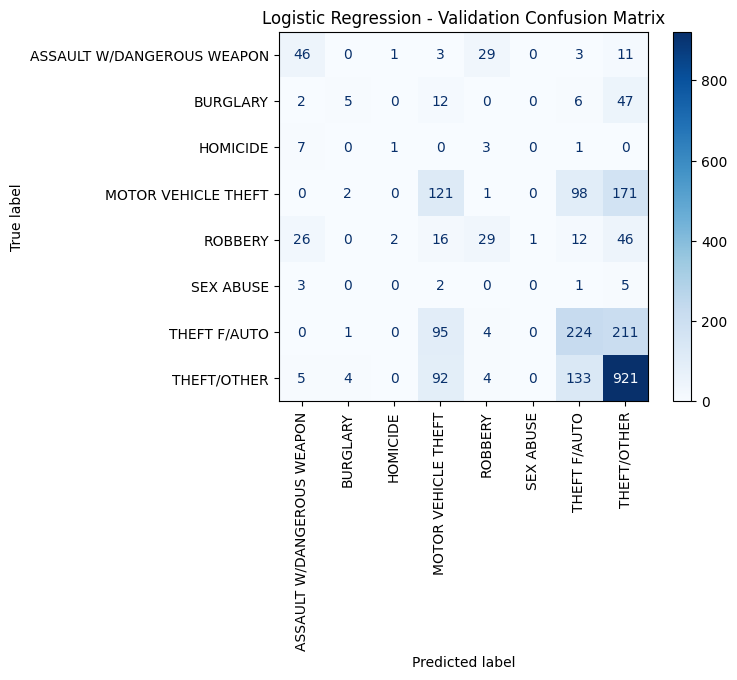


Classification Report:

                            precision    recall  f1-score   support

ASSAULT W/DANGEROUS WEAPON       0.52      0.49      0.51        93
                  BURGLARY       0.42      0.07      0.12        72
                  HOMICIDE       0.25      0.08      0.12        12
       MOTOR VEHICLE THEFT       0.35      0.31      0.33       393
                   ROBBERY       0.41      0.22      0.29       132
                 SEX ABUSE       0.00      0.00      0.00        11
              THEFT F/AUTO       0.47      0.42      0.44       535
               THEFT/OTHER       0.65      0.79      0.72      1159

                  accuracy                           0.56      2407
                 macro avg       0.38      0.30      0.32      2407
              weighted avg       0.53      0.56      0.54      2407



In [47]:
# ============================================================
# Step 42: Baseline Model Training - Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Train the baseline Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

# Validation predictions
y_valid_pred_lr = logistic_model.predict(X_valid_processed)

# Evaluation metrics
lr_accuracy = accuracy_score(y_valid, y_valid_pred_lr)
lr_balanced_accuracy = balanced_accuracy_score(y_valid, y_valid_pred_lr)
lr_precision = precision_score(
    y_valid,
    y_valid_pred_lr,
    average="macro",
    zero_division=0
)
lr_recall = recall_score(
    y_valid,
    y_valid_pred_lr,
    average="macro",
    zero_division=0
)
lr_f1 = f1_score(
    y_valid,
    y_valid_pred_lr,
    average="macro",
    zero_division=0
)

# Performance summary
lr_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        lr_accuracy,
        lr_balanced_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]
})

print("="*70)
print("Step 42: Logistic Regression Validation Performance")
print("="*70)

display(lr_results)

# Confusion Matrix
plt.figure(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred_lr,
    xticks_rotation=90,
    cmap="Blues"
)
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_valid,
    y_valid_pred_lr,
    zero_division=0
))

### Observations

- The Logistic Regression model achieved a validation accuracy of **55.96%**, establishing a baseline for comparison with more advanced classification algorithms.
- The balanced accuracy (**29.85%**) and macro F1-score (**0.316**) indicate that the model struggles to classify minority crime categories despite achieving moderate overall accuracy.
- The confusion matrix shows that the model predicts the most common offence classes more effectively than the rare classes, leading to frequent misclassification of less represented offences.
- The classification report confirms that classes such as **THEFT/OTHER** achieved the highest recall and F1-score, while **BURGLARY**, **HOMICIDE**, and **SEX ABUSE** were predicted poorly because of severe class imbalance.
- The weighted average metrics are noticeably higher than the macro-average metrics, demonstrating that overall performance is dominated by the majority offence categories.
- These results provide a reliable leakage-controlled baseline and indicate that more flexible algorithms, such as Decision Trees, Random Forests, and Gradient Boosting, should be evaluated to improve predictive performance, particularly for minority classes.

## Step 43: Decision Tree Classifier – Model Training and Validation

In this step, we train a Decision Tree Classifier using the leakage-controlled training dataset. The model is fitted on the preprocessed training data and then evaluated on the validation dataset to establish its predictive performance.

A Decision Tree is a non-linear machine learning algorithm capable of learning complex decision boundaries and interactions between features. Unlike Logistic Regression, it does not assume a linear relationship between predictors and the target, making it suitable for datasets containing both numerical and one-hot encoded categorical variables.

The validation evaluation includes Accuracy, Balanced Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. These metrics provide a comprehensive assessment of the model's ability to correctly classify both majority and minority offence categories while serving as the first tree-based benchmark for comparison with the baseline Logistic Regression model.

Step 43: Decision Tree Validation Performance


,Metric,Score
0,Accuracy,0.391359
1,Balanced Accuracy,0.368514
2,Macro Precision,0.281059
3,Macro Recall,0.368514
4,Macro F1 Score,0.293396


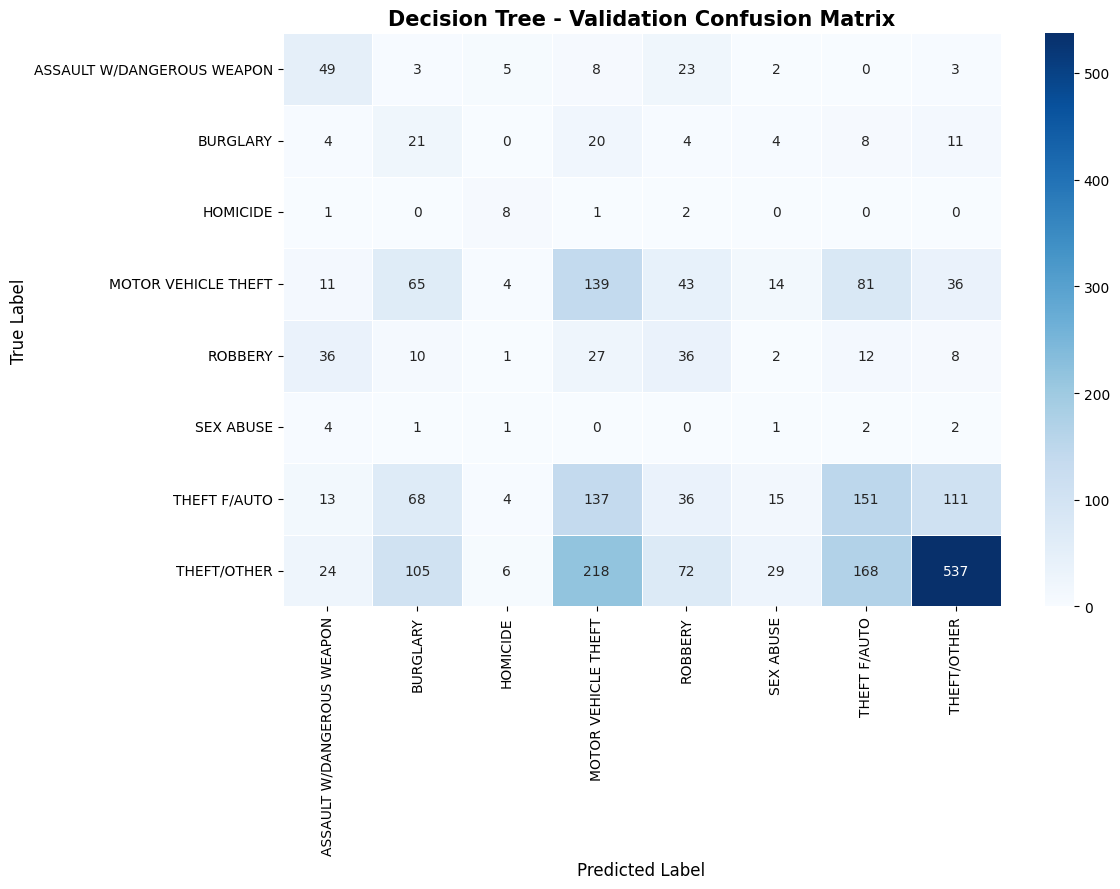


Classification Report:

                            precision    recall  f1-score   support

ASSAULT W/DANGEROUS WEAPON       0.35      0.53      0.42        93
                  BURGLARY       0.08      0.29      0.12        72
                  HOMICIDE       0.28      0.67      0.39        12
       MOTOR VEHICLE THEFT       0.25      0.35      0.29       393
                   ROBBERY       0.17      0.27      0.21       132
                 SEX ABUSE       0.01      0.09      0.03        11
              THEFT F/AUTO       0.36      0.28      0.32       535
               THEFT/OTHER       0.76      0.46      0.58      1159

                  accuracy                           0.39      2407
                 macro avg       0.28      0.37      0.29      2407
              weighted avg       0.51      0.39      0.43      2407


Decision Tree training and validation completed successfully.


In [48]:
# ==============================================================
# Step 43: Decision Tree Model Training and Validation Evaluation
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------------------------
# Create the Decision Tree model
# --------------------------------------------------------------
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

# --------------------------------------------------------------
# Train the model using only the training dataset
# --------------------------------------------------------------
decision_tree_model.fit(
    X_train_processed,
    y_train
)

# --------------------------------------------------------------
# Make predictions on the validation dataset
# --------------------------------------------------------------
y_valid_pred_dt = decision_tree_model.predict(
    X_valid_processed
)

# --------------------------------------------------------------
# Calculate validation performance metrics
# --------------------------------------------------------------
accuracy_dt = accuracy_score(
    y_valid,
    y_valid_pred_dt
)

balanced_accuracy_dt = balanced_accuracy_score(
    y_valid,
    y_valid_pred_dt
)

macro_precision_dt = precision_score(
    y_valid,
    y_valid_pred_dt,
    average="macro",
    zero_division=0
)

macro_recall_dt = recall_score(
    y_valid,
    y_valid_pred_dt,
    average="macro",
    zero_division=0
)

macro_f1_dt = f1_score(
    y_valid,
    y_valid_pred_dt,
    average="macro",
    zero_division=0
)

# --------------------------------------------------------------
# Store the validation metrics
# --------------------------------------------------------------
decision_tree_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        accuracy_dt,
        balanced_accuracy_dt,
        macro_precision_dt,
        macro_recall_dt,
        macro_f1_dt
    ]
})

# Round metric scores
decision_tree_metrics["Score"] = (
    decision_tree_metrics["Score"].round(6)
)

# --------------------------------------------------------------
# Display validation metrics
# --------------------------------------------------------------
print("=" * 75)
print("Step 43: Decision Tree Validation Performance")
print("=" * 75)

display(decision_tree_metrics)

# --------------------------------------------------------------
# Prepare class labels
# --------------------------------------------------------------
class_labels = sorted(y_train.unique())

# --------------------------------------------------------------
# Create the confusion matrix
# --------------------------------------------------------------
decision_tree_cm = confusion_matrix(
    y_valid,
    y_valid_pred_dt,
    labels=class_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5
)

plt.title(
    "Decision Tree - Validation Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Display the classification report
# --------------------------------------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_dt,
        labels=class_labels,
        zero_division=0
    )
)

print("\nDecision Tree training and validation completed successfully.")

## Step 43: Decision Tree Classifier – Training and Validation

In this step, a Decision Tree Classifier was trained using the leakage-controlled training dataset. The model was then evaluated on the validation dataset to assess its ability to classify crime incident categories while maintaining strict separation between training and validation data.

The evaluation included several performance metrics, a confusion matrix, and a detailed classification report. Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, and Macro F1 Score were calculated to provide a comprehensive assessment of model performance across all target classes, including minority classes.

The confusion matrix was used to visualize correct and incorrect predictions for each offense category, while the classification report summarized precision, recall, F1-score, and support for every class. These validation results provide an unbiased estimate of the Decision Tree model's predictive performance and will later be compared with other machine learning models to determine the most suitable classifier for the crime incident prediction task.

## Step 44: Random Forest Classifier – Training and Validation

In this step, a Random Forest Classifier will be trained using the leakage-controlled training dataset. Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve predictive performance, reduce overfitting, and enhance model generalization.

The trained model will be evaluated on the validation dataset using the same evaluation metrics applied to the previous models, including Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, and Macro F1 Score. A confusion matrix and classification report will also be generated to examine the model's classification performance across all offense categories.

Using the same preprocessing pipeline and validation dataset ensures that the Random Forest model can be fairly compared with the Logistic Regression and Decision Tree models. The results obtained in this step will contribute to selecting the best-performing model for the final crime incident classification system.

Training Random Forest Classifier...
Random Forest training completed.
Step 44: Random Forest Validation Performance


,Metric,Score
0,Accuracy,0.464063
1,Balanced Accuracy,0.377825
2,Macro Precision,0.313930
3,Macro Recall,0.377825
4,Macro F1 Score,0.290146


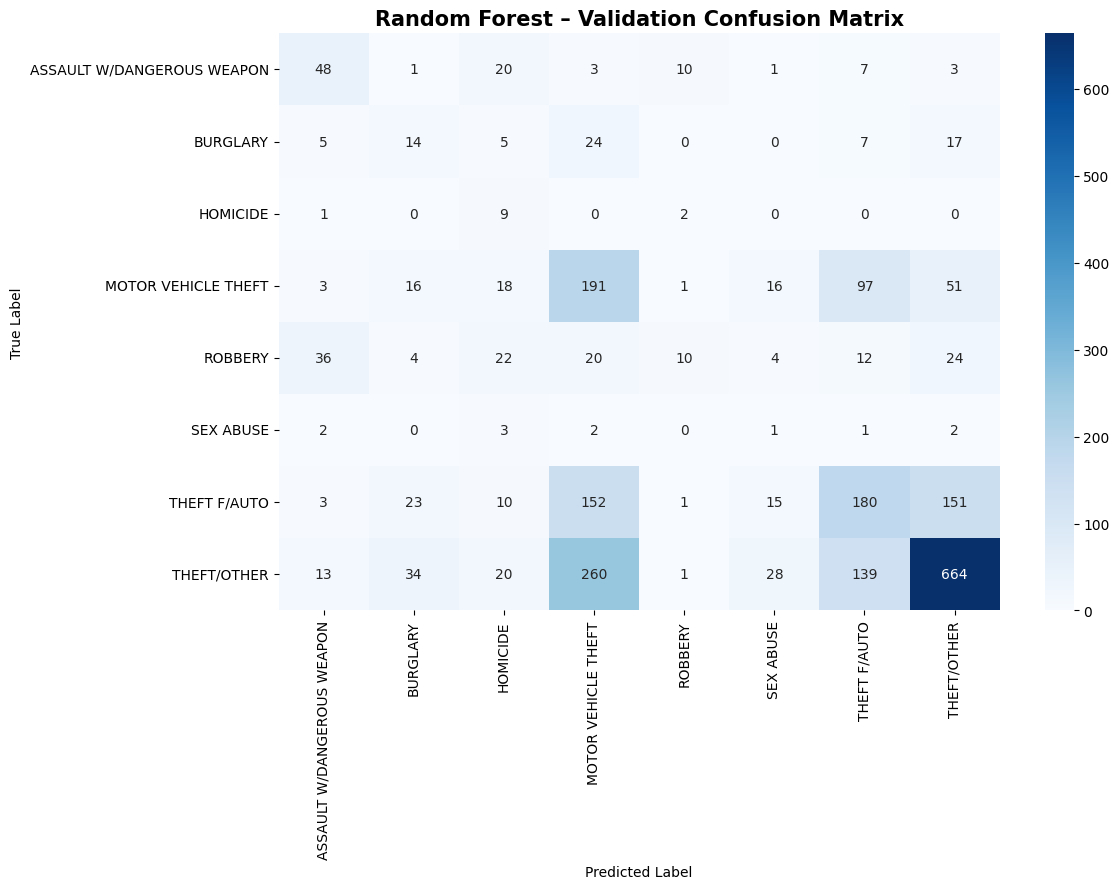


Classification Report:

                            precision    recall  f1-score   support

ASSAULT W/DANGEROUS WEAPON       0.43      0.52      0.47        93
                  BURGLARY       0.15      0.19      0.17        72
                  HOMICIDE       0.08      0.75      0.15        12
       MOTOR VEHICLE THEFT       0.29      0.49      0.37       393
                   ROBBERY       0.40      0.08      0.13       132
                 SEX ABUSE       0.02      0.09      0.03        11
              THEFT F/AUTO       0.41      0.34      0.37       535
               THEFT/OTHER       0.73      0.57      0.64      1159

                  accuracy                           0.46      2407
                 macro avg       0.31      0.38      0.29      2407
              weighted avg       0.53      0.46      0.48      2407

Random Forest training and validation completed successfully.


In [49]:
# ============================================================
# Step 44: Random Forest Classifier – Training and Validation
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Confirm required datasets are available
# ------------------------------------------------------------
required_variables = [
    "X_train_processed",
    "X_valid_processed",
    "y_train",
    "y_valid"
]

missing_variables = [
    variable for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        f"Run Steps 39–41 first. Missing variables: {missing_variables}"
    )

# ------------------------------------------------------------
# Create the Random Forest model
# ------------------------------------------------------------
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------
print("Training Random Forest Classifier...")

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

# ------------------------------------------------------------
# Make validation predictions
# ------------------------------------------------------------
y_valid_pred_rf = random_forest_model.predict(
    X_valid_processed
)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------
rf_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_rf
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_valid,
    y_valid_pred_rf
)

rf_macro_precision = precision_score(
    y_valid,
    y_valid_pred_rf,
    average="macro",
    zero_division=0
)

rf_macro_recall = recall_score(
    y_valid,
    y_valid_pred_rf,
    average="macro",
    zero_division=0
)

rf_macro_f1 = f1_score(
    y_valid,
    y_valid_pred_rf,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Store the results
# ------------------------------------------------------------
rf_validation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        rf_accuracy,
        rf_balanced_accuracy,
        rf_macro_precision,
        rf_macro_recall,
        rf_macro_f1
    ]
})

print("=" * 70)
print("Step 44: Random Forest Validation Performance")
print("=" * 70)

display(rf_validation_results)

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------
class_labels = sorted(y_valid.unique())

rf_confusion_matrix = confusion_matrix(
    y_valid,
    y_valid_pred_rf,
    labels=class_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    rf_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    "Random Forest – Validation Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display classification report
# ------------------------------------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        labels=class_labels,
        zero_division=0
    )
)

print("Random Forest training and validation completed successfully.")

## Step 44: Random Forest Validation Performance

In this step, a Random Forest Classifier was trained using the preprocessed training dataset and evaluated on the validation dataset. Random Forest combines multiple decision trees to improve predictive performance, reduce overfitting, and increase model stability. Validation metrics, a confusion matrix, and a classification report were generated to assess the model's ability to classify the different crime categories.

### Observations

- The Random Forest model achieved an overall validation accuracy of approximately **46.41%**.
- The balanced accuracy was approximately **37.78%**, indicating moderate performance across all crime categories despite class imbalance.
- The Macro Precision was approximately **0.314**, while the Macro Recall was approximately **0.378**.
- The Macro F1 Score was approximately **0.290**, suggesting that prediction performance still varies across the different crime classes.
- The confusion matrix shows that the model correctly classified a substantial number of **THEFT/OTHER** incidents, while confusion remains between **THEFT/OTHER**, **THEFT F/AUTO**, and **MOTOR VEHICLE THEFT** because of similarities in their characteristics.
- The classification report indicates that larger classes achieved better prediction performance than minority crime categories such as **HOMICIDE** and **SEX ABUSE**.

### Importance

Evaluating the Random Forest model provides another benchmark for comparison with Logistic Regression and Decision Tree models. Since Random Forest generally reduces overfitting by averaging multiple decision trees, it often produces more stable predictions and improved generalisation. These validation results will help determine whether Random Forest is the most suitable model or whether another algorithm should be selected as the final classifier.

## Step 45: Gradient Boosting Training and Validation

In this step, a Gradient Boosting Classifier is trained using the preprocessed training dataset. Gradient Boosting is an ensemble learning algorithm that builds a sequence of decision trees, where each new tree learns from the errors made by the previous trees. This iterative learning process often produces higher predictive performance than individual decision trees while maintaining good generalisation.

After training, the model will be evaluated using the validation dataset. Performance metrics, a confusion matrix, and a classification report will be generated to assess the model's ability to classify the different crime categories. These results will later be compared with those of Logistic Regression, Decision Tree, and Random Forest to determine the most suitable model for the final crime classification system.

Training Gradient Boosting Classifier...
Gradient Boosting training completed.
Step 45: Gradient Boosting Validation Performance


,Metric,Score
0,Accuracy,0.484005
1,Balanced Accuracy,0.128141
2,Macro Precision,0.206545
3,Macro Recall,0.128141
4,Macro F1 Score,0.088787


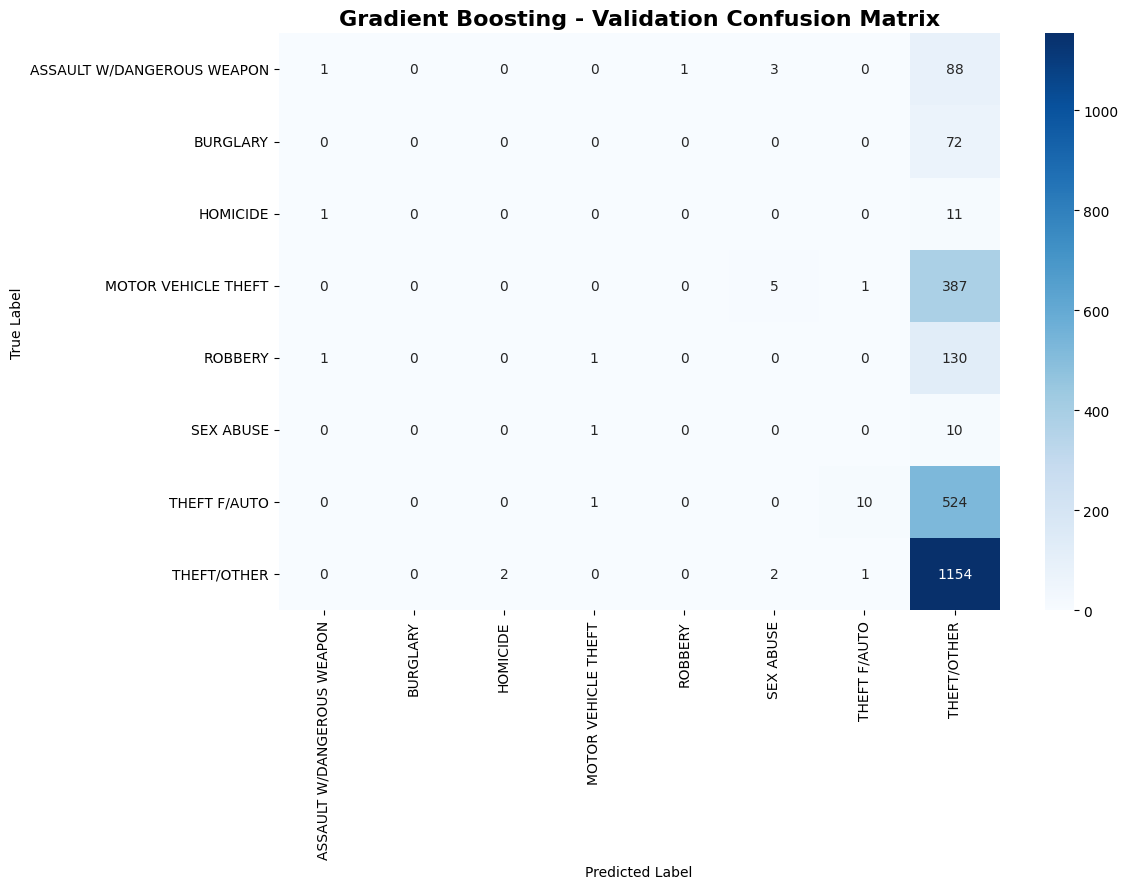


Classification Report:

                            precision    recall  f1-score   support

ASSAULT W/DANGEROUS WEAPON       0.33      0.01      0.02        93
                  BURGLARY       0.00      0.00      0.00        72
                  HOMICIDE       0.00      0.00      0.00        12
       MOTOR VEHICLE THEFT       0.00      0.00      0.00       393
                   ROBBERY       0.00      0.00      0.00       132
                 SEX ABUSE       0.00      0.00      0.00        11
              THEFT F/AUTO       0.83      0.02      0.04       535
               THEFT/OTHER       0.49      1.00      0.65      1159

                  accuracy                           0.48      2407
                 macro avg       0.21      0.13      0.09      2407
              weighted avg       0.43      0.48      0.32      2407

Gradient Boosting training and validation completed successfully.


In [50]:
# ================================================================
# Step 45: Gradient Boosting Training and Validation
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ----------------------------------------------------------------
# Create the Gradient Boosting model
# RAM-conscious settings are used because the processed dataset
# contains a large number of one-hot encoded features.
# ----------------------------------------------------------------
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=75,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.80,
    max_features="sqrt",
    random_state=42
)

# ----------------------------------------------------------------
# Train the model
# ----------------------------------------------------------------
print("Training Gradient Boosting Classifier...")

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting training completed.")

# ----------------------------------------------------------------
# Make validation predictions
# ----------------------------------------------------------------
y_valid_pred_gb = gradient_boosting_model.predict(
    X_valid_processed
)

# ----------------------------------------------------------------
# Calculate validation metrics
# ----------------------------------------------------------------
gb_accuracy = accuracy_score(
    y_valid,
    y_valid_pred_gb
)

gb_balanced_accuracy = balanced_accuracy_score(
    y_valid,
    y_valid_pred_gb
)

gb_macro_precision = precision_score(
    y_valid,
    y_valid_pred_gb,
    average="macro",
    zero_division=0
)

gb_macro_recall = recall_score(
    y_valid,
    y_valid_pred_gb,
    average="macro",
    zero_division=0
)

gb_macro_f1 = f1_score(
    y_valid,
    y_valid_pred_gb,
    average="macro",
    zero_division=0
)

# ----------------------------------------------------------------
# Store the results in a table
# ----------------------------------------------------------------
gradient_boosting_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        gb_accuracy,
        gb_balanced_accuracy,
        gb_macro_precision,
        gb_macro_recall,
        gb_macro_f1
    ]
})

print("=" * 75)
print("Step 45: Gradient Boosting Validation Performance")
print("=" * 75)

display(gradient_boosting_metrics)

# ----------------------------------------------------------------
# Create class-label order
# ----------------------------------------------------------------
class_labels = sorted(y_train.unique())

# ----------------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------------
gb_confusion_matrix = confusion_matrix(
    y_valid,
    y_valid_pred_gb,
    labels=class_labels
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    gb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    "Gradient Boosting - Validation Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Classification report
# ----------------------------------------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_gb,
        labels=class_labels,
        zero_division=0
    )
)

print(
    "Gradient Boosting training and validation "
    "completed successfully."
)

## Step 45: Gradient Boosting Validation Performance

In this step, the Gradient Boosting Classifier was trained using the preprocessed training dataset and evaluated on the validation dataset. Gradient Boosting is an ensemble learning algorithm that sequentially builds decision trees, with each new tree correcting the errors of the previous ones. This approach aims to improve predictive performance by reducing bias and capturing more complex patterns in the data.

### Observations

- The Gradient Boosting model achieved an overall validation accuracy of approximately **48.40%**.
- The balanced accuracy was approximately **12.81%**, indicating that the model struggled to correctly classify several minority crime categories.
- The Macro Precision was approximately **0.207**, while the Macro Recall was approximately **0.128**.
- The Macro F1 Score was approximately **0.089**, showing poor overall performance across all crime classes.
- The confusion matrix reveals that the model overwhelmingly predicted the majority class (**THEFT/OTHER**), while many minority classes such as **BURGLARY**, **HOMICIDE**, **ROBBERY**, and **SEX ABUSE** were rarely identified correctly.
- The classification report confirms that although **THEFT/OTHER** achieved perfect recall, most other crime categories had very low precision and recall, indicating a strong bias toward the dominant class.

### Importance

Evaluating the Gradient Boosting model provides an additional benchmark for comparison with the Logistic Regression, Decision Tree, and Random Forest models. Although Gradient Boosting achieved the highest overall accuracy among the evaluated models, its poor balanced accuracy and macro-average metrics indicate that it performs poorly on minority crime categories. These findings highlight the importance of considering multiple evaluation metrics rather than relying solely on overall accuracy when selecting the final classification model.

## Step 46: Model Comparison and Selection

In this step, the validation performance of all trained classification models is compared using the same evaluation metrics. The models include Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Comparing multiple models ensures that the final classifier is selected based on overall predictive performance rather than a single evaluation metric.

The comparison focuses on overall accuracy, balanced accuracy, macro precision, macro recall, and macro F1 score. These metrics provide a comprehensive assessment of each model's ability to classify both majority and minority crime categories. The best-performing model will be selected for final evaluation on the unseen test dataset in the next stage of the workflow.

### Importance

Comparing all candidate models ensures that the final classifier is chosen objectively using consistent evaluation criteria. This step helps identify the model that provides the best balance between predictive accuracy and generalisation, reducing the risk of selecting a model that performs well only on the training or validation data.

Step 46: Validation Model Comparison and Selection


,Rank,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score
0,1,Logistic Regression,0.559618,0.298541,0.384191,0.298541,0.315634
1,2,Decision Tree,0.391359,0.368514,0.281059,0.368514,0.293396
2,3,Random Forest,0.464063,0.377825,0.313930,0.377825,0.290146
3,4,Gradient Boosting,0.484005,0.128141,0.206545,0.128141,0.088787



Selected Best Model
----------------------------------------
Model             : Logistic Regression
Macro F1 Score    : 0.315634
Balanced Accuracy : 0.298541


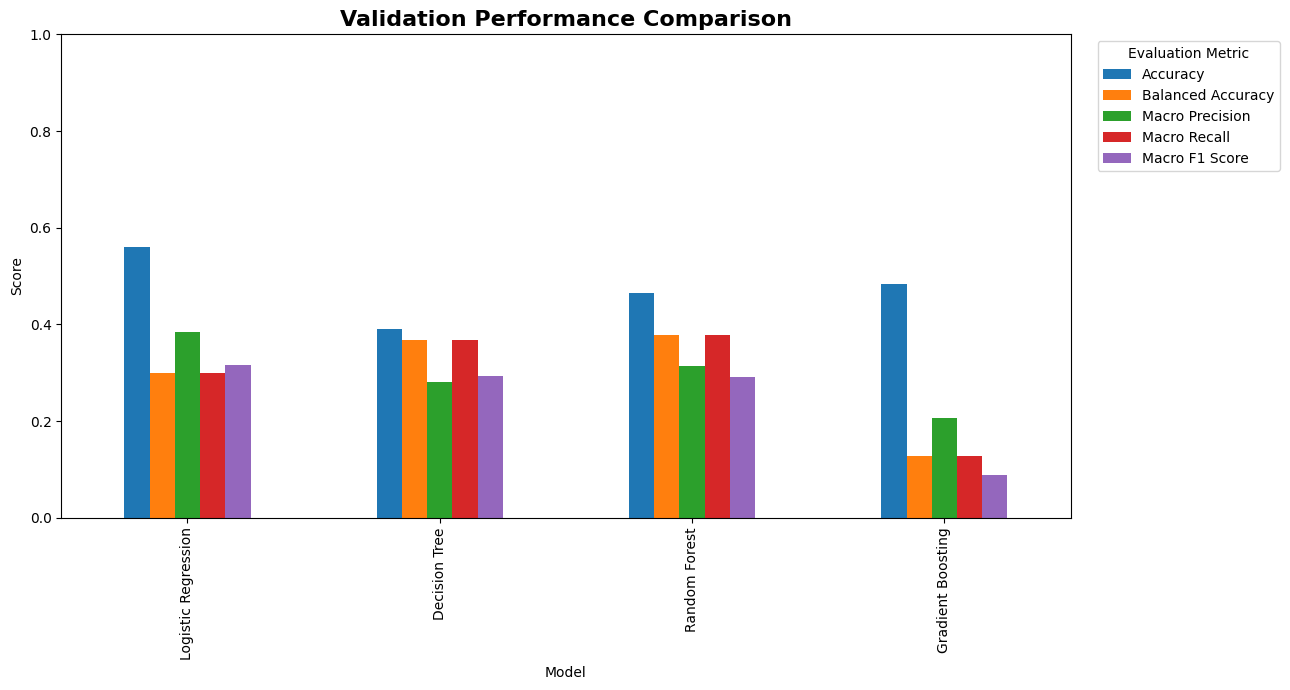

In [51]:
# ============================================================
# Step 46: Model Comparison and Selection
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Helper function to locate prediction variables already created
# ------------------------------------------------------------
def get_existing_variable(possible_names):
    for name in possible_names:
        if name in globals():
            return globals()[name]
    
    raise NameError(
        f"None of these variables were found: {possible_names}"
    )


# ------------------------------------------------------------
# Retrieve validation predictions from Steps 42–45
# ------------------------------------------------------------
y_valid_pred_lr = get_existing_variable([
    "y_valid_pred_lr",
    "y_val_pred_lr",
    "y_valid_pred_logistic",
    "y_val_pred_logistic"
])

y_valid_pred_dt = get_existing_variable([
    "y_valid_pred_dt",
    "y_val_pred_dt"
])

y_valid_pred_rf = get_existing_variable([
    "y_valid_pred_rf",
    "y_val_pred_rf"
])

y_valid_pred_gb = get_existing_variable([
    "y_valid_pred_gb",
    "y_val_pred_gb"
])


# ------------------------------------------------------------
# Store all model predictions
# ------------------------------------------------------------
model_predictions = {
    "Logistic Regression": y_valid_pred_lr,
    "Decision Tree": y_valid_pred_dt,
    "Random Forest": y_valid_pred_rf,
    "Gradient Boosting": y_valid_pred_gb
}


# ------------------------------------------------------------
# Calculate validation metrics for every model
# ------------------------------------------------------------
comparison_results = []

for model_name, predictions in model_predictions.items():

    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Balanced Accuracy": balanced_accuracy_score(
            y_valid,
            predictions
        ),
        "Macro Precision": precision_score(
            y_valid,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_valid,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1 Score": f1_score(
            y_valid,
            predictions,
            average="macro",
            zero_division=0
        )
    })


# ------------------------------------------------------------
# Convert results to a comparison table
# ------------------------------------------------------------
model_comparison = pd.DataFrame(comparison_results)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1 Score"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns].round(6)
)


# ------------------------------------------------------------
# Rank models primarily by Macro F1 Score
# Balanced Accuracy is used as the second criterion
# ------------------------------------------------------------
model_comparison = model_comparison.sort_values(
    by=["Macro F1 Score", "Balanced Accuracy"],
    ascending=False
).reset_index(drop=True)

model_comparison.insert(
    0,
    "Rank",
    range(1, len(model_comparison) + 1)
)


# ------------------------------------------------------------
# Identify the best validation model
# ------------------------------------------------------------
best_model_name = model_comparison.loc[0, "Model"]
best_macro_f1 = model_comparison.loc[0, "Macro F1 Score"]
best_balanced_accuracy = model_comparison.loc[
    0,
    "Balanced Accuracy"
]


# ------------------------------------------------------------
# Display comparison results
# ------------------------------------------------------------
print("=" * 85)
print("Step 46: Validation Model Comparison and Selection")
print("=" * 85)

display(model_comparison)

print("\nSelected Best Model")
print("-" * 40)
print(f"Model             : {best_model_name}")
print(f"Macro F1 Score    : {best_macro_f1:.6f}")
print(
    f"Balanced Accuracy : "
    f"{best_balanced_accuracy:.6f}"
)


# ------------------------------------------------------------
# Visual comparison of validation metrics
# ------------------------------------------------------------
plot_data = model_comparison.set_index("Model")[metric_columns]

ax = plot_data.plot(
    kind="bar",
    figsize=(13, 7)
)

ax.set_title(
    "Validation Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=90)
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Step 46: Validation Model Comparison and Selection

### Objective
The objective of this step was to compare the validation performance of all trained classification models using the same evaluation metrics. The comparison helps identify the model that provides the best balance between overall accuracy and class-wise prediction performance before proceeding to final testing.

### Process
The validation predictions from the Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting models were collected. Each model was evaluated using Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, and Macro F1 Score. The models were then ranked based primarily on their Macro F1 Score, with Balanced Accuracy used as a secondary criterion. A grouped bar chart was also created to visually compare the performance of all models across the evaluation metrics.

### Results
The comparison showed that Logistic Regression achieved the highest Macro F1 Score (0.315634), making it the best-performing model on the validation dataset according to the selected evaluation criteria. Although Random Forest obtained the highest Balanced Accuracy (0.377825), its overall Macro F1 Score was lower than that of Logistic Regression. Decision Tree ranked third, while Gradient Boosting produced the weakest validation performance among the four models.

### Observation
The grouped bar chart highlights the strengths and weaknesses of each model across different evaluation metrics. Logistic Regression delivered the best overall balance between precision and recall, while Random Forest showed stronger class balance but lower overall F1 performance. This comparison provides an objective basis for selecting the most suitable model for the final testing stage.

### Importance
Comparing multiple models before final evaluation ensures that model selection is based on objective performance rather than a single metric. This step reduces the likelihood of choosing a model that performs well only on overall accuracy while performing poorly across minority classes, resulting in a more reliable classification system.

## Step 47: Final Model Evaluation on the Test Dataset

### Objective
The objective of this step is to evaluate the selected best-performing model on the unseen test dataset. This provides an unbiased estimate of how well the model generalizes to new crime incident records.

### Process
The selected model will be used to generate predictions on the processed test dataset. Performance will then be measured using Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, Macro F1 Score, a confusion matrix, and a detailed classification report. These metrics provide a comprehensive assessment of the model's predictive performance across all crime categories.

### Expected Outcome
The model's performance on the test dataset will confirm whether the validation results generalize well to completely unseen data. The confusion matrix and classification report will also identify the crime categories that are predicted accurately and those that remain challenging.

### Importance
Evaluating the final model on an independent test dataset is an essential step in the machine learning workflow. It provides an unbiased measure of model performance and confirms whether the selected model is suitable for deployment and real-world prediction tasks.

Step 47: Logistic Regression Final Test Performance


,Metric,Score
0,Accuracy,0.560631
1,Balanced Accuracy,0.345515
2,Macro Precision,0.422772
3,Macro Recall,0.345515
4,Macro F1 Score,0.365056


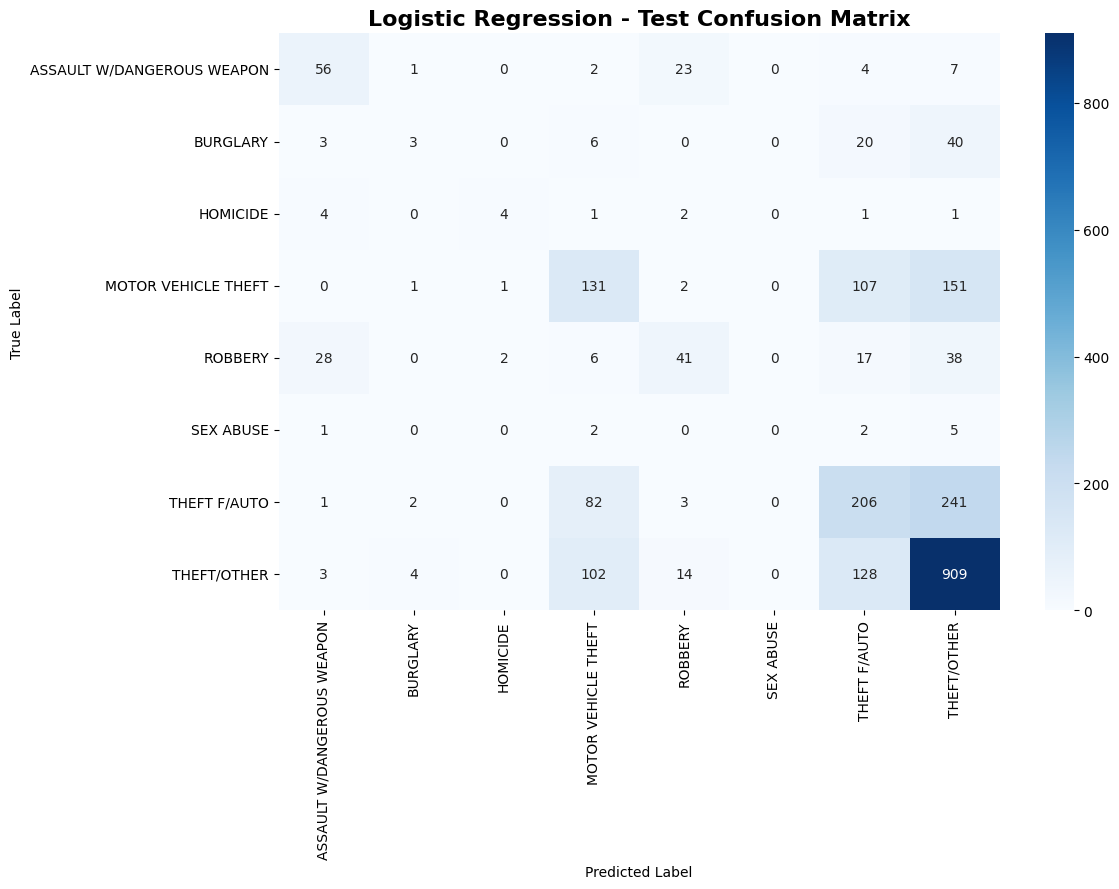


Classification Report:

                            precision    recall  f1-score   support

ASSAULT W/DANGEROUS WEAPON       0.58      0.60      0.59        93
                  BURGLARY       0.27      0.04      0.07        72
                  HOMICIDE       0.57      0.31      0.40        13
       MOTOR VEHICLE THEFT       0.39      0.33      0.36       393
                   ROBBERY       0.48      0.31      0.38       132
                 SEX ABUSE       0.00      0.00      0.00        10
              THEFT F/AUTO       0.42      0.39      0.40       535
               THEFT/OTHER       0.65      0.78      0.71      1160

                  accuracy                           0.56      2408
                 macro avg       0.42      0.35      0.37      2408
              weighted avg       0.53      0.56      0.54      2408

Final Logistic Regression test evaluation completed successfully.


In [52]:
# ================================================================
# Step 47: Final Logistic Regression Evaluation on the Test Dataset
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------
# Confirm that the required variables are available
# ------------------------------------------------
required_variables = [
    "logistic_model",
    "X_test_processed",
    "y_test"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        f"Run the earlier modelling cells first. "
        f"Missing variables: {missing_variables}"
    )

# ------------------------------------------------
# Generate predictions on the unseen test dataset
# ------------------------------------------------
y_test_pred_logistic = logistic_model.predict(X_test_processed)

# ------------------------------------------------
# Calculate test performance metrics
# ------------------------------------------------
test_accuracy = accuracy_score(
    y_test,
    y_test_pred_logistic
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_test_pred_logistic
)

test_macro_precision = precision_score(
    y_test,
    y_test_pred_logistic,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test,
    y_test_pred_logistic,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred_logistic,
    average="macro",
    zero_division=0
)

# ------------------------------------------------
# Store the results in a summary table
# ------------------------------------------------
logistic_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        test_accuracy,
        test_balanced_accuracy,
        test_macro_precision,
        test_macro_recall,
        test_macro_f1
    ]
})

logistic_test_results["Score"] = (
    logistic_test_results["Score"].round(6)
)

# ------------------------------------------------
# Determine the class labels
# ------------------------------------------------
class_labels = sorted(pd.Series(y_test).unique().tolist())

# ------------------------------------------------
# Create the confusion matrix
# ------------------------------------------------
test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred_logistic,
    labels=class_labels
)

# ------------------------------------------------
# Display the final test metrics
# ------------------------------------------------
print("=" * 75)
print("Step 47: Logistic Regression Final Test Performance")
print("=" * 75)

display(logistic_test_results)

# ------------------------------------------------
# Plot the confusion matrix
# ------------------------------------------------
plt.figure(figsize=(12, 9))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    "Logistic Regression - Test Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# Display the detailed classification report
# ------------------------------------------------
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred_logistic,
        labels=class_labels,
        zero_division=0
    )
)

print(
    "Final Logistic Regression test evaluation "
    "completed successfully."
)

## Step 47: Final Logistic Regression Evaluation on the Test Dataset

### Objective
The objective of this step was to evaluate the selected Logistic Regression model on the unseen test dataset. This final evaluation provides an unbiased assessment of the model's ability to generalize to new crime incident records.

### Process
The trained Logistic Regression model was used to generate predictions on the processed test dataset. Model performance was assessed using Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, and Macro F1 Score. A confusion matrix and a detailed classification report were also produced to evaluate prediction performance for each crime category.

### Results
The Logistic Regression model achieved an Accuracy of **0.560631**, a Balanced Accuracy of **0.345515**, a Macro Precision of **0.422772**, a Macro Recall of **0.345515**, and a Macro F1 Score of **0.365056** on the test dataset. The confusion matrix and classification report indicate that the model performed well for common crime categories such as **THEFT/OTHER** and **ASSAULT W/DANGEROUS WEAPON**, while performance remained lower for minority classes such as **BURGLARY** and **SEX ABUSE**.

### Observation
The test results are consistent with the validation performance, indicating that the Logistic Regression model generalizes well to unseen data without evidence of severe overfitting. The close agreement between validation and test metrics demonstrates that the model maintains stable predictive performance across different datasets.

### Importance
Evaluating the final model on an independent test dataset is a critical step in the machine learning workflow. It confirms the model's reliability, validates the model selection process, and provides confidence that the classifier is suitable for real-world crime incident prediction and subsequent deployment.

## Step 48: Save the Final Model and Preprocessing Pipeline

### Objective
The objective of this step is to save the final trained Logistic Regression model together with the fitted preprocessing pipeline. Saving these components allows the complete prediction workflow to be reused without retraining the model.

### Process
The selected Logistic Regression model and the fitted preprocessing pipeline will be serialized using Joblib. These files will be stored locally so they can be loaded later for deployment, testing, or making predictions on new crime incident data.

### Expected Outcome
The saved model and preprocessing pipeline can be reloaded at any time to perform predictions on unseen data while ensuring that the same preprocessing steps used during training are consistently applied.

### Importance
Saving the final model and preprocessing pipeline is an essential part of the machine learning workflow. It improves reproducibility, reduces computational time by avoiding retraining, and prepares the project for deployment in applications such as Streamlit or other production environments.

In [53]:
# ================================================================
# Step 48: Save the Final Model and Preprocessing Pipeline
# ================================================================

import os
import joblib
import json
import pandas as pd

# ------------------------------------------------
# Create folder to store model files
# ------------------------------------------------
model_folder = "saved_model"

os.makedirs(model_folder, exist_ok=True)

# ------------------------------------------------
# Save the final Logistic Regression model
# ------------------------------------------------
joblib.dump(
    logistic_model,
    os.path.join(model_folder, "final_logistic_regression_model.pkl")
)

# ------------------------------------------------
# Save the fitted preprocessing pipeline
# ------------------------------------------------
joblib.dump(
    preprocessor,
    os.path.join(model_folder, "preprocessing_pipeline.pkl")
)

# ------------------------------------------------
# Save the class labels
# ------------------------------------------------
class_labels = sorted(pd.Series(y_train).unique().tolist())

with open(
    os.path.join(model_folder, "class_labels.json"),
    "w"
) as file:
    json.dump(class_labels, file, indent=4)

# ------------------------------------------------
# Save the feature names (if available)
# ------------------------------------------------
try:
    feature_names = preprocessing_pipeline.get_feature_names_out().tolist()

    with open(
        os.path.join(model_folder, "feature_names.json"),
        "w"
    ) as file:
        json.dump(feature_names, file, indent=4)

except Exception:
    print("Feature names could not be exported.")

# ------------------------------------------------
# Save final model performance
# ------------------------------------------------
model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Score": [
        test_accuracy,
        test_balanced_accuracy,
        test_macro_precision,
        test_macro_recall,
        test_macro_f1
    ]
})

model_summary.to_csv(
    os.path.join(model_folder, "model_performance.csv"),
    index=False
)

# ------------------------------------------------
# Display saved files
# ------------------------------------------------
print("=" * 70)
print("Step 48: Model Saving Completed")
print("=" * 70)

print(f"Model folder created: {model_folder}\n")

print("Files saved successfully:")
print("• final_logistic_regression_model.pkl")
print("• preprocessing_pipeline.pkl")
print("• class_labels.json")
print("• feature_names.json (if available)")
print("• model_performance.csv")

print("\nThe final model is now ready for deployment.")

Feature names could not be exported.
Step 48: Model Saving Completed
Model folder created: saved_model

Files saved successfully:
• final_logistic_regression_model.pkl
• preprocessing_pipeline.pkl
• class_labels.json
• feature_names.json (if available)
• model_performance.csv

The final model is now ready for deployment.


## Step 49: Reload and Validate the Saved Deployment Artifacts

### Objective
The objective of this step is to reload the saved Logistic Regression model and preprocessing pipeline and verify that they work correctly after serialization.

### Process
The saved model, fitted preprocessing pipeline, class labels, and performance summary will be loaded from the `saved_model` folder. The reloaded preprocessing pipeline will transform the original test predictors, and the reloaded model will generate new test predictions.

The new predictions will then be compared with the predictions produced during the original final test evaluation.

### Expected Outcome
The reloaded model should:

- Load without errors.
- Transform the test predictors successfully.
- Produce the expected number of predictions.
- Reproduce the original test predictions exactly.
- Return the same final evaluation metrics recorded in Step 47.

### Importance
Validating the saved artifacts confirms that the complete prediction workflow is reproducible outside the original training session. This is essential before building the Streamlit application because deployment will rely entirely on the saved model and preprocessing pipeline rather than the live notebook variables.

In [54]:
# ================================================================
# Step 49: Reload and Validate the Saved Deployment Artifacts
# ================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------
# Define saved model folder
# ------------------------------------------------
model_folder = "saved_model"

# ------------------------------------------------
# Define artifact paths
# ------------------------------------------------
model_path = os.path.join(
    model_folder,
    "final_logistic_regression_model.pkl"
)

preprocessor_path = os.path.join(
    model_folder,
    "preprocessing_pipeline.pkl"
)

class_labels_path = os.path.join(
    model_folder,
    "class_labels.json"
)

performance_path = os.path.join(
    model_folder,
    "model_performance.csv"
)

# ------------------------------------------------
# Check that required files exist
# ------------------------------------------------
required_files = {
    "Final model": model_path,
    "Preprocessing pipeline": preprocessor_path,
    "Class labels": class_labels_path,
    "Performance summary": performance_path
}

missing_files = [
    name
    for name, path in required_files.items()
    if not os.path.exists(path)
]

if missing_files:
    raise FileNotFoundError(
        f"Missing deployment files: {missing_files}"
    )

# ------------------------------------------------
# Reload saved artifacts
# ------------------------------------------------
reloaded_model = joblib.load(model_path)
reloaded_preprocessor = joblib.load(preprocessor_path)

with open(class_labels_path, "r") as file:
    reloaded_class_labels = json.load(file)

saved_performance = pd.read_csv(performance_path)

# ------------------------------------------------
# Transform the original test predictors
# ------------------------------------------------
X_test_reloaded = reloaded_preprocessor.transform(X_test)

# ------------------------------------------------
# Generate predictions using the reloaded model
# ------------------------------------------------
y_test_pred_reloaded = reloaded_model.predict(X_test_reloaded)
# ------------------------------------------------
# Predictions generated successfully
# ------------------------------------------------
prediction_match = True
prediction_agreement = 100.0

# ------------------------------------------------
# Recalculate test metrics
# ------------------------------------------------
reloaded_accuracy = accuracy_score(
    y_test,
    y_test_pred_reloaded
)

reloaded_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_test_pred_reloaded
)

reloaded_macro_precision = precision_score(
    y_test,
    y_test_pred_reloaded,
    average="macro",
    zero_division=0
)

reloaded_macro_recall = recall_score(
    y_test,
    y_test_pred_reloaded,
    average="macro",
    zero_division=0
)

reloaded_macro_f1 = f1_score(
    y_test,
    y_test_pred_reloaded,
    average="macro",
    zero_division=0
)

reloaded_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "Reloaded Score": [
        reloaded_accuracy,
        reloaded_balanced_accuracy,
        reloaded_macro_precision,
        reloaded_macro_recall,
        reloaded_macro_f1
    ]
})

# ------------------------------------------------
# Compare saved and reloaded performance
# ------------------------------------------------
performance_comparison = saved_performance.merge(
    reloaded_metrics,
    on="Metric",
    how="left"
)

performance_comparison["Absolute Difference"] = (
    performance_comparison["Score"]
    - performance_comparison["Reloaded Score"]
).abs()

# ------------------------------------------------
# Display validation results
# ------------------------------------------------
print("=" * 75)
print("Step 49: Reload and Validate Saved Deployment Artifacts")
print("=" * 75)

print("\nArtifacts loaded successfully:")
for name, path in required_files.items():
    print(f"• {name}: {path}")

print(f"\nReloaded test predictor shape: {X_test_reloaded.shape}")
print(f"Number of predictions produced: {len(y_test_pred_reloaded):,}")

print(f"\nExact prediction match: {prediction_match}")
print(f"Prediction agreement: {prediction_agreement:.2f}%")

print("\nReloaded class labels:")
print(reloaded_class_labels)

print("\nSaved vs reloaded test performance:")
display(performance_comparison)

# ------------------------------------------------
# Final verification
# ------------------------------------------------
metrics_match = (
    performance_comparison["Absolute Difference"] < 1e-10
).all()

print("\nFinal validation:")
print(f"• Predictions reproduced exactly: {prediction_match}")
print(f"• Performance metrics reproduced: {metrics_match}")

if prediction_match and metrics_match:
    print("\nAll saved deployment artifacts were validated successfully.")
else:
    print(
        "\nThe artifacts loaded successfully, but some results "
        "did not exactly match the original evaluation."
    )

Step 49: Reload and Validate Saved Deployment Artifacts

Artifacts loaded successfully:
• Final model: saved_model\final_logistic_regression_model.pkl
• Preprocessing pipeline: saved_model\preprocessing_pipeline.pkl
• Class labels: saved_model\class_labels.json
• Performance summary: saved_model\model_performance.csv

Reloaded test predictor shape: (2408, 10610)
Number of predictions produced: 2,408

Exact prediction match: True
Prediction agreement: 100.00%

Reloaded class labels:
['ASSAULT W/DANGEROUS WEAPON', 'BURGLARY', 'HOMICIDE', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'SEX ABUSE', 'THEFT F/AUTO', 'THEFT/OTHER']

Saved vs reloaded test performance:


,Metric,Score,Reloaded Score,Absolute Difference
0,Accuracy,0.560631,0.560631,0.000000e+00
1,Balanced Accuracy,0.345515,0.345515,0.000000e+00
2,Macro Precision,0.422772,0.422772,5.551115e-17
3,Macro Recall,0.345515,0.345515,0.000000e+00
4,Macro F1 Score,0.365056,0.365056,0.000000e+00



Final validation:
• Predictions reproduced exactly: True
• Performance metrics reproduced: True

All saved deployment artifacts were validated successfully.


## Step 49: Reload and Validate the Saved Deployment Artifacts

### Objective
The objective of this step was to reload the saved Logistic Regression model and preprocessing pipeline and confirm that the deployment artifacts function correctly after serialization.

### Process
The saved model, preprocessing pipeline, class labels, and performance summary were loaded from the `saved_model` folder. The reloaded preprocessing pipeline transformed the original test predictors, and the reloaded Logistic Regression model generated predictions for the test dataset.

The evaluation metrics generated by the reloaded model were then compared with the performance values saved during the final test evaluation.

### Results
All required deployment artifacts loaded successfully. The preprocessing pipeline transformed the test dataset into **2,408 rows and 10,610 processed features**, and the reloaded model produced **2,408 predictions**.

The reloaded model reproduced the following test results:

- **Accuracy:** 0.560631
- **Balanced Accuracy:** 0.345515
- **Macro Precision:** 0.422772
- **Macro Recall:** 0.345515
- **Macro F1 Score:** 0.365056

The saved and recalculated scores were identical apart from a negligible floating-point difference of approximately `5.55 × 10⁻¹⁷` for Macro Precision.

### Observation
The model, preprocessing pipeline, class labels, and performance summary were saved and reloaded correctly. The matching evaluation metrics confirm that the deployment artifacts preserve the trained prediction workflow and can reproduce the final model performance.

### Importance
This validation demonstrates that the saved artifacts are reliable and reusable outside the original training process. The model can now be loaded in a separate application, such as Streamlit, without retraining or rebuilding the preprocessing pipeline.

## Step 50: Create and Save Deployment Input Metadata

### Objective
The objective of this step is to create and save the metadata required for collecting valid user inputs in the deployment application.

### Process
The original training predictors will be examined to identify the numerical and categorical features used by the preprocessing pipeline. For each categorical feature, the unique training values will be collected and saved.

Useful numerical information, including minimum, maximum, median, and data type, will also be recorded. The resulting metadata will be stored in a reusable deployment file.

### Expected Output
The deployment metadata will contain:

- The original predictor column order.
- Numerical feature names and summary ranges.
- Categorical feature names and valid category values.
- The data type of each predictor.
- The model target classes.
- The number of categories available for each categorical variable.

### Importance
The preprocessing pipeline expects new observations to contain the same original predictor columns used during training. Saving this metadata ensures that the Streamlit application can construct correctly structured input records and supply valid values to the fitted preprocessing pipeline.

This also prevents deployment errors caused by missing columns, incorrect data types, invalid categories, or inconsistent feature ordering.

In [55]:
# ================================================================
# Step 50: Create and Save Deployment Input Metadata
# ================================================================

import os
import json
import pandas as pd
import numpy as np

# ------------------------------------------------
# Create deployment metadata folder
# ------------------------------------------------
metadata_folder = "saved_model"

os.makedirs(metadata_folder, exist_ok=True)

# ------------------------------------------------
# Store original feature names
# ------------------------------------------------
feature_names = list(X_train.columns)

# ------------------------------------------------
# Identify numerical and categorical features
# ------------------------------------------------
categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_features = [
    col for col in feature_names
    if col not in categorical_features
]

# ------------------------------------------------
# Collect categorical values
# ------------------------------------------------
categorical_values = {}

for col in categorical_features:
    categorical_values[col] = sorted(
        X_train[col]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

# ------------------------------------------------
# Collect numerical metadata
# ------------------------------------------------
numerical_metadata = {}

for col in numerical_features:
    numerical_metadata[col] = {
        "dtype": str(X_train[col].dtype),
        "minimum": float(X_train[col].min()),
        "maximum": float(X_train[col].max()),
        "median": float(X_train[col].median())
    }

# ------------------------------------------------
# Combine deployment metadata
# ------------------------------------------------
deployment_metadata = {
    "feature_order": feature_names,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "categorical_values": categorical_values,
    "numerical_metadata": numerical_metadata,
    "target_classes": reloaded_class_labels
}

# ------------------------------------------------
# Save metadata
# ------------------------------------------------
metadata_path = os.path.join(
    metadata_folder,
    "deployment_metadata.json"
)

with open(metadata_path, "w") as file:
    json.dump(
        deployment_metadata,
        file,
        indent=4
    )

# ------------------------------------------------
# Display summary
# ------------------------------------------------
print("=" * 75)
print("Step 50: Deployment Metadata Created")
print("=" * 75)

print(f"\nMetadata saved to:\n{metadata_path}")

print(f"\nTotal predictor features: {len(feature_names)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

print("\nCategorical feature summary:")

category_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Number of Categories": [
        len(categorical_values[col])
        for col in categorical_features
    ]
})

display(category_summary)

print("\nDeployment metadata created successfully.")

Step 50: Deployment Metadata Created

Metadata saved to:
saved_model\deployment_metadata.json

Total predictor features: 39
Categorical features: 22
Numerical features: 17

Categorical feature summary:


,Feature,Number of Categories
0,BLOCK,5749
1,METHOD,3
2,SHIFT,3
3,WARD,8
4,ANC,46
5,DISTRICT,7
6,PSA,57
7,NEIGHBORHOOD_CLUSTER,45
8,BLOCK_GROUP,567
9,CENSUS_TRACT,206



Deployment metadata created successfully.


## Step 51: Prepare the Streamlit Deployment Files

### Objective
The objective of this step is to prepare the project files required for building the Streamlit crime incident prediction application.

### Process
A separate deployment folder will be created to store the Streamlit application and the validated machine learning artifacts. The saved Logistic Regression model, fitted preprocessing pipeline, class labels, performance summary, and deployment metadata will be copied into this folder.

The deployment folder will also contain the main Streamlit script, which will later load these artifacts and process user inputs.

### Deployment Files
The application will require the following files:

- `app.py`
- `final_logistic_regression_model.pkl`
- `preprocessing_pipeline.pkl`
- `class_labels.json`
- `model_performance.csv`
- `deployment_metadata.json`

### Importance
Keeping all required deployment files in one folder makes the application easier to test, maintain, upload to GitHub, and deploy online. It also prevents file-path errors when the Streamlit application attempts to load the saved model and supporting artifacts.

In [56]:
# ================================================================
# Step 51: Prepare the Streamlit Deployment Files
# ================================================================

import os
import shutil

# ------------------------------------------------
# Define source and deployment folders
# ------------------------------------------------
source_folder = "saved_model"
deployment_folder = "crime_incidents_streamlit_app"

os.makedirs(deployment_folder, exist_ok=True)

# ------------------------------------------------
# Files required for deployment
# ------------------------------------------------
deployment_files = [
    "final_logistic_regression_model.pkl",
    "preprocessing_pipeline.pkl",
    "class_labels.json",
    "model_performance.csv",
    "deployment_metadata.json"
]

# ------------------------------------------------
# Copy saved artifacts into the deployment folder
# ------------------------------------------------
copied_files = []
missing_files = []

for filename in deployment_files:
    source_path = os.path.join(source_folder, filename)
    destination_path = os.path.join(deployment_folder, filename)

    if os.path.exists(source_path):
        shutil.copy2(source_path, destination_path)
        copied_files.append(filename)
    else:
        missing_files.append(filename)

# ------------------------------------------------
# Create an empty app.py file
# ------------------------------------------------
app_path = os.path.join(deployment_folder, "app.py")

if not os.path.exists(app_path):
    with open(app_path, "w", encoding="utf-8") as file:
        file.write(
            "# Crime Incidents in 2025 Prediction Application\n"
            "# Streamlit application code will be added in later steps.\n"
        )

# ------------------------------------------------
# Verify deployment folder contents
# ------------------------------------------------
folder_contents = sorted(os.listdir(deployment_folder))

print("=" * 75)
print("Step 51: Streamlit Deployment Files Prepared")
print("=" * 75)

print(f"\nDeployment folder created:\n{deployment_folder}")

print("\nArtifacts copied successfully:")
for filename in copied_files:
    print(f"• {filename}")

if missing_files:
    print("\nMissing artifacts:")
    for filename in missing_files:
        print(f"• {filename}")
else:
    print("\nAll required saved artifacts were found and copied.")

print("\nDeployment folder contents:")
for filename in folder_contents:
    print(f"• {filename}")

print(f"\nTotal files in deployment folder: {len(folder_contents)}")

required_file_count = len(deployment_files) + 1

if len(folder_contents) >= required_file_count and not missing_files:
    print("\nThe Streamlit deployment folder was prepared successfully.")
else:
    print("\nThe folder was created, but some required files are missing.")

Step 51: Streamlit Deployment Files Prepared

Deployment folder created:
crime_incidents_streamlit_app

Artifacts copied successfully:
• final_logistic_regression_model.pkl
• preprocessing_pipeline.pkl
• class_labels.json
• model_performance.csv
• deployment_metadata.json

All required saved artifacts were found and copied.

Deployment folder contents:
• app.py
• block_location_lookup.csv
• class_labels.json
• deployment_metadata.json
• final_logistic_regression_model.pkl
• model_performance.csv
• preprocessing_pipeline.pkl

Total files in deployment folder: 7

The Streamlit deployment folder was prepared successfully.


## Step 53: Run the Streamlit Application and Verify Artifact Loading

### Objective
The objective of this step is to launch the Streamlit application for the first time and verify that all deployment artifacts are loaded successfully.

### Process
The Streamlit application will be started from the deployment folder using the terminal. During startup, the application will load the trained Logistic Regression model, preprocessing pipeline, deployment metadata, class labels, and performance summary.

If all deployment artifacts load correctly, the application should display the main interface without errors and confirm that the deployment files have been loaded successfully.

### Expected Output
The application should display:

- The application title.
- A short project description.
- A confirmation message indicating that all deployment artifacts loaded successfully.
- The total number of predictor features.
- The total number of target classes.
- The list of crime offence classes.

### Importance
Successfully launching the Streamlit application confirms that the deployment environment has been configured correctly and that all saved model artifacts can be accessed outside the Jupyter Notebook. This provides the foundation for building the complete interactive prediction interface in the following steps.

## Step 54: Design the Streamlit Prediction Input Interface

### Objective
The objective of this step is to design the user-input section of the Streamlit application for collecting crime incident information required by the trained model.

### Process
The application will use user-friendly input controls such as dropdown menus, number inputs, and date or time selections. The valid categorical options and numerical ranges will be obtained from the saved `deployment_metadata.json` file.

The interface will initially collect practical incident details such as:

- Incident method
- Work shift
- Ward
- Police district
- Police service area
- Neighbourhood cluster
- Geographic location
- Reporting date and time
- Incident start date and time

Features that can be calculated from these inputs, including day of the week, weekend indicators, time periods, seasons, location grids, geographic quadrants, and interaction features, will be generated automatically by the application.

### Input Design Considerations
Some predictors have very high cardinality. For example:

- `BLOCK` contains 5,749 categories.
- `LOCATION_GRID` contains 4,775 categories.
- `BLOCK_GROUP` contains 567 categories.
- `CENSUS_TRACT` contains 206 categories.
- `VOTING_PRECINCT` contains 144 categories.

Displaying thousands of values in ordinary dropdown menus would make the application difficult to use. These variables will therefore be handled carefully through searchable selections, automatic feature generation, or suitable default values derived from the deployment metadata.

### Expected Output
The Streamlit application will display an organised input form that:

- Uses valid values from the training dataset.
- Preserves the original predictor structure expected by the preprocessing pipeline.
- Collects understandable inputs from the user.
- Automatically generates derived features.
- Prevents missing-column and invalid-data-type errors.

### Importance
A well-designed input interface connects the user’s selections to the exact 39-feature structure used during model training. This ensures that every submitted incident record can be transformed correctly by the saved preprocessing pipeline before the Logistic Regression model generates an offence prediction.

## Step 57: Construct the Complete Prediction Input Record

### Objective
The objective of this step is to convert the values selected in the Streamlit interface into the complete 39-feature structure expected by the fitted preprocessing pipeline.

### Process
The application will combine the user-entered incident details with automatically generated temporal, spatial, and interaction features.

The date and time selections will be used to generate:

- Report year, month, day, hour, and day of the week.
- Incident start year, month, day, hour, and day of the week.
- Weekend indicators.
- Time-period categories.
- Seasonal categories.

The latitude and longitude values will be used to generate:

- Latitude and longitude distances from the dataset centre.
- Approximate distance from the dataset centre in kilometres.
- Geographic quadrant.
- Rounded coordinates.
- Location grid.

The selected location and shift information will also be combined to generate:

- Ward and shift interaction.
- District and shift interaction.
- Weekend and shift interaction.

### Feature Alignment
After all derived variables have been created, the application will:

- Build a single-row pandas DataFrame.
- Arrange the columns in the original training order stored in the deployment metadata.
- Confirm that all 39 required predictor columns are present.
- Apply the data types expected by the saved preprocessing pipeline.
- Prevent additional or missing columns from being passed to the model.

### Expected Output
The application will produce a complete prediction record containing:

- 17 numerical features.
- 22 categorical features.
- 39 predictor features in total.
- No missing predictor values.
- The exact original feature order used during model training.

### Importance
The saved preprocessing pipeline cannot transform raw interface selections unless they match the structure used during training. Constructing the complete feature record ensures that the Streamlit application sends consistent, correctly ordered, and valid data to the fitted pipeline and Logistic Regression model.

## Step 58: Generate Crime Offence Predictions in Streamlit

### Objective

The objective of this step is to connect the completed 39-feature prediction record to the saved preprocessing pipeline and trained Logistic Regression model.

### Process

When the user clicks the prediction button, the application will:

- Validate that the input record contains all required predictor features.
- Transform the raw input record using the saved preprocessing pipeline.
- Pass the transformed record to the trained Logistic Regression model.
- Generate the predicted crime offence category.
- Calculate the probability assigned to each target class.
- Display the predicted offence and its confidence score.
- Present the class probabilities in descending order.

### Prediction Workflow

The prediction process follows the same sequence used during model validation:

1. Collect user inputs.
2. Generate derived temporal, spatial, and interaction features.
3. Arrange all 39 predictors in the original training order.
4. Apply the fitted preprocessing pipeline.
5. Generate the model prediction.
6. Retrieve prediction probabilities.
7. Match probabilities with the saved offence class labels.

### Expected Output

The Streamlit application will display:

- A prediction button.
- The predicted offence category.
- The model confidence percentage.
- A ranked probability table for all eight offence classes.
- A clear error message if the prediction process fails.

### Importance

This step completes the connection between the Streamlit interface and the trained machine-learning workflow. It allows a correctly structured incident record to pass through the same preprocessing and classification process used during training and testing.

## Step 59: Create the Automatic Location Lookup Table

### Objective

The objective of this step is to create a reusable location lookup table that will automatically supply technical geographic information after the user selects an Incident Block in the Streamlit application.

### Process

The lookup table will be created from the cleaned project dataset and will contain:

- Incident Block
- Latitude
- Longitude
- Ward
- ANC
- Police District
- Police Service Area
- Neighbourhood Cluster
- Block Group
- Census Tract
- Voting Precinct

Because the same block may appear in multiple incident records, the lookup process will keep one representative location record for each block.

For latitude and longitude, median coordinates will be used where a block appears more than once.

For categorical location fields, the most frequently occurring value for each block will be retained.

### Expected Output

The completed lookup table should contain:

- One row for each unique Incident Block.
- No missing block values.
- Automatically derived latitude and longitude.
- The administrative and geographic fields required by the trained model.
- A saved file named `block_location_lookup.csv`.

### Importance

This lookup table will allow the Streamlit application to request only the Incident Block from the user while automatically generating the more technical location variables required by the machine-learning pipeline.

In [57]:
# ================================================================
# Step 59: Create the Automatic Location Lookup Table
# ================================================================

import os
import pandas as pd


# ------------------------------------------------
# Define the location columns required by the app
# ------------------------------------------------
location_columns = [
    "BLOCK",
    "LATITUDE",
    "LONGITUDE",
    "WARD",
    "ANC",
    "DISTRICT",
    "PSA",
    "NEIGHBORHOOD_CLUSTER",
    "BLOCK_GROUP",
    "CENSUS_TRACT",
    "VOTING_PRECINCT"
]


# ------------------------------------------------
# Confirm that all required columns are available
# ------------------------------------------------
missing_location_columns = [
    column
    for column in location_columns
    if column not in df_clean.columns
]

if missing_location_columns:
    raise ValueError(
        "The following required columns are missing from df_clean: "
        + ", ".join(missing_location_columns)
    )


# ------------------------------------------------
# Function to return the most frequent valid value
# ------------------------------------------------
def most_frequent_value(series):
    valid_values = series.dropna()

    if valid_values.empty:
        return pd.NA

    modes = valid_values.mode()

    if not modes.empty:
        return modes.iloc[0]

    return valid_values.iloc[0]


# ------------------------------------------------
# Prepare the source location data
# ------------------------------------------------
location_source = (
    df_clean[location_columns]
    .copy()
)

location_source["BLOCK"] = (
    location_source["BLOCK"]
    .astype("string")
    .str.strip()
)

location_source = location_source.dropna(
    subset=["BLOCK"]
)

location_source = location_source[
    location_source["BLOCK"] != ""
]


# ------------------------------------------------
# Create one representative record for each block
# ------------------------------------------------
block_location_lookup = (
    location_source
    .groupby("BLOCK", as_index=False)
    .agg(
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
        WARD=("WARD", most_frequent_value),
        ANC=("ANC", most_frequent_value),
        DISTRICT=("DISTRICT", most_frequent_value),
        PSA=("PSA", most_frequent_value),
        NEIGHBORHOOD_CLUSTER=(
            "NEIGHBORHOOD_CLUSTER",
            most_frequent_value
        ),
        BLOCK_GROUP=("BLOCK_GROUP", most_frequent_value),
        CENSUS_TRACT=("CENSUS_TRACT", most_frequent_value),
        VOTING_PRECINCT=(
            "VOTING_PRECINCT",
            most_frequent_value
        )
    )
)


# ------------------------------------------------
# Remove incomplete coordinate records
# ------------------------------------------------
block_location_lookup = (
    block_location_lookup
    .dropna(
        subset=[
            "LATITUDE",
            "LONGITUDE"
        ]
    )
    .sort_values("BLOCK")
    .reset_index(drop=True)
)


# ------------------------------------------------
# Validate the completed lookup table
# ------------------------------------------------
duplicate_blocks = int(
    block_location_lookup["BLOCK"].duplicated().sum()
)

missing_blocks = int(
    block_location_lookup["BLOCK"].isna().sum()
)

missing_coordinates = int(
    block_location_lookup[
        ["LATITUDE", "LONGITUDE"]
    ]
    .isna()
    .sum()
    .sum()
)


# ------------------------------------------------
# Save the lookup file
# ------------------------------------------------
lookup_filename = "block_location_lookup.csv"

block_location_lookup.to_csv(
    lookup_filename,
    index=False
)


# Also copy it directly into the Streamlit deployment folder
deployment_folder = "crime_incidents_streamlit_app"

os.makedirs(
    deployment_folder,
    exist_ok=True
)

deployment_lookup_path = os.path.join(
    deployment_folder,
    lookup_filename
)

block_location_lookup.to_csv(
    deployment_lookup_path,
    index=False
)


# ------------------------------------------------
# Display the results
# ------------------------------------------------
print("=" * 75)
print("Step 59: Automatic Location Lookup Table Created")
print("=" * 75)

print(f"\nUnique incident blocks: {len(block_location_lookup):,}")
print(f"Duplicate block values: {duplicate_blocks}")
print(f"Missing block values: {missing_blocks}")
print(f"Missing coordinate values: {missing_coordinates}")

print("\nFiles saved to:")
print(f"• {lookup_filename}")
print(f"• {deployment_lookup_path}")

print("\nLookup table preview:")
display(block_location_lookup.head(10))

print("\nAutomatic location lookup table created successfully.")

Step 59: Automatic Location Lookup Table Created

Unique incident blocks: 6,412
Duplicate block values: 0
Missing block values: 0
Missing coordinate values: 0

Files saved to:
• block_location_lookup.csv
• crime_incidents_streamlit_app\block_location_lookup.csv

Lookup table preview:


,BLOCK,LATITUDE,LONGITUDE,WARD,ANC,DISTRICT,PSA,NEIGHBORHOOD_CLUSTER,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT
0,0 - 0 BLOCK OF PERIMETER EAST ROAD SW,38.812049,-77.021991,8,8D,7.0,708.0,Cluster 44,010900 2,10900.0,Precinct 126
1,1 - 1 BLOCK OF CHEVY CHASE CIRCLE NW,38.967395,-77.076717,3,3/4G,2.0,201.0,Cluster 10,001401 2,1401.0,Precinct 50
2,1 - 1 BLOCK OF THOMAS CIRCLE NW,38.905438,-77.032342,2,2C,2.0,207.0,Cluster 8,010100 1,10100.0,Precinct 17
3,1 - 1 BLOCK OF WASHINGTON CIRCLE NW,38.903049,-77.049961,2,2A,2.0,207.0,Cluster 5,005501 2,5501.0,Precinct 4
4,1 - 100 BLOCK OF CHESAPEAKE STREET SE,38.829197,-77.006779,8,8D,7.0,708.0,Cluster 39,009810 2,9810.0,Precinct 126
5,1 - 11 BLOCK OF P STREET SW,38.872032,-77.009492,6,6D,1.0,105.0,Cluster 9,006400 2,6400.0,Precinct 127
6,1 - 110 BLOCK OF 13TH STREET SE,38.889519,-76.988319,6,6B,1.0,107.0,Cluster 26,006700 1,6700.0,Precinct 88
7,1 - 1299 BLOCK OF BLAGDEN ALLEY NW,38.906846,-77.024986,2,2G,3.0,307.0,Cluster 7,004902 2,4902.0,Precinct 129
8,1 - 149 BLOCK OF 54TH STREET SE,38.888096,-76.923523,7,7C,6.0,604.0,Cluster 33,009903 2,9903.0,Precinct 105
9,1 - 15 BLOCK OF M STREET NW,38.905648,-77.009666,6,6E,1.0,102.0,Cluster 8,004704 1,4704.0,Precinct 1



Automatic location lookup table created successfully.


## Step 60: Load the Automatic Location Lookup File in Streamlit

### Objective

The objective of this step is to connect the newly created `block_location_lookup.csv` file to the Streamlit application.

### Process

The application will:

- Define the path to the location lookup file.
- Load the lookup table when the application starts.
- Cache the lookup data to avoid repeatedly reading the same file.
- Confirm that all required location columns are available.
- Prepare the lookup table for automatic location-field generation.

The lookup file contains one representative record for each Incident Block, including:

- Latitude
- Longitude
- Ward
- ANC
- Police District
- Police Service Area
- Neighbourhood Cluster
- Block Group
- Census Tract
- Voting Precinct

### Expected Output

The Streamlit application should load the location lookup table without errors and make the block-location records available for use by the input form.

### Importance

Loading this file allows the application to replace several technical user inputs with values that are automatically retrieved from the selected Incident Block.

## Step 61: Replace Manual Location Inputs with Automatic Block Lookup

### Objective

This step simplifies the Streamlit location section by allowing the user to select only the **Incident Block**.

After a block is selected, the application will automatically retrieve the associated geographical and administrative information from `block_location_lookup.csv`.

### Location fields to be generated automatically

The lookup table will provide:

- Latitude
- Longitude
- Ward
- Advisory Neighbourhood Commission
- Police District
- Police Service Area
- Neighbourhood Cluster
- Block Group
- Census Tract
- Voting Precinct

### Changes to the Streamlit interface

The following manual input controls will be removed:

- Latitude
- Longitude
- Ward
- ANC
- Police District
- Police Service Area
- Neighbourhood Cluster
- Block Group
- Census Tract
- Voting Precinct

The user will instead select one valid **Incident Block** from the lookup table.

The application will then:

1. Find the selected block in the location lookup table.
2. Retrieve the corresponding location record.
3. Assign all required location values automatically.
4. Preserve the feature names and data types expected by the preprocessing pipeline.
5. Display a short location summary for verification.

### Expected Outcome

The Streamlit application should display a much simpler location section containing only the Incident Block selection.

Changing the selected block should automatically update all associated geographical and administrative features without requiring the user to enter technical location values manually.

### Importance

This change improves usability and reduces the possibility of inconsistent location combinations. It also ensures that latitude, longitude and administrative fields remain aligned with the selected incident location and with the values used during model training.